# Arotake

- This notebook demonstrates how to use Arotake for evaluating High Resolution Rapid Refresh (HRRR) forecast data against Local Climatological Data (LCD) v2 observations.
- The forecast/observed variable is the 2 m temperature at 15:00:00 local standard time, with an 18 h forecast lead time.
- Analysis regions are the US states of Maine and Montana.
- **The analysis period is set to the first week of 2024, which greatly reduces download time. The plots in this notebook, however, show the analysis for the year 2024. To re-create the plots as shown, set the end date of the analysis period to 2024-12-31.**

## Workflow

1. Specify settings and working directories
2. Specify HRRR forecast parameters (analysis period, forecast initialization time, forecast valid time, ...)
3. Download and process HRRR forecast data (using the [hrrr-data](https://github.com/jankazil/hrrr-data) package)
4. Specify LCD v2 observation parameters (analysis period, analysis regions)
5. Download and process LCD v2 data (using the [lcd-v2-data](https://github.com/jankazil/lcd-v2-data) package)
6. Evaluate the HRRR forecast against the LCD v2 observations. This creates and saves time series as netCDF files, and creates plots, for each analysis region, of the model bias, rmse, correlation with observations, etc.
7. Create a plot with the map of the LCD v2 observation locations.
8. Create time series and probability density functions plots of the model bias, rmse, correlation with observations, etc., for all analysis regions concurrently.

## Requirements

- Jupyter kernel with the [Arotake](https://github.com/jankazil/Arotake), [hrrr-data](https://github.com/jankazil/hrrr-data) and [lcd-v2-data](https://github.com/jankazil/lcd-v2-data) packages installed.
- Internet connection

In [ ]:
%load_ext autoreload
%autoreload 2

In [1]:
from arotake import observations,plotting
from arotake.analyze_hrrr_vs_observations import run_analysis

from hrrr_data import hrrr_fetch_surface_forecasts
from lcd_data import build_lcd_dataset

from datetime import datetime, timedelta, timezone
from IPython.display import Image, display
import numpy as np
from pathlib import Path
import xarray as xr
from zoneinfo import ZoneInfo

## Settings

Set verbose to True to produce detailed progress reporting (this will allow following progress of individual steps, but produce lengthy text output).

In [2]:
verbose = False

Set number of parallel download processes to speed things up

In [3]:
n_jobs = 32

### Directories

Directory to which HRRR forecast data files will be downloaded:

In [4]:
model_data_dir = Path('HRRR') / Path('data')

Directory to which LCD observation data files will be downloaded:

In [5]:
obs_data_dir = Path('LCD') / Path('data')

Directory where results will be saved (netCDF data files, PNG plots):

In [6]:
out_dir = Path('results')

## HRRR forecasts

In [7]:
model_name = 'HRRR'
model_region = 'conus'

### Analysis period

For testing it is recommended to set the analysis period to the first week of January 2024 (`end_month = 1`, `end_day = 7`) in the following to reduce execution time, as downloading and processing an entire year can be time-consuming. Download and processing of data will not be repeated for files that have been downloaded and processed previously by this notebook.

In [8]:
start_year = 2024
end_year = 2024

start_moth = 1
end_moth = 1

start_day = 1
end_day = 7

The forecast lead time is set together with the forecast initialization time to give a forecast valid time of 15:00:00 (3pm) local standard time in both Maine and Montana.

In [9]:
model_forecast_lead_hour = 18

### Maine

Region designator

In [10]:
maine_abb = 'ME'

Forecast initialization time (in hours UTC). With a forecast lead time of 18 h, a forecast initialization time of 2 h gives a forecast valid time of 15:00:00 (3 pm) local standard time in Maine (US Eastern Standard Time Zone is UTC−05:00).

In [11]:
me_model_forecast_init_hour = 2

Forecast initialization date/time for the start and end of the analysis period:

In [12]:
me_model_init_start_date = datetime(year=start_year, month=start_moth, day=start_day, hour=me_model_forecast_init_hour, tzinfo=timezone.utc)
me_model_init_end_date = datetime(year=end_year, month=end_moth, day=end_day, hour=me_model_forecast_init_hour, tzinfo=timezone.utc)

Forecast valid date/time for the start and end of the analysis period:

In [13]:
me_model_valid_start_date = me_model_init_start_date + timedelta(hours=model_forecast_lead_hour)
me_model_valid_end_date = me_model_init_end_date + timedelta(hours=model_forecast_lead_hour)

### Montana

Region designator

In [14]:
montana_abb = 'MT'

Forecast initialization time (in hours UTC). With a forecast lead time of 18 h, a forecast initialization time of 4 h gives a forecast valid time of 15:00:00 (3 pm) local standard time in Montana (US Mountan Standard Time Zone is UTC−07:00).

In [15]:
mt_model_forecast_init_hour = 4

Forecast initialization date/time for the start and end of the analysis period:

In [16]:
mt_model_init_start_date = datetime(year=start_year, month=start_moth, day=start_day, hour=mt_model_forecast_init_hour, tzinfo=timezone.utc)
mt_model_init_end_date = datetime(year=end_year, month=end_moth, day=end_day, hour=mt_model_forecast_init_hour, tzinfo=timezone.utc)

Forecast valid date/time for the start and end of the analysis period:

In [17]:
mt_model_valid_start_date = mt_model_init_start_date + timedelta(hours=model_forecast_lead_hour)
mt_model_valid_end_date = mt_model_init_end_date + timedelta(hours=model_forecast_lead_hour)

### Forecast valid times in Maine's and Montana's local standard time

Determine the forecast valid time for the analysis period for Maine (Eastern Standard Time zone  = UTC−05:00)

In [18]:
est = timezone(timedelta(hours=-5))
me_model_valid_start_date_est = me_model_valid_start_date.astimezone(est)
me_model_valid_end_date_est = me_model_valid_end_date.astimezone(est)

print('Forecast valid start/end date/time (local standard time) for Maine')
print(me_model_valid_start_date_est)
print(me_model_valid_end_date_est)

Forecast valid start/end date/time (local standard time) for Maine
2024-01-01 15:00:00-05:00
2024-12-31 15:00:00-05:00


Determine the forecast valid time for the analysis period for Montana (Mountain Standard Time zone = UTC−07:00)

In [19]:
mst = timezone(timedelta(hours=-7))
mt_model_valid_start_date_mst = mt_model_valid_start_date.astimezone(mst)
mt_model_valid_end_date_mst = mt_model_valid_end_date.astimezone(mst)

print('Forecast valid start/end date/time (local standard time) for Montana')
print(mt_model_valid_start_date_mst)
print(mt_model_valid_end_date_mst)

Forecast valid start/end date/time (local standard time) for Montana
2024-01-01 15:00:00-07:00
2024-12-31 15:00:00-07:00


If the forecast valid times are the same, construct stand-alone forecast valid time datetime objects without time zone information

In [20]:
if me_model_valid_start_date_est.replace(tzinfo=None) == mt_model_valid_start_date_mst.replace(tzinfo=None):
    model_valid_start_date_lst = mt_model_valid_start_date_mst.replace(tzinfo=None)
else:
    print(me_model_valid_start_date_est,mt_model_valid_start_date_mst)
    raise ValueError('Expected start time in local standard time of the individual regions to be equal, but it is not:',
                     str(me_model_valid_start_date_est.replace(tzinfo=None)),
                     str(mt_model_valid_start_date_mst.replace(tzinfo=None))
                    )

if me_model_valid_end_date_est.replace(tzinfo=None) == mt_model_valid_end_date_mst.replace(tzinfo=None):
    model_valid_end_date_lst = mt_model_valid_end_date_mst.replace(tzinfo=None)
else:
    print(me_model_valid_end_date_est,mt_model_valid_end_date_mst)
    raise ValueError('Expected start time in local standard time of the individual regions to be equal, but it is not:',
                     str(me_model_valid_end_date_est.replace(tzinfo=None)),
                     str(mt_model_valid_end_date_mst.replace(tzinfo=None))
                    )

## Download and process HRRR forecasts with the forecast valid time for Maine

- Downloaded GRIB files will be converted to netCDF with selected variables (extract = True)
- Download and conversion to netCDF will be skipped for files that have been download previously to reduce execution time (refresh = False).

In [21]:
me_hrrr_forecast_files = hrrr_fetch_surface_forecasts.run_fetch(
    me_model_init_start_date,
    me_model_init_end_date,
    me_model_forecast_init_hour,
    model_forecast_lead_hour,
    model_region,
    model_data_dir,
    n_jobs,
    extract=True,
    refresh=False,
    verbose=verbose)

## Download and process HRRR forecasts with the forecast valid time for Montana

- Downloaded GRIB files will be converted to netCDF with selected variables (extract = True)
- Download and conversion to netCDF will be skipped for files that have been download previously to reduce execution time (refresh = False).

In [22]:
mt_hrrr_forecast_files = hrrr_fetch_surface_forecasts.run_fetch(
    mt_model_init_start_date,
    mt_model_init_end_date,
    mt_model_forecast_init_hour,
    model_forecast_lead_hour,
    model_region,
    model_data_dir,
    n_jobs,
    extract=True,
    refresh=False,
    verbose=verbose)

## Download and process observations for Maine

Download the LCD and build the full-hourly UTC dataset (will be skipped if the LCD data and the dataset have been download/build previosly, refresh = False)

In [23]:
me_obs_file = build_lcd_dataset.run_build(start_year,end_year,maine_abb,obs_data_dir,None,n_jobs,offline=False,refresh=False,verbose=verbose)

## Download and process observations for Montana

Download the LCD and build the full-hourly UTC dataset (will be skipped if the LCD data and the dataset have been download/build previosly, refresh = False)

In [24]:
mt_obs_file = build_lcd_dataset.run_build(start_year,end_year,montana_abb,obs_data_dir,None,n_jobs,offline=False,refresh=False,verbose=verbose)

## Model vs. observations evaluation

HRRR variable to evaluate is the 2 m temperature

In [25]:
model_var = 'TMP_P0_L103_GLC0'

LCD observable to evaluate against is the 2 m temperature

In [26]:
obs_var = 'T'

### Maine

In [27]:
me_model_vs_obs_file, me_model_vs_obs_plots = run_analysis(
    me_model_init_start_date,
    me_model_init_end_date,
    me_model_forecast_init_hour,
    model_forecast_lead_hour,
    model_region,
    model_data_dir,
    model_var,
    me_obs_file,
    obs_var,
    out_dir,
    verbose=verbose,
    generate_plots=True,
)

### Montana

In [28]:
mt_model_vs_obs_file, mt_model_vs_obs_plots = run_analysis(
    mt_model_init_start_date,
    mt_model_init_end_date,
    mt_model_forecast_init_hour,
    model_forecast_lead_hour,
    model_region,
    model_data_dir,
    model_var,
    mt_obs_file,
    obs_var,
    out_dir,
    verbose=verbose,
    generate_plots=True,
)

## Create plots

Lists of files with observations

In [29]:
obs_files = [me_obs_file,mt_obs_file]

List of files with model-vs-observation evaluations

In [30]:
model_vs_obs_files = [me_model_vs_obs_file,mt_model_vs_obs_file]

Plot directory

In [31]:
plot_dir_path = out_dir / Path('Maine-Montana-HRRR-vs-LCD' + str(model_valid_start_date_lst.time()) + 'LST')

Plot title

In [32]:
title = 'Maine and Montana, ' + str(model_valid_start_date_lst.time()) + ' local standard time'

### Map of observation locations

In [33]:
obs_locations_map_plot = plotting.plot_locations_conus(
    [observations.TimeSeries(obs_file) for obs_file in obs_files],
    [model_valid_start_date_lst for obs_file in obs_files],
    [model_valid_end_date_lst for obs_file in obs_files],
    ['LAT' for obs_file in obs_files],
    ['LON' for obs_file in obs_files],
    plot_dir_path,
    colors = ['Red','Blue'],
    markersizes = [4,4],
    legend_font_size = 12,
    verbose = verbose
)

### Time series plots

In [34]:
time_series_plots = plotting.plot_evaluation_time_series(
    model_vs_obs_files,
    plot_dir_path,
    title,
    colors = ['Red','Blue'],
    legend_font_size = 7,
    verbose = verbose)

### Probability density plots

In [35]:
pdf_plots = plotting.plot_evaluation_pdf(
    model_vs_obs_files,
    plot_dir_path,
    title,
    colors = ['Red','Blue'],
    legend_font_size = 7,
    verbose = verbose)

## Display plots

### Map of observation locations

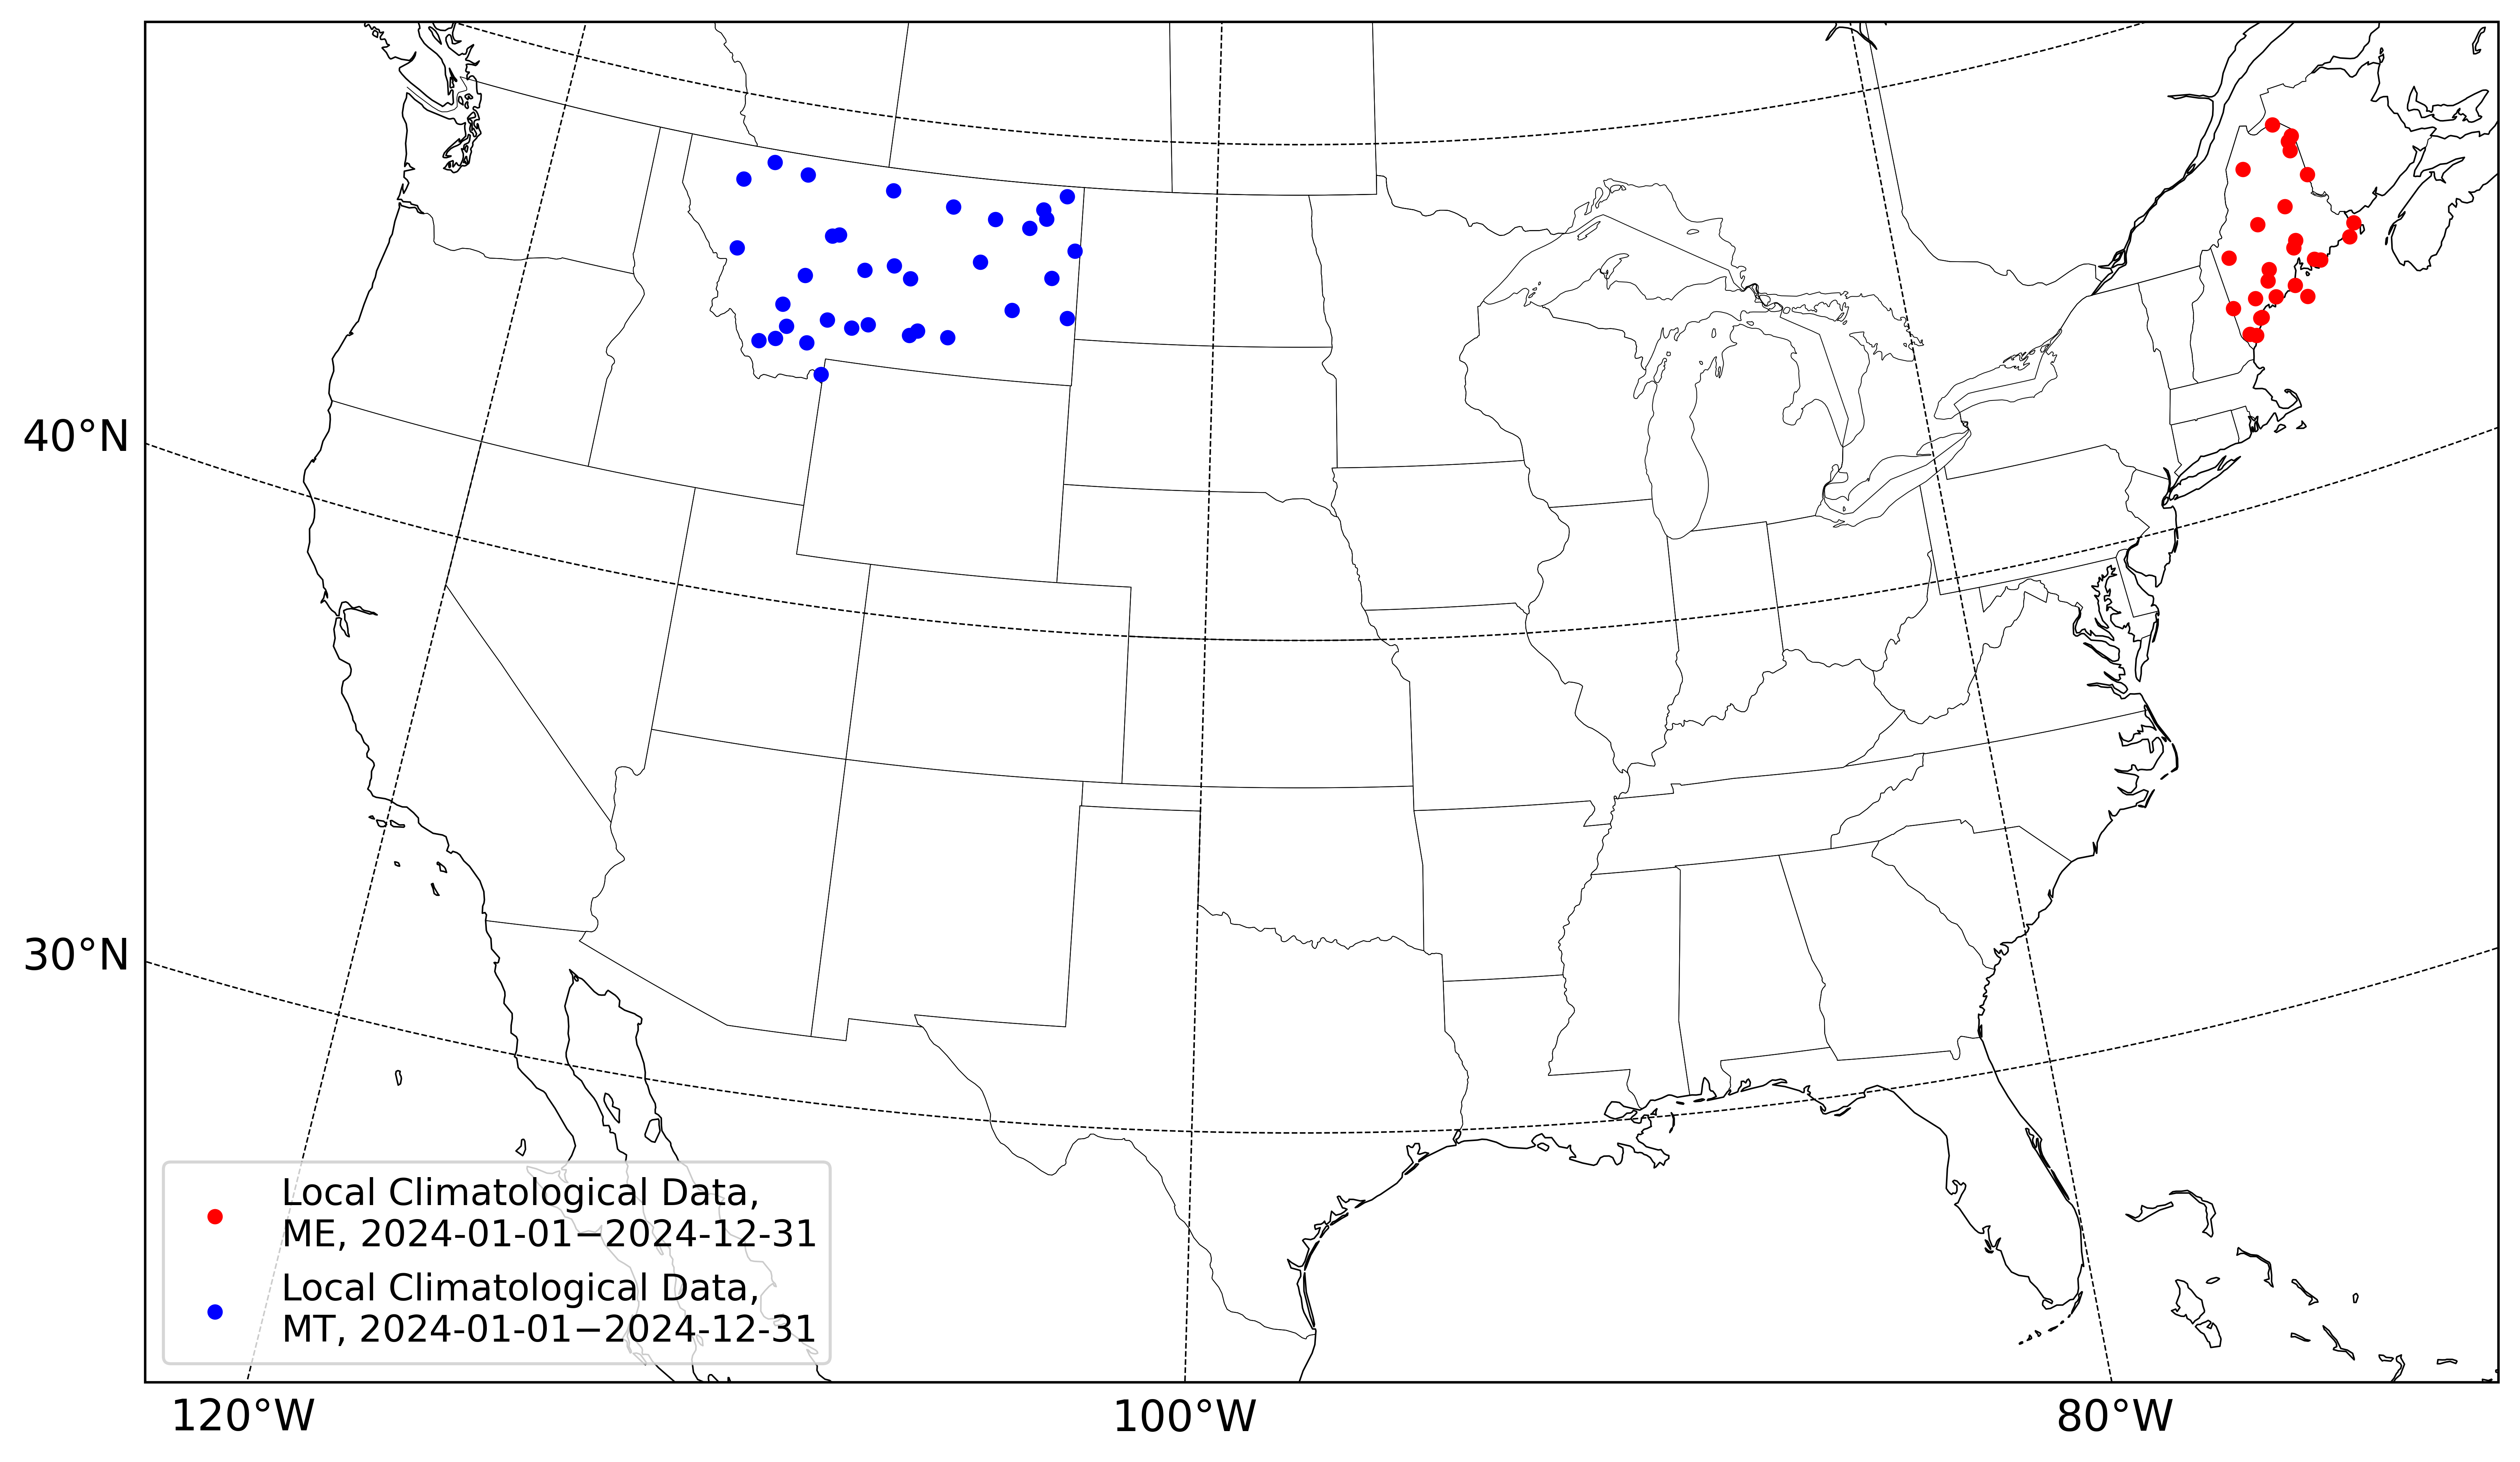

In [36]:
display(Image(filename=obs_locations_map_plot))

### Time series plots

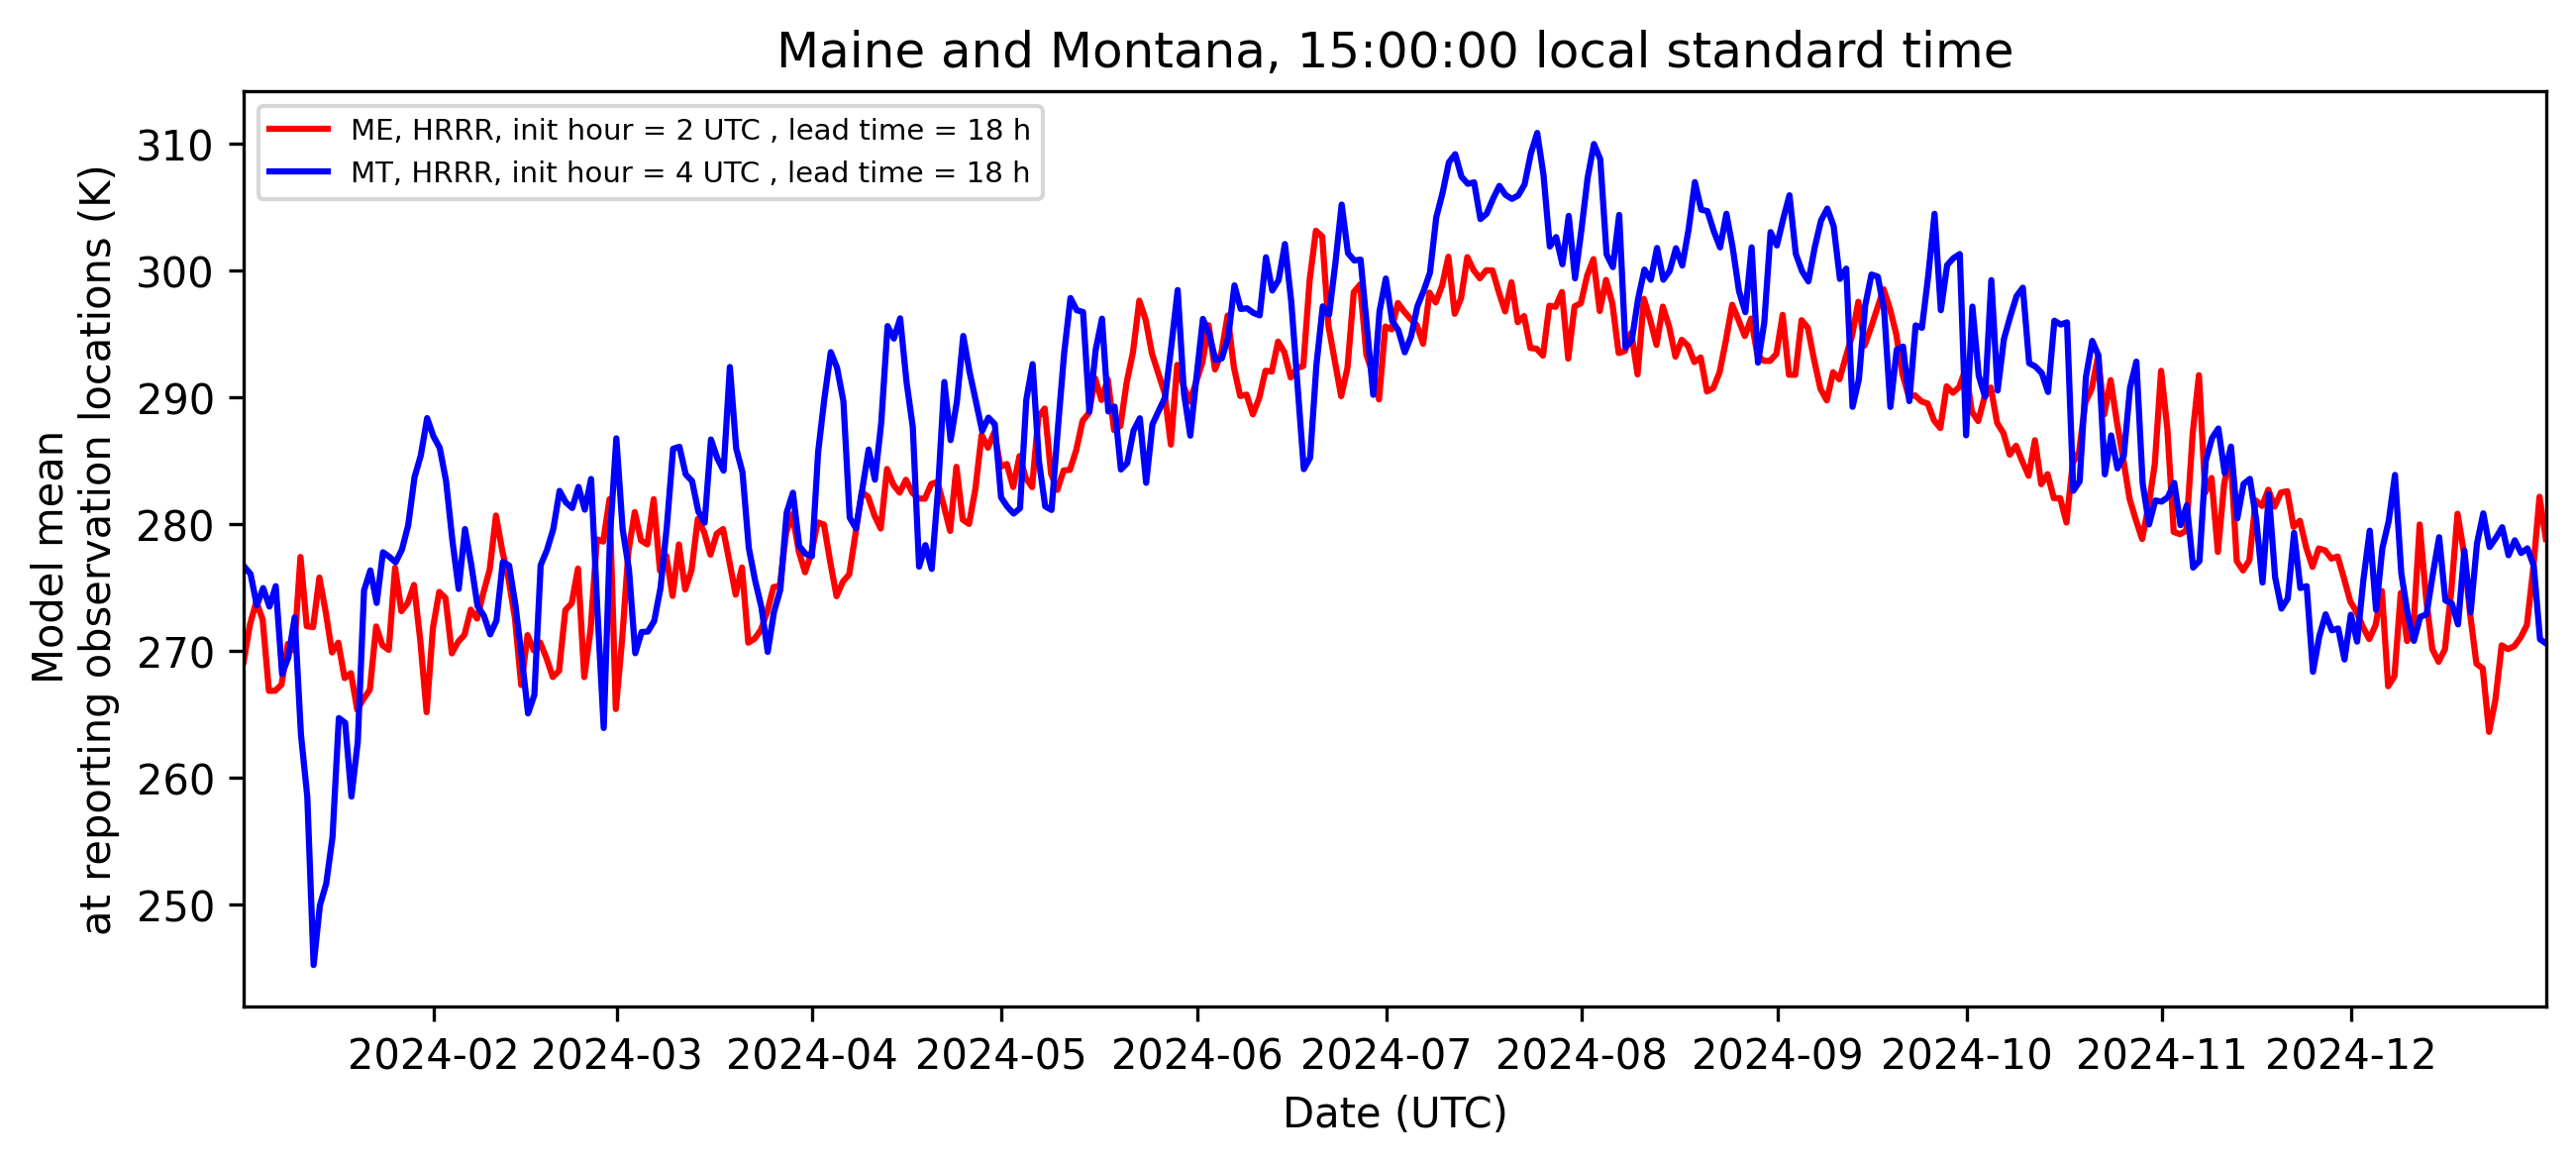

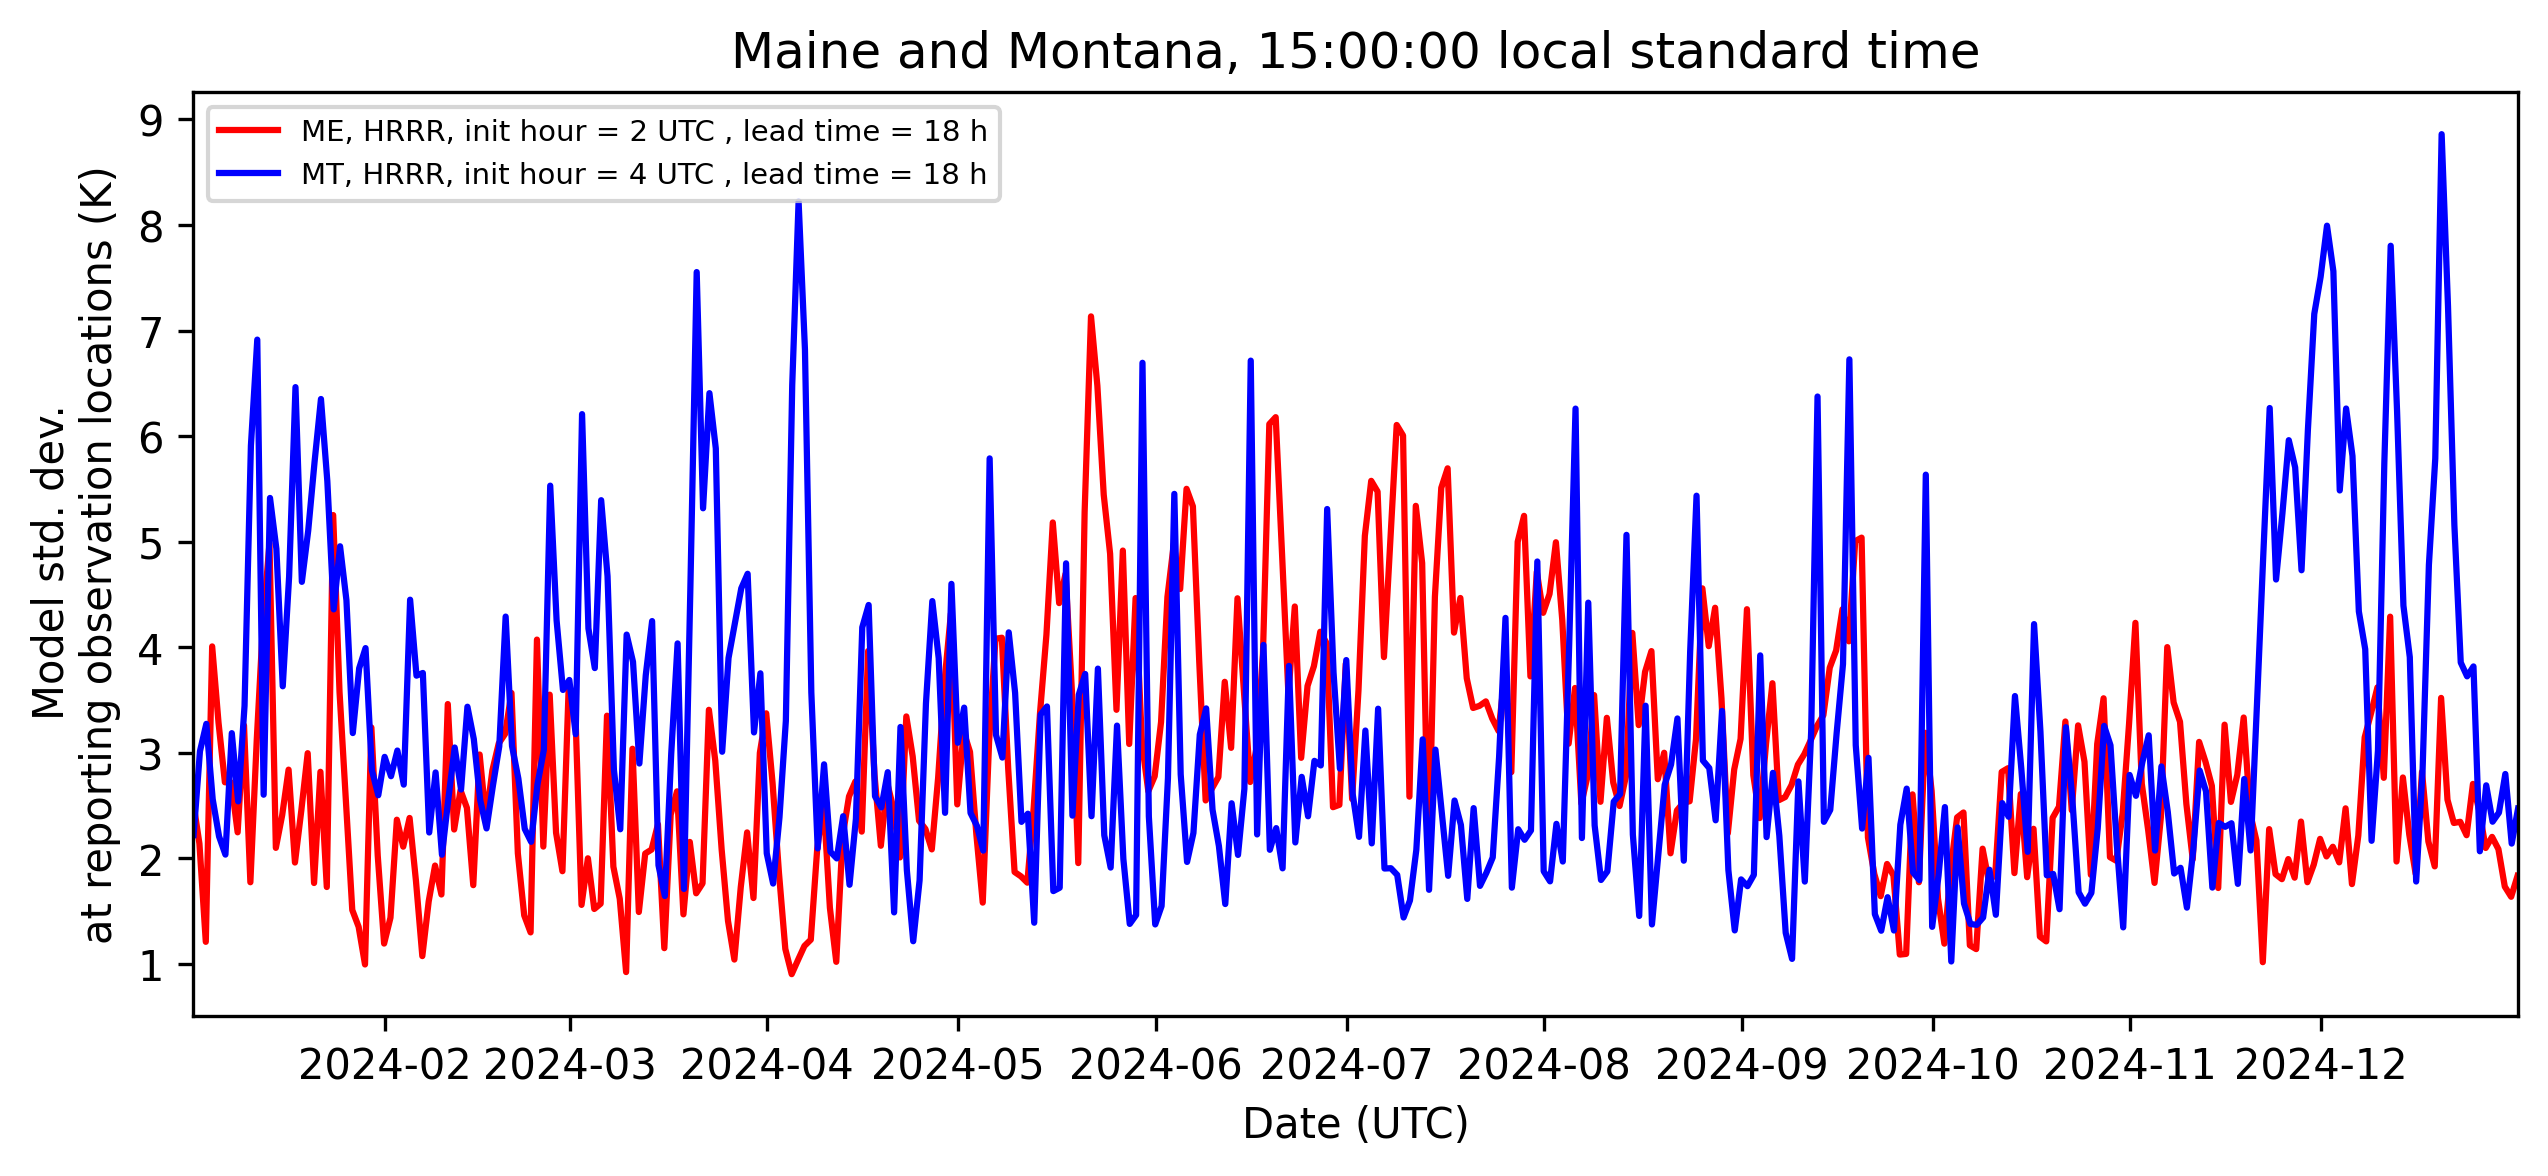

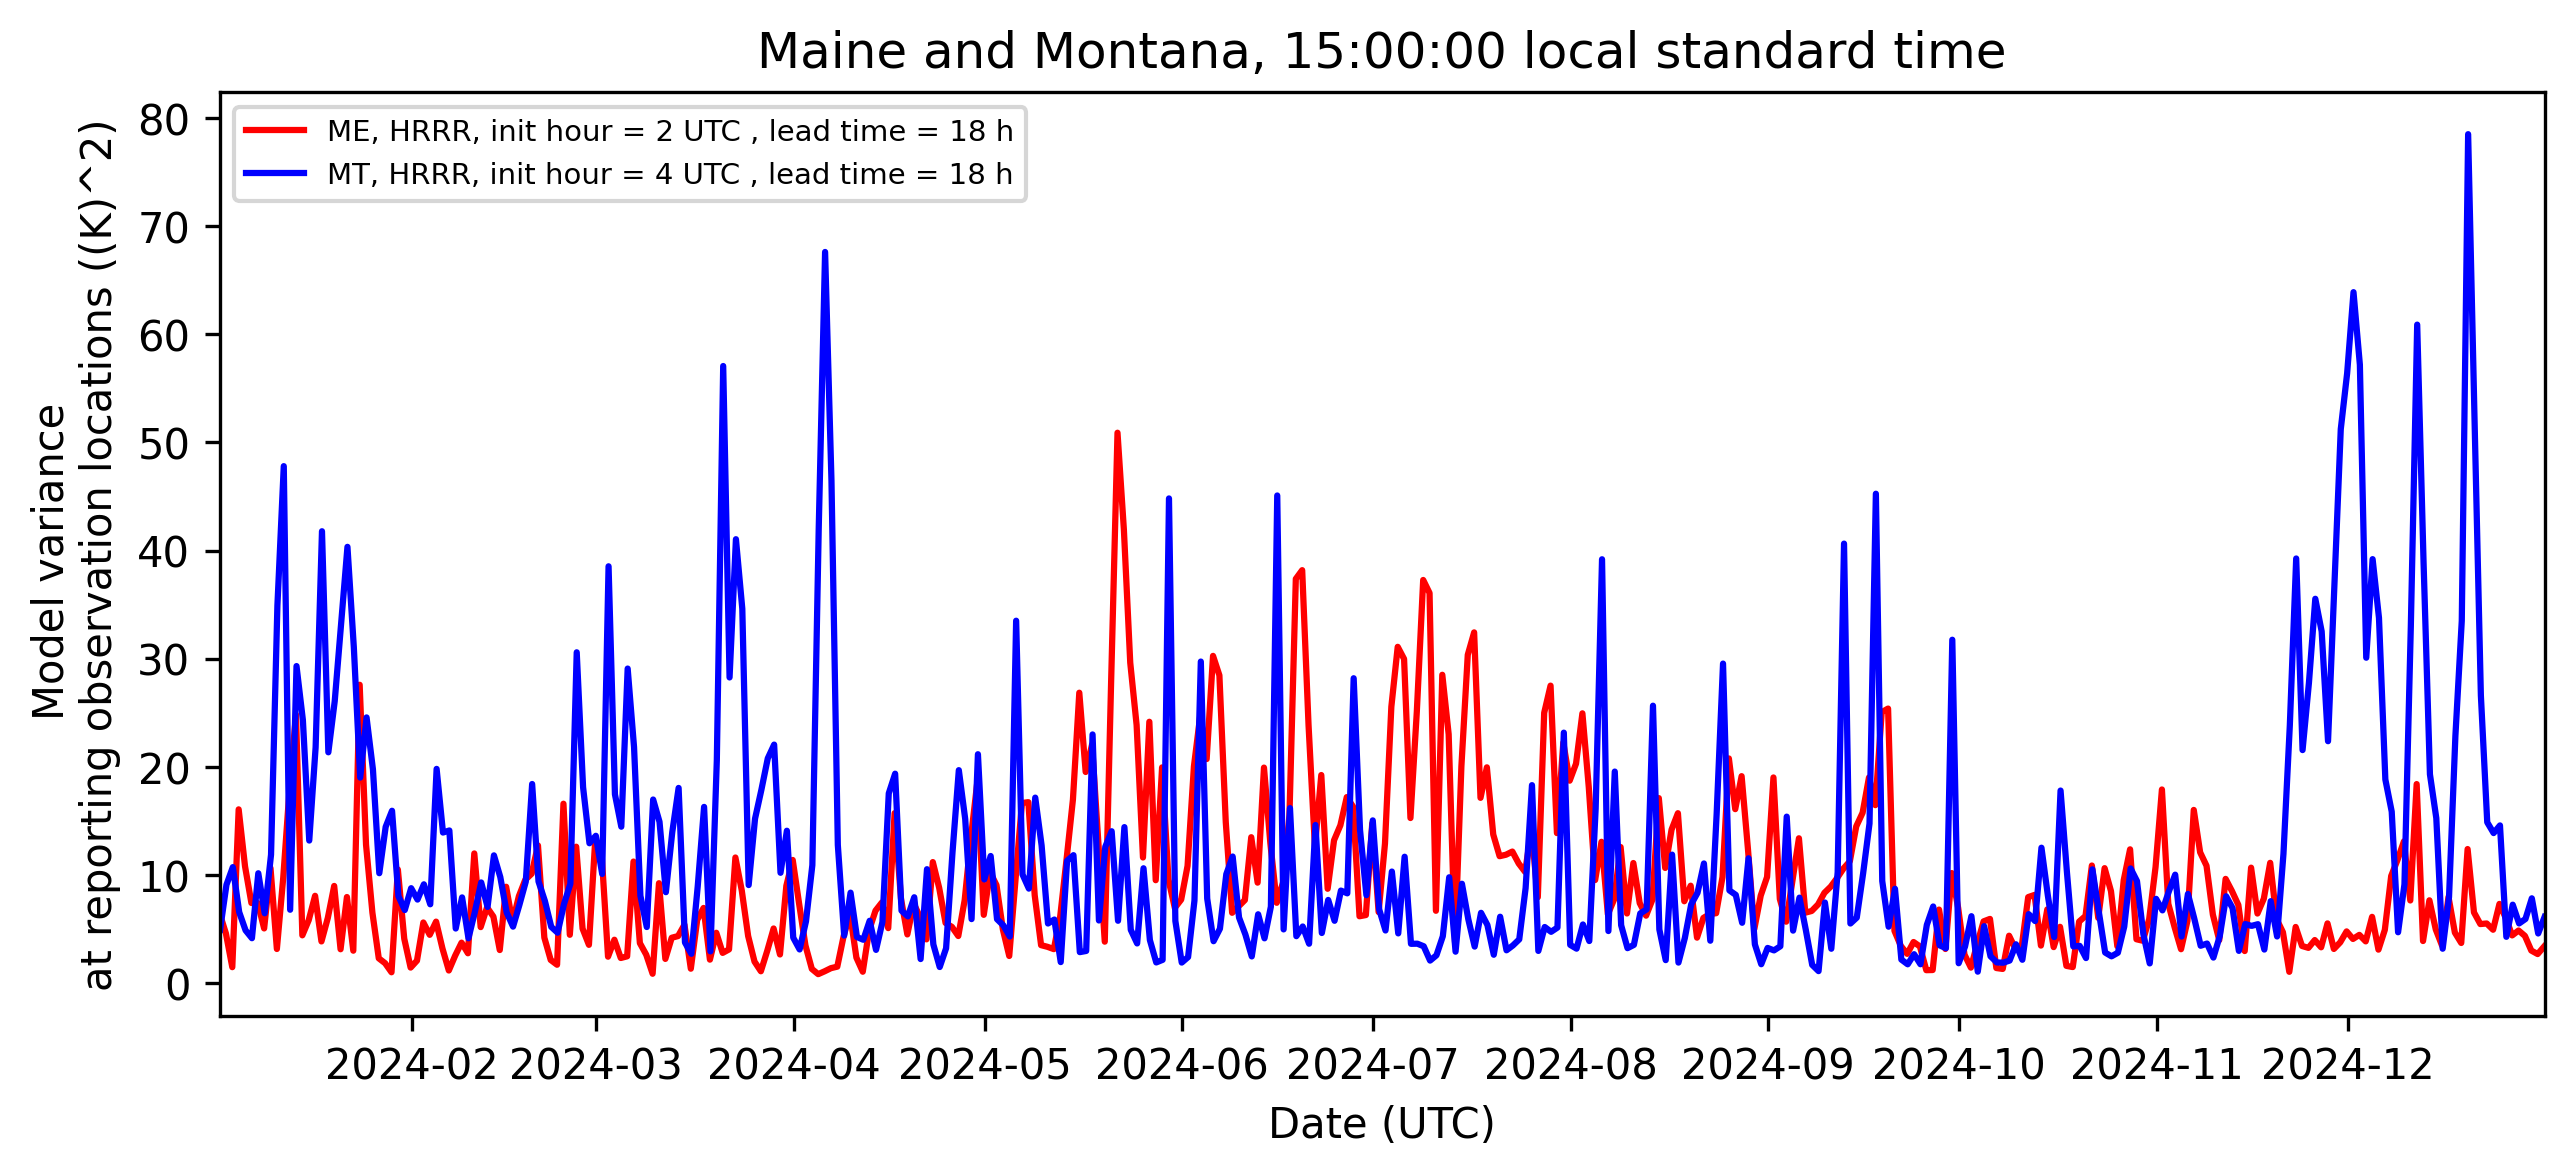

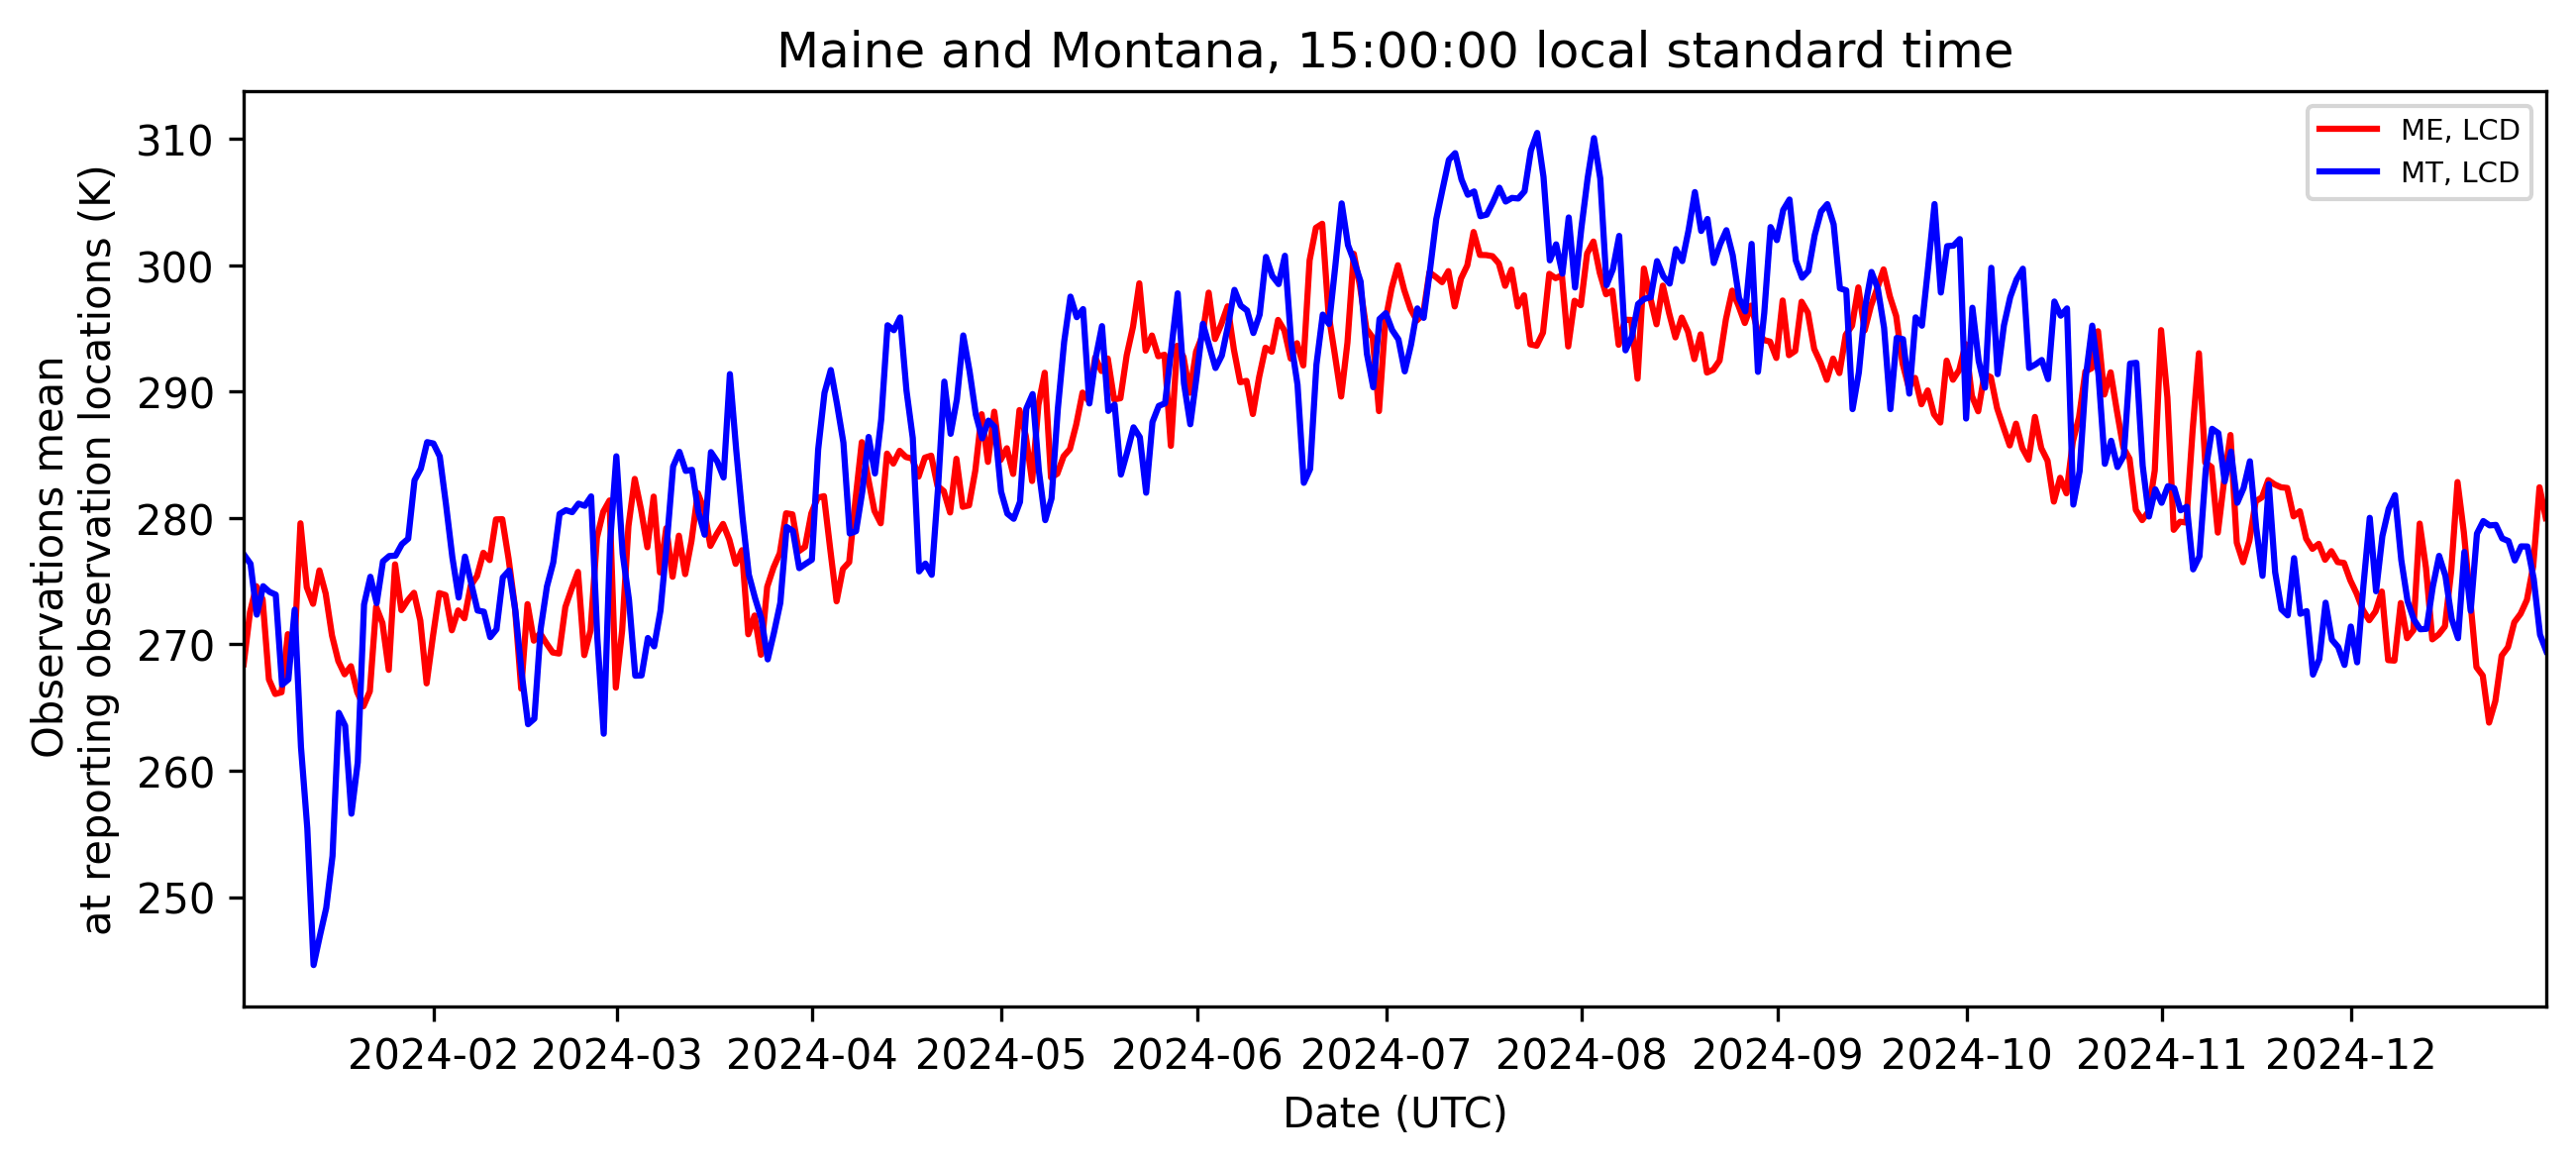

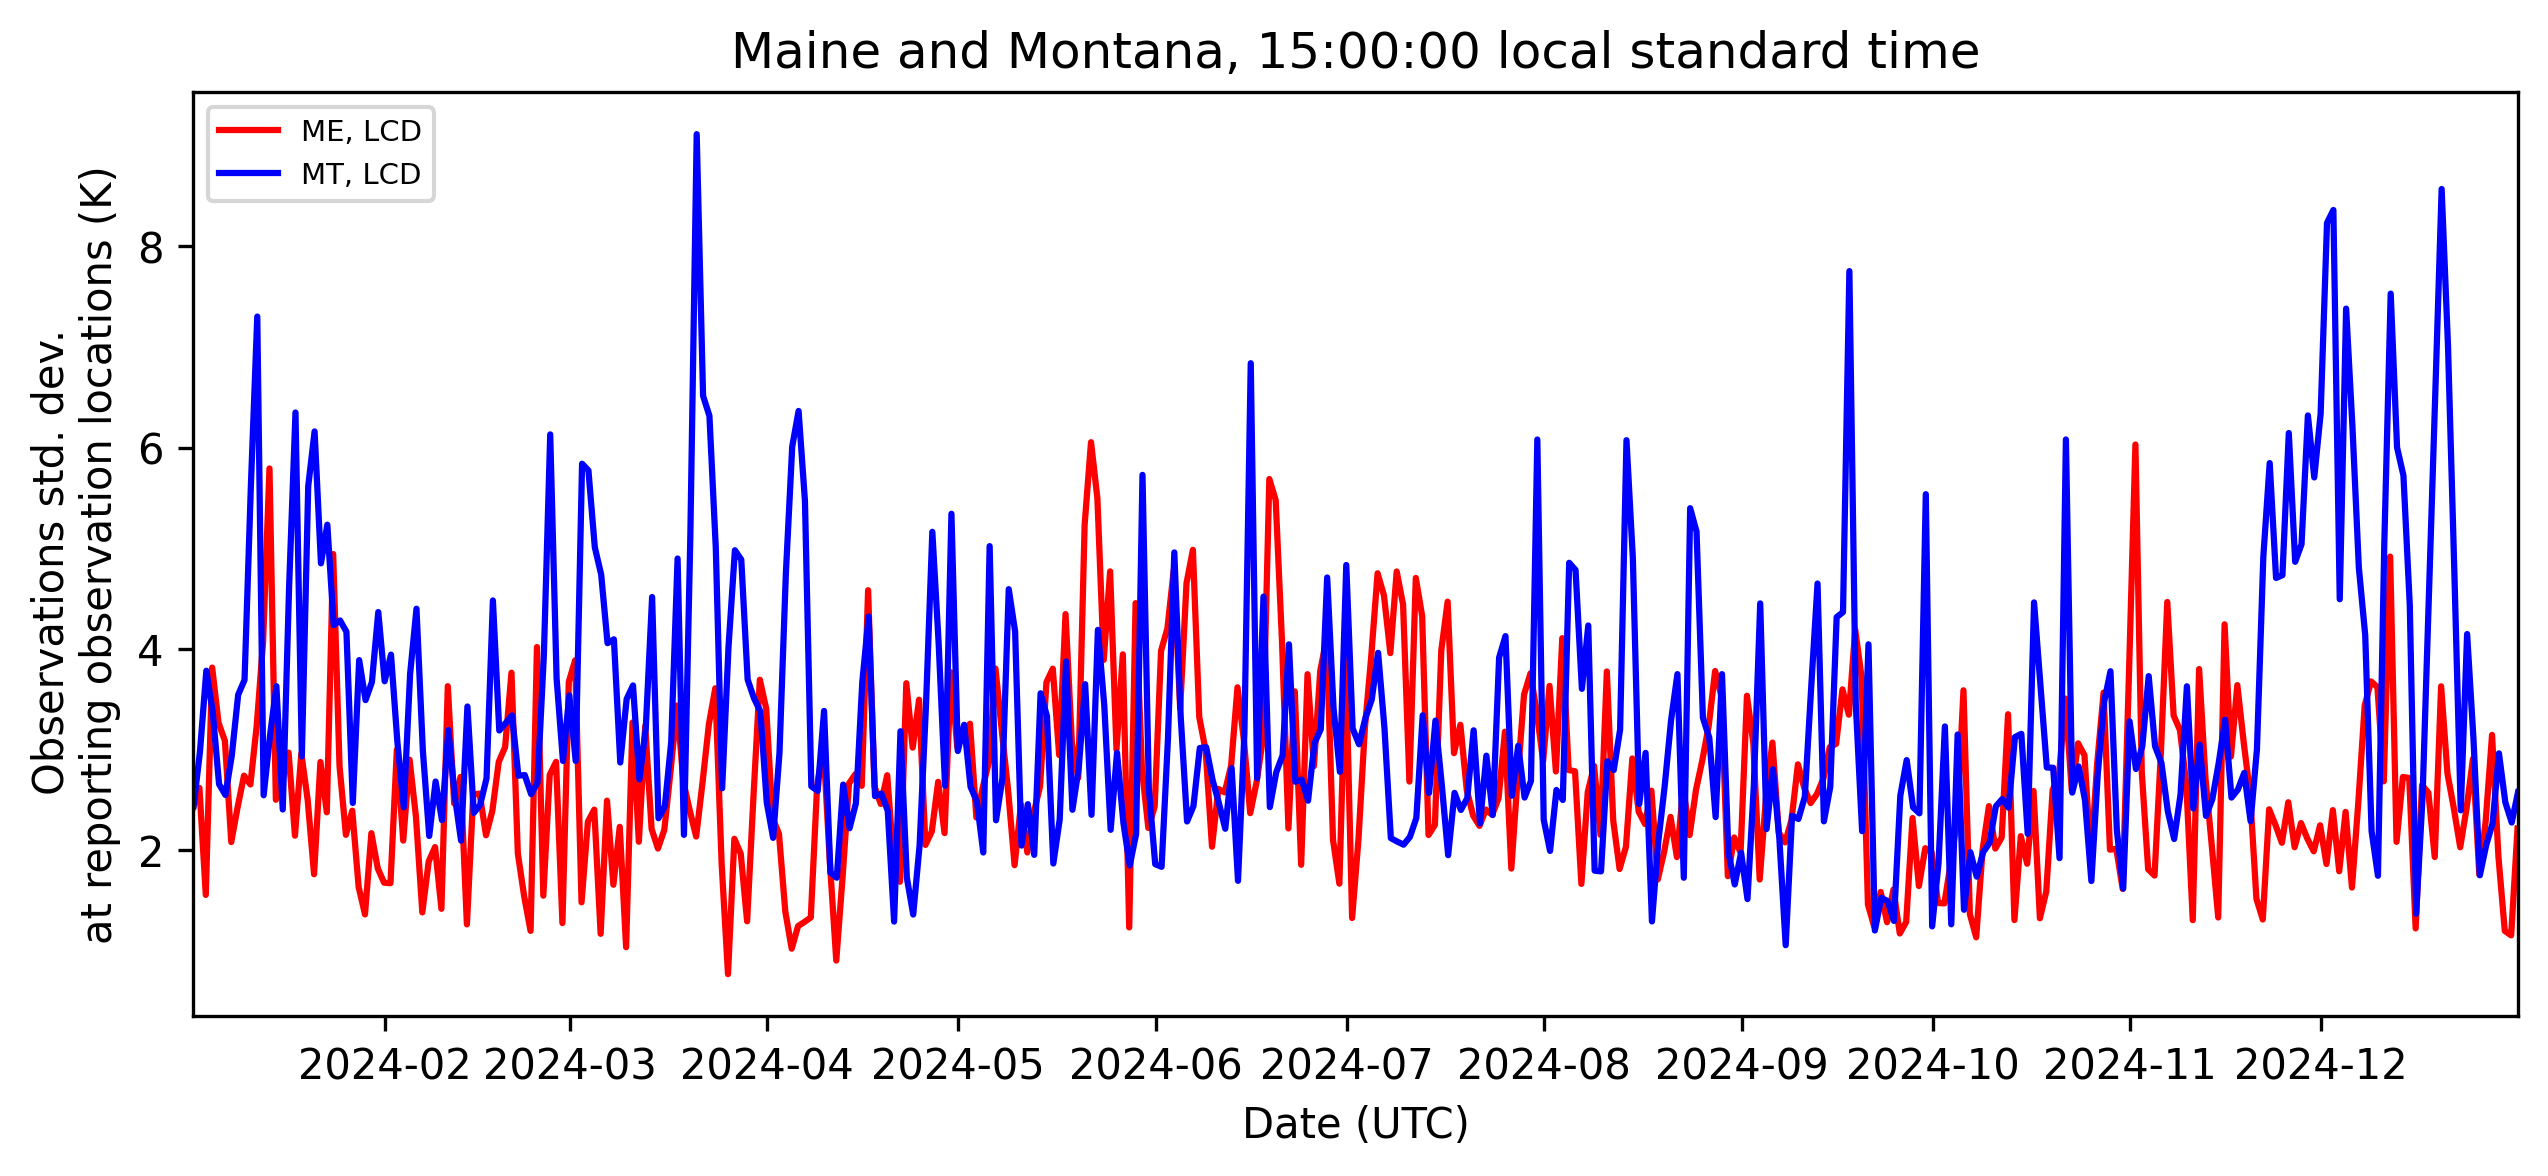

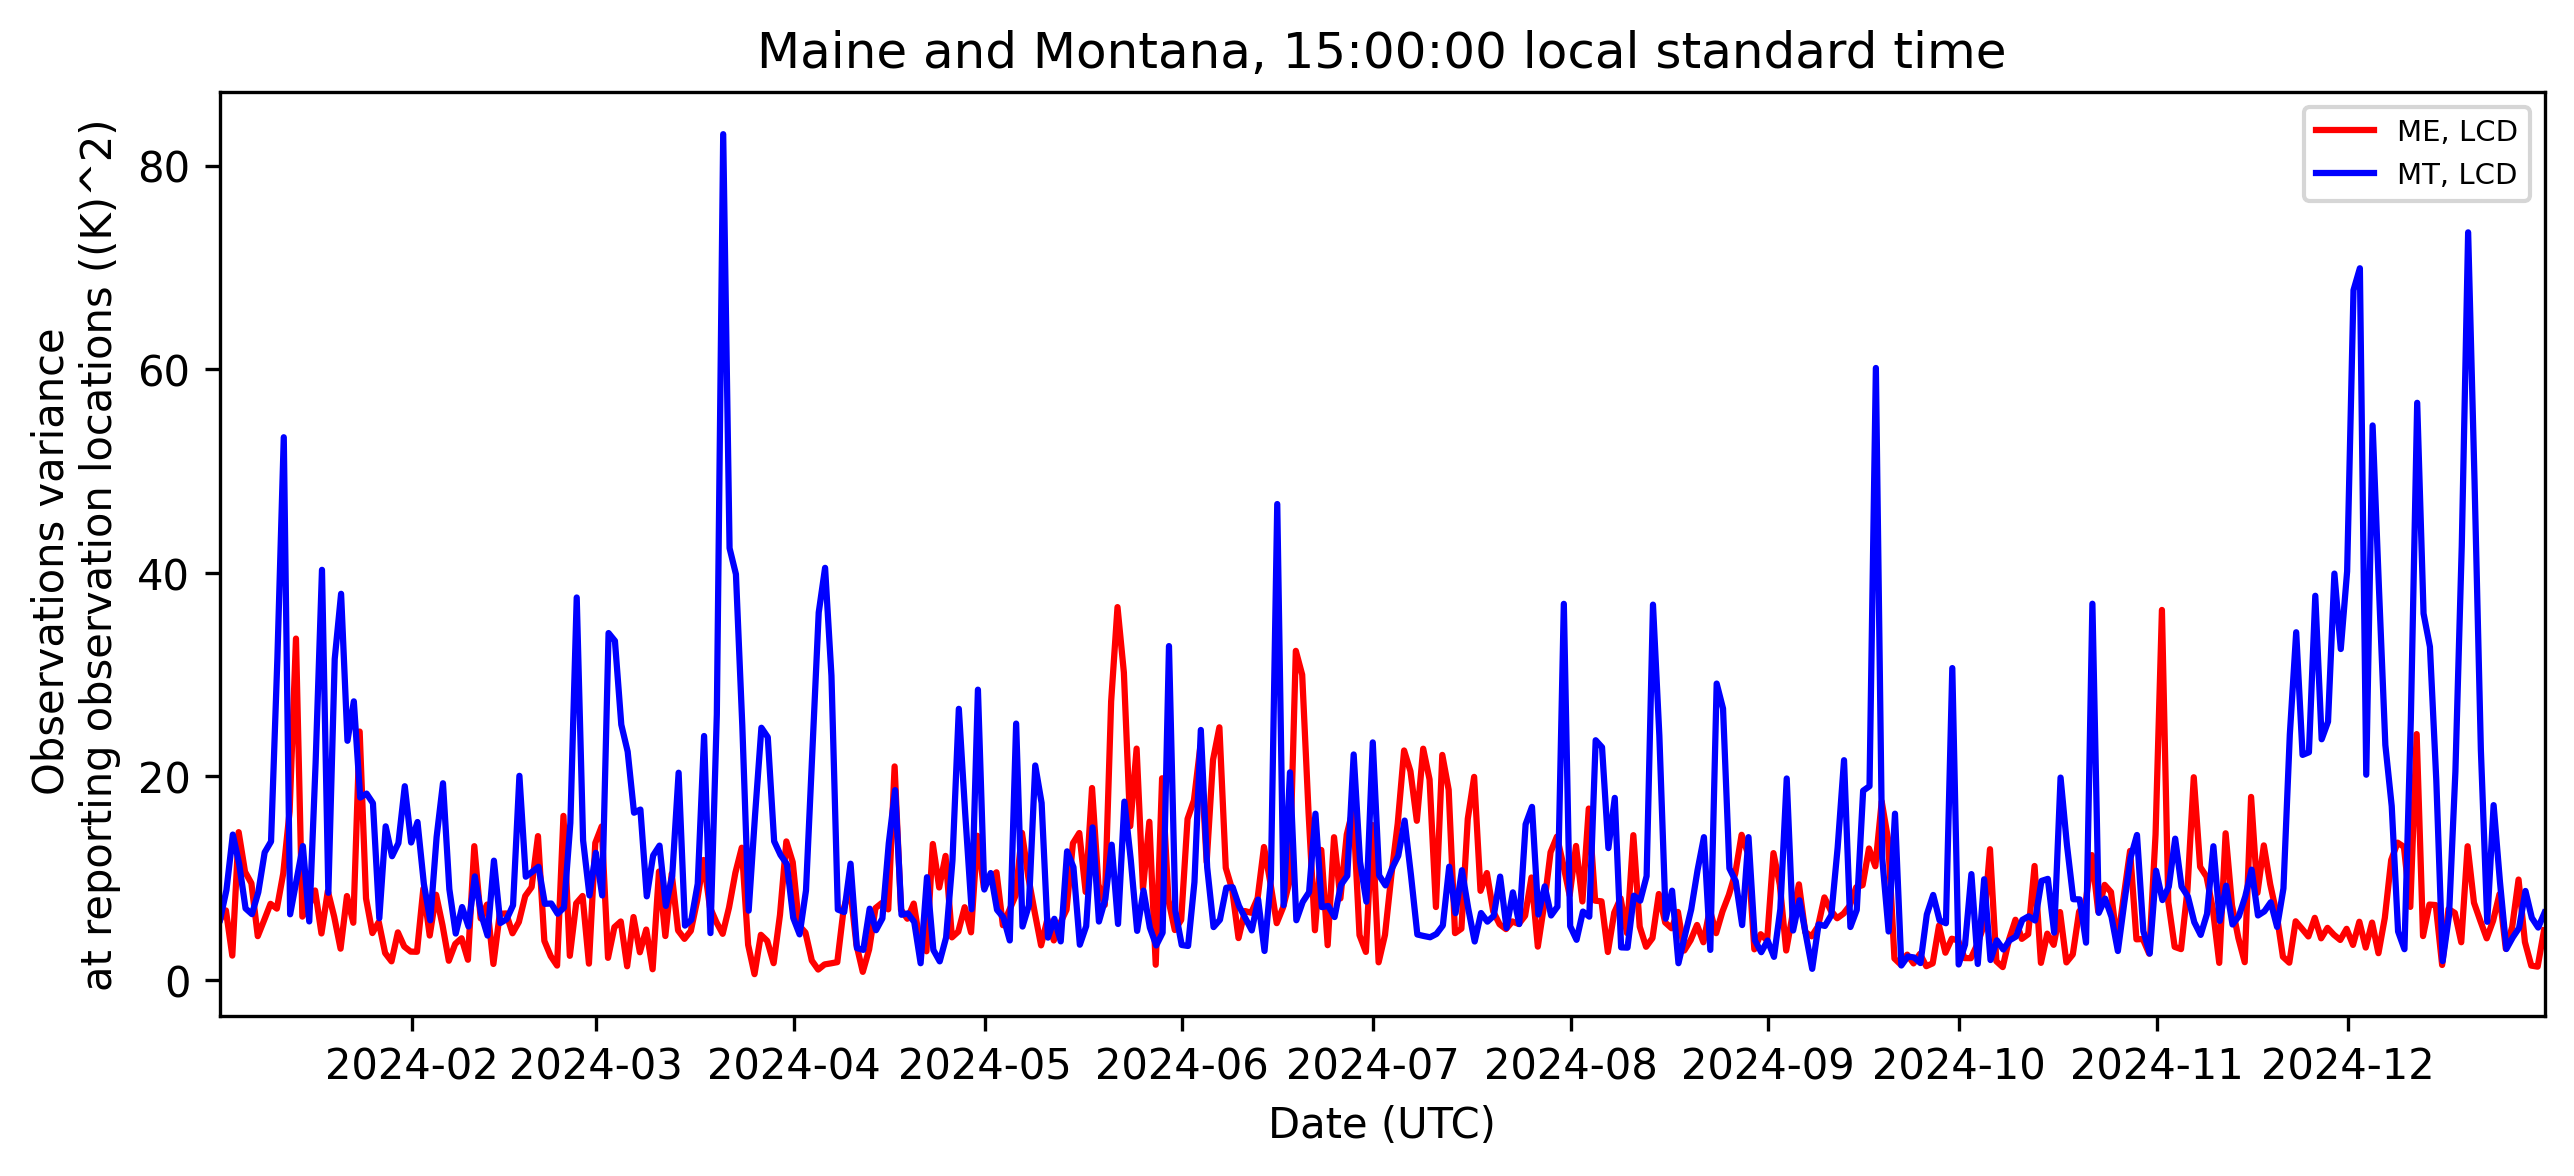

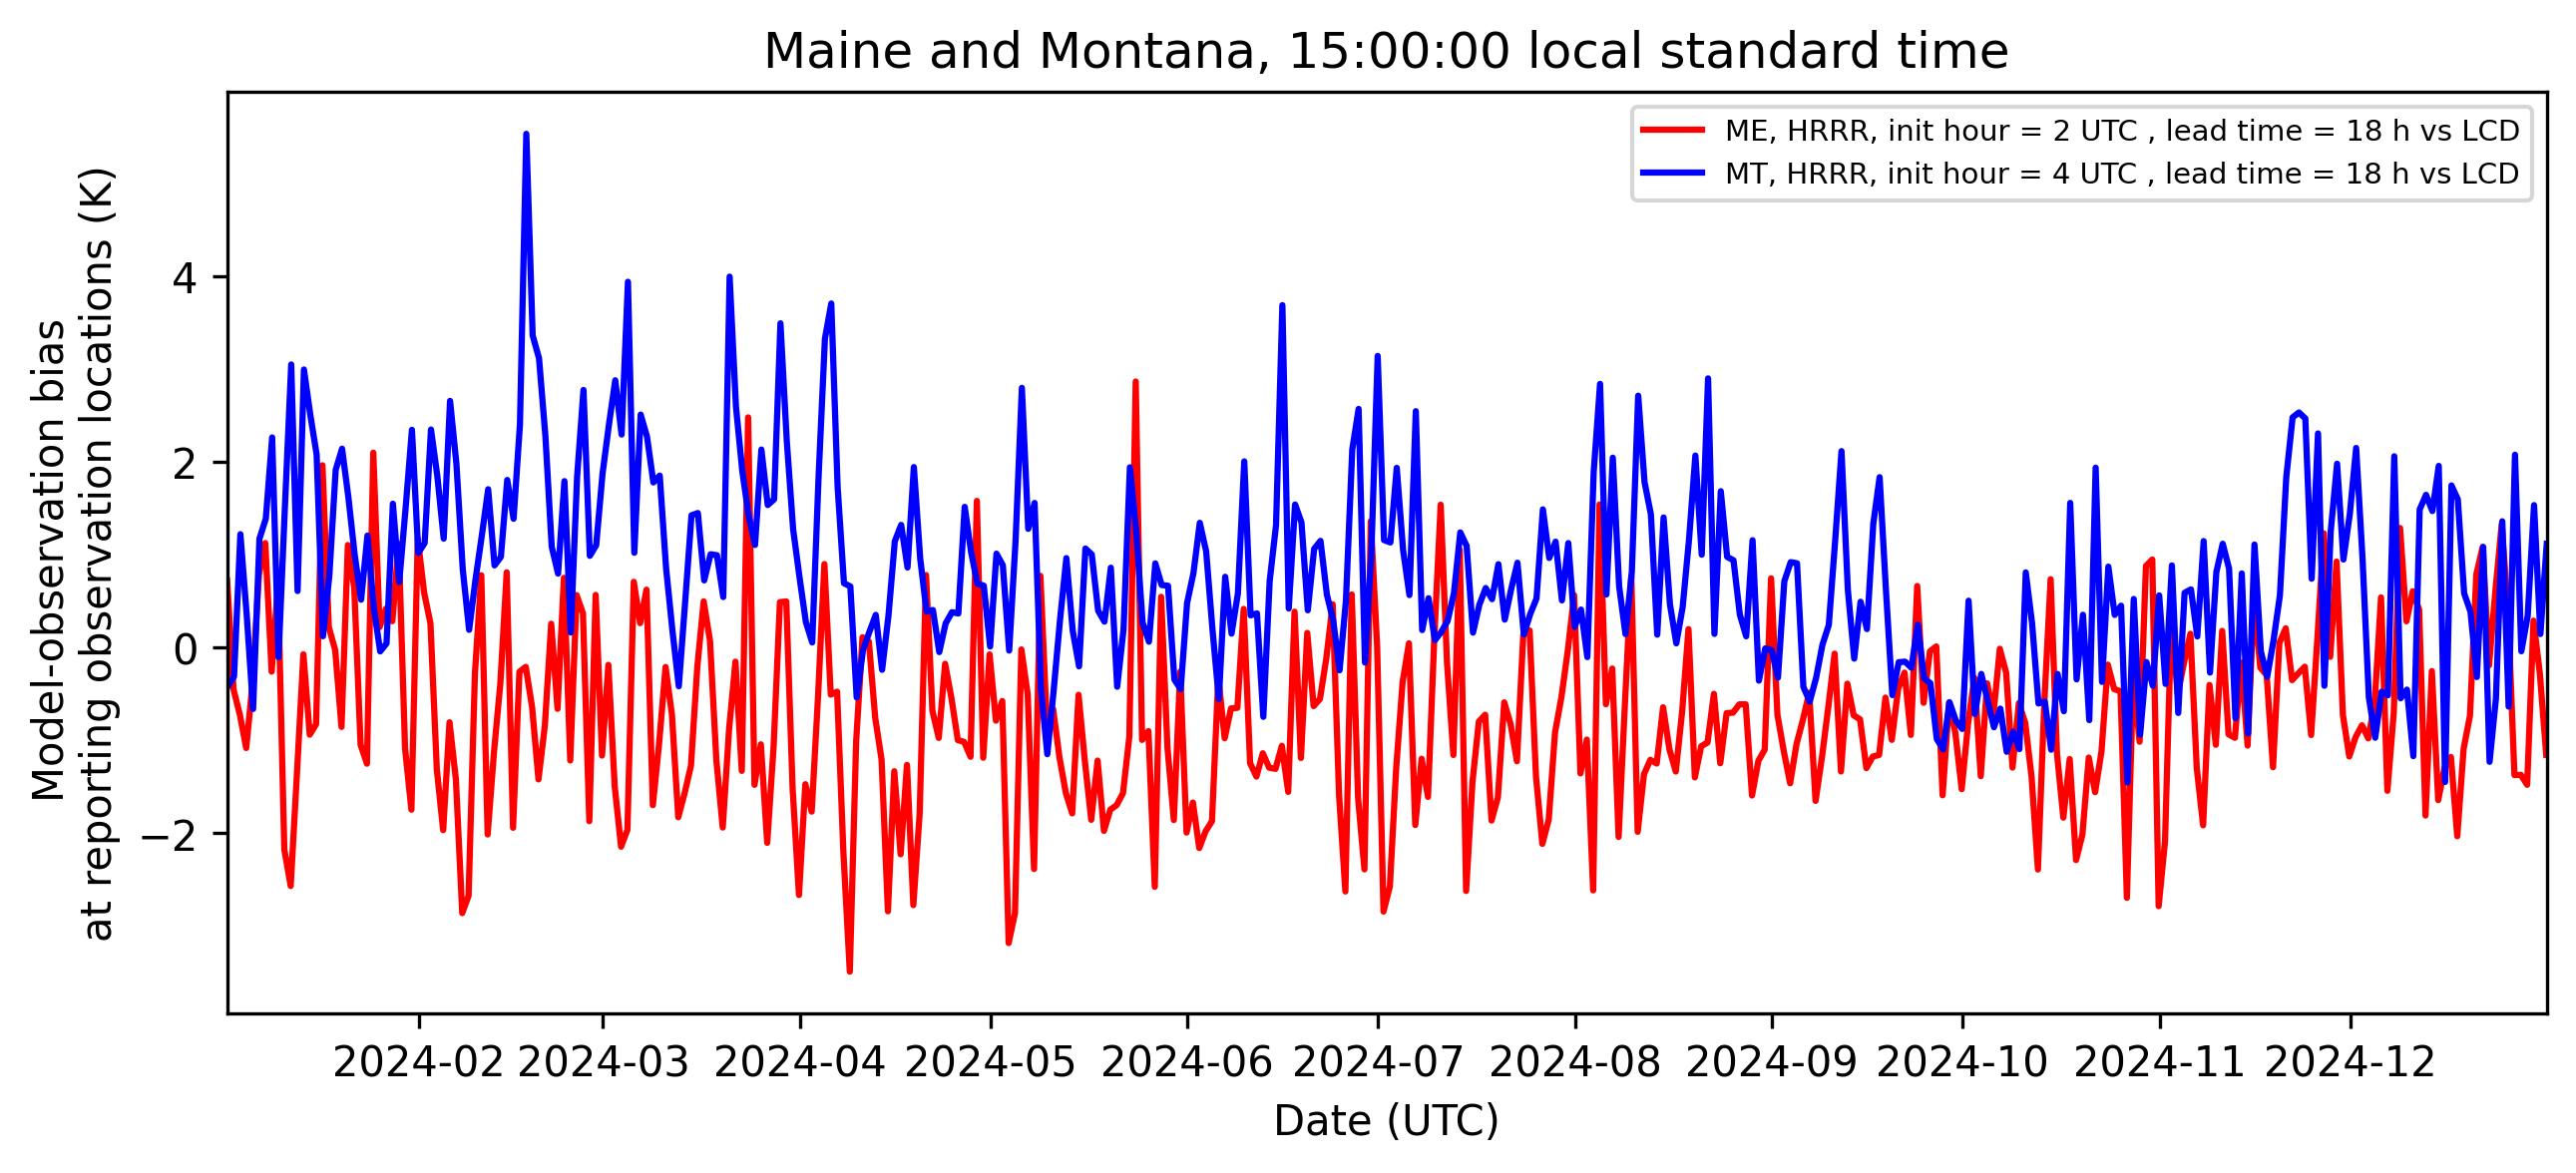

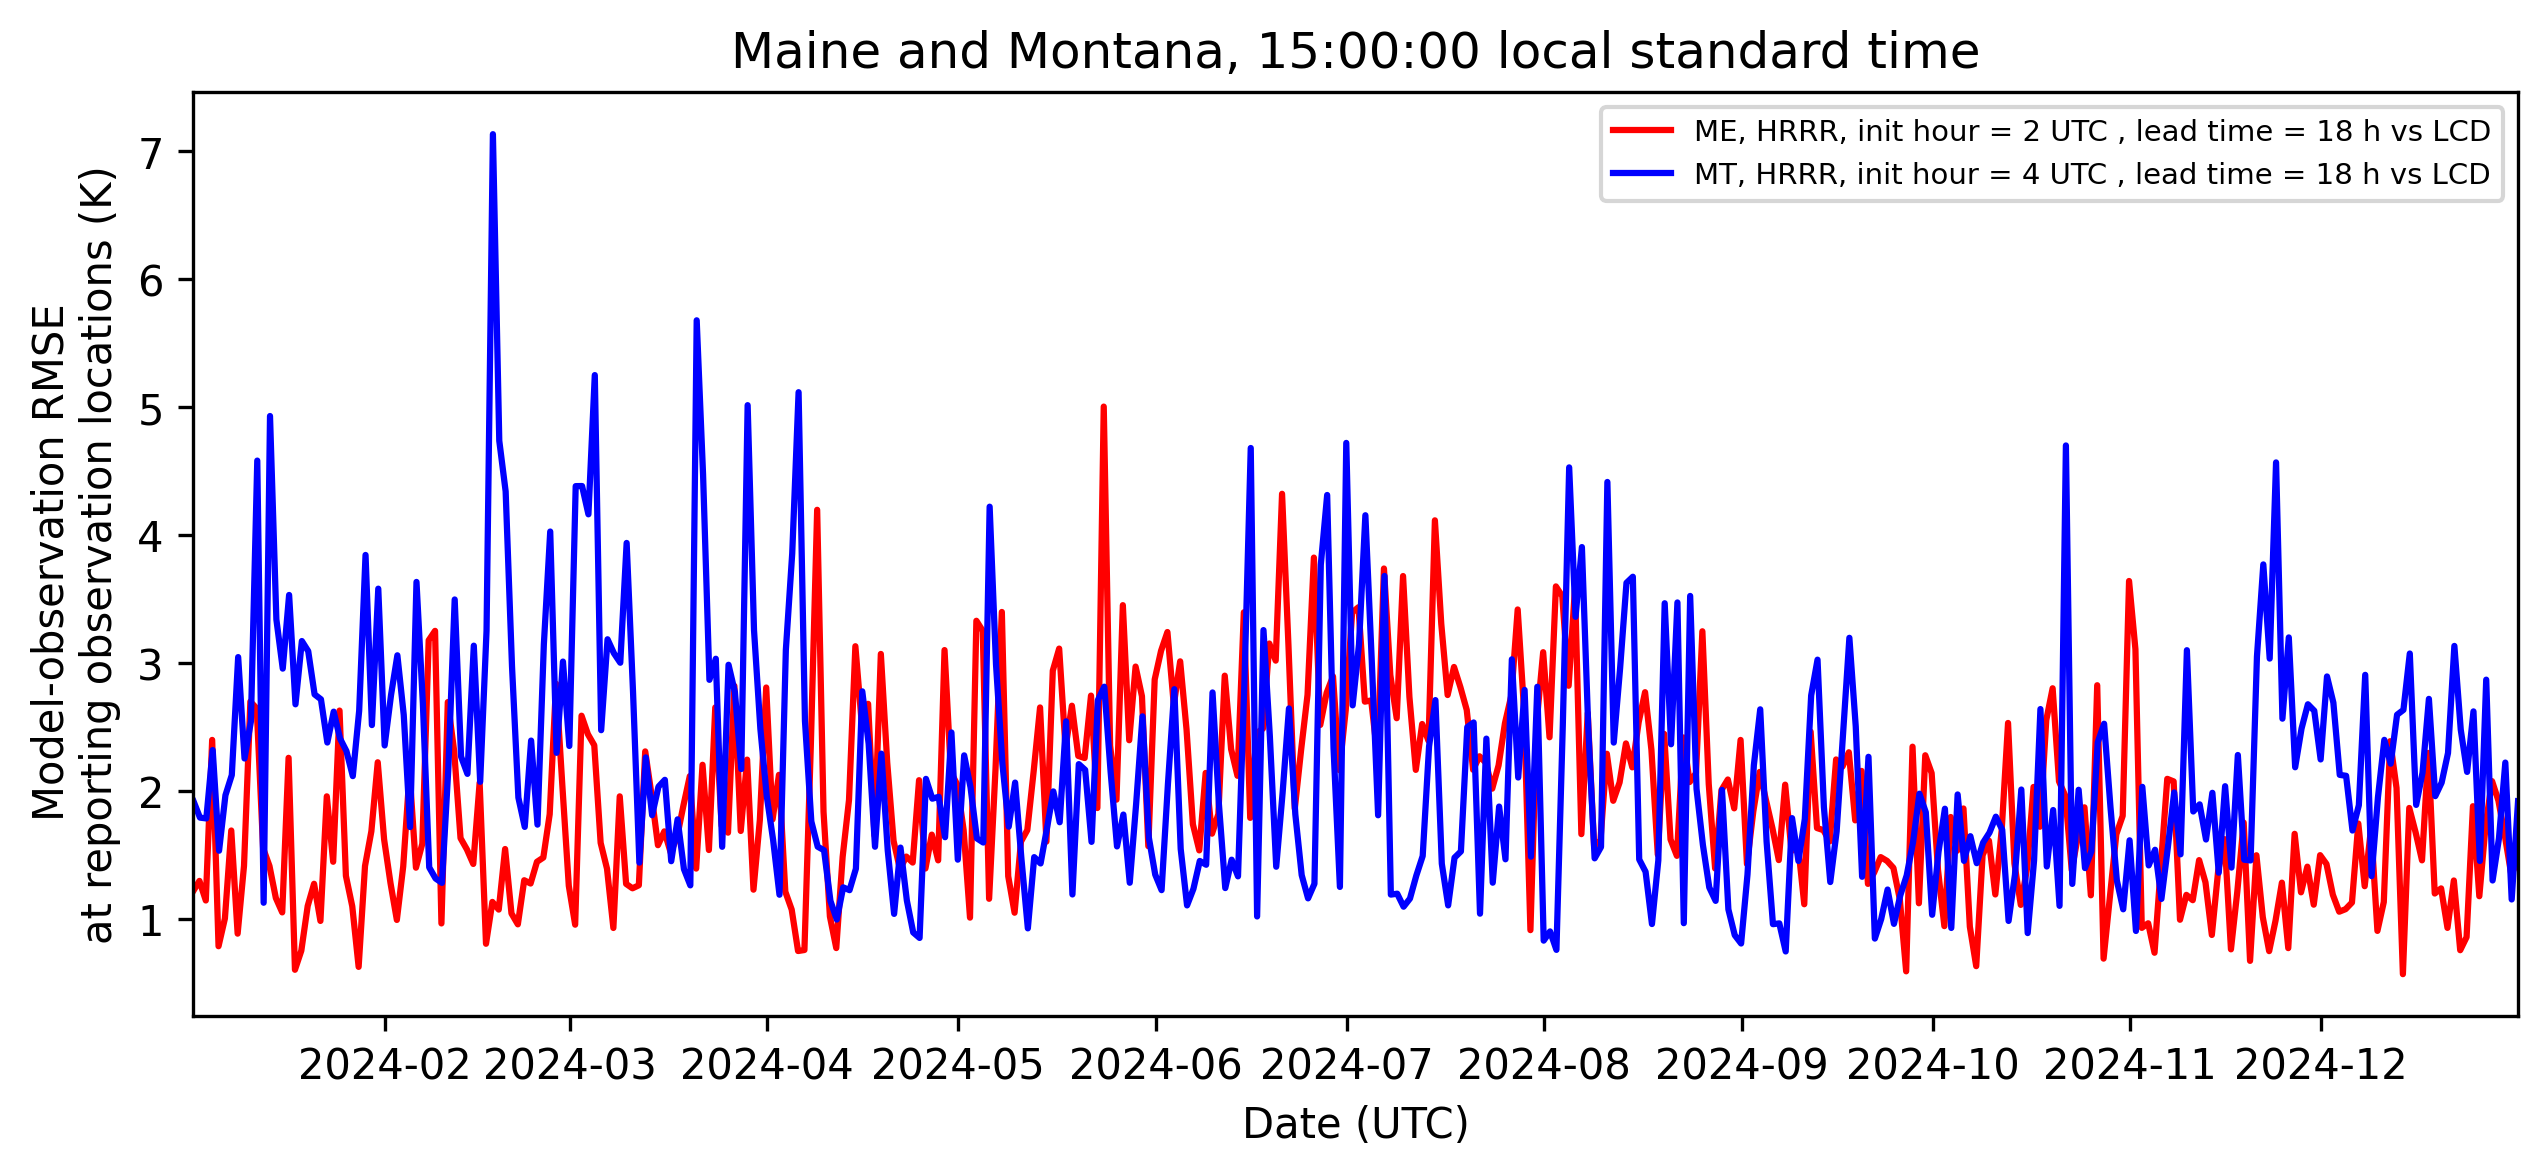

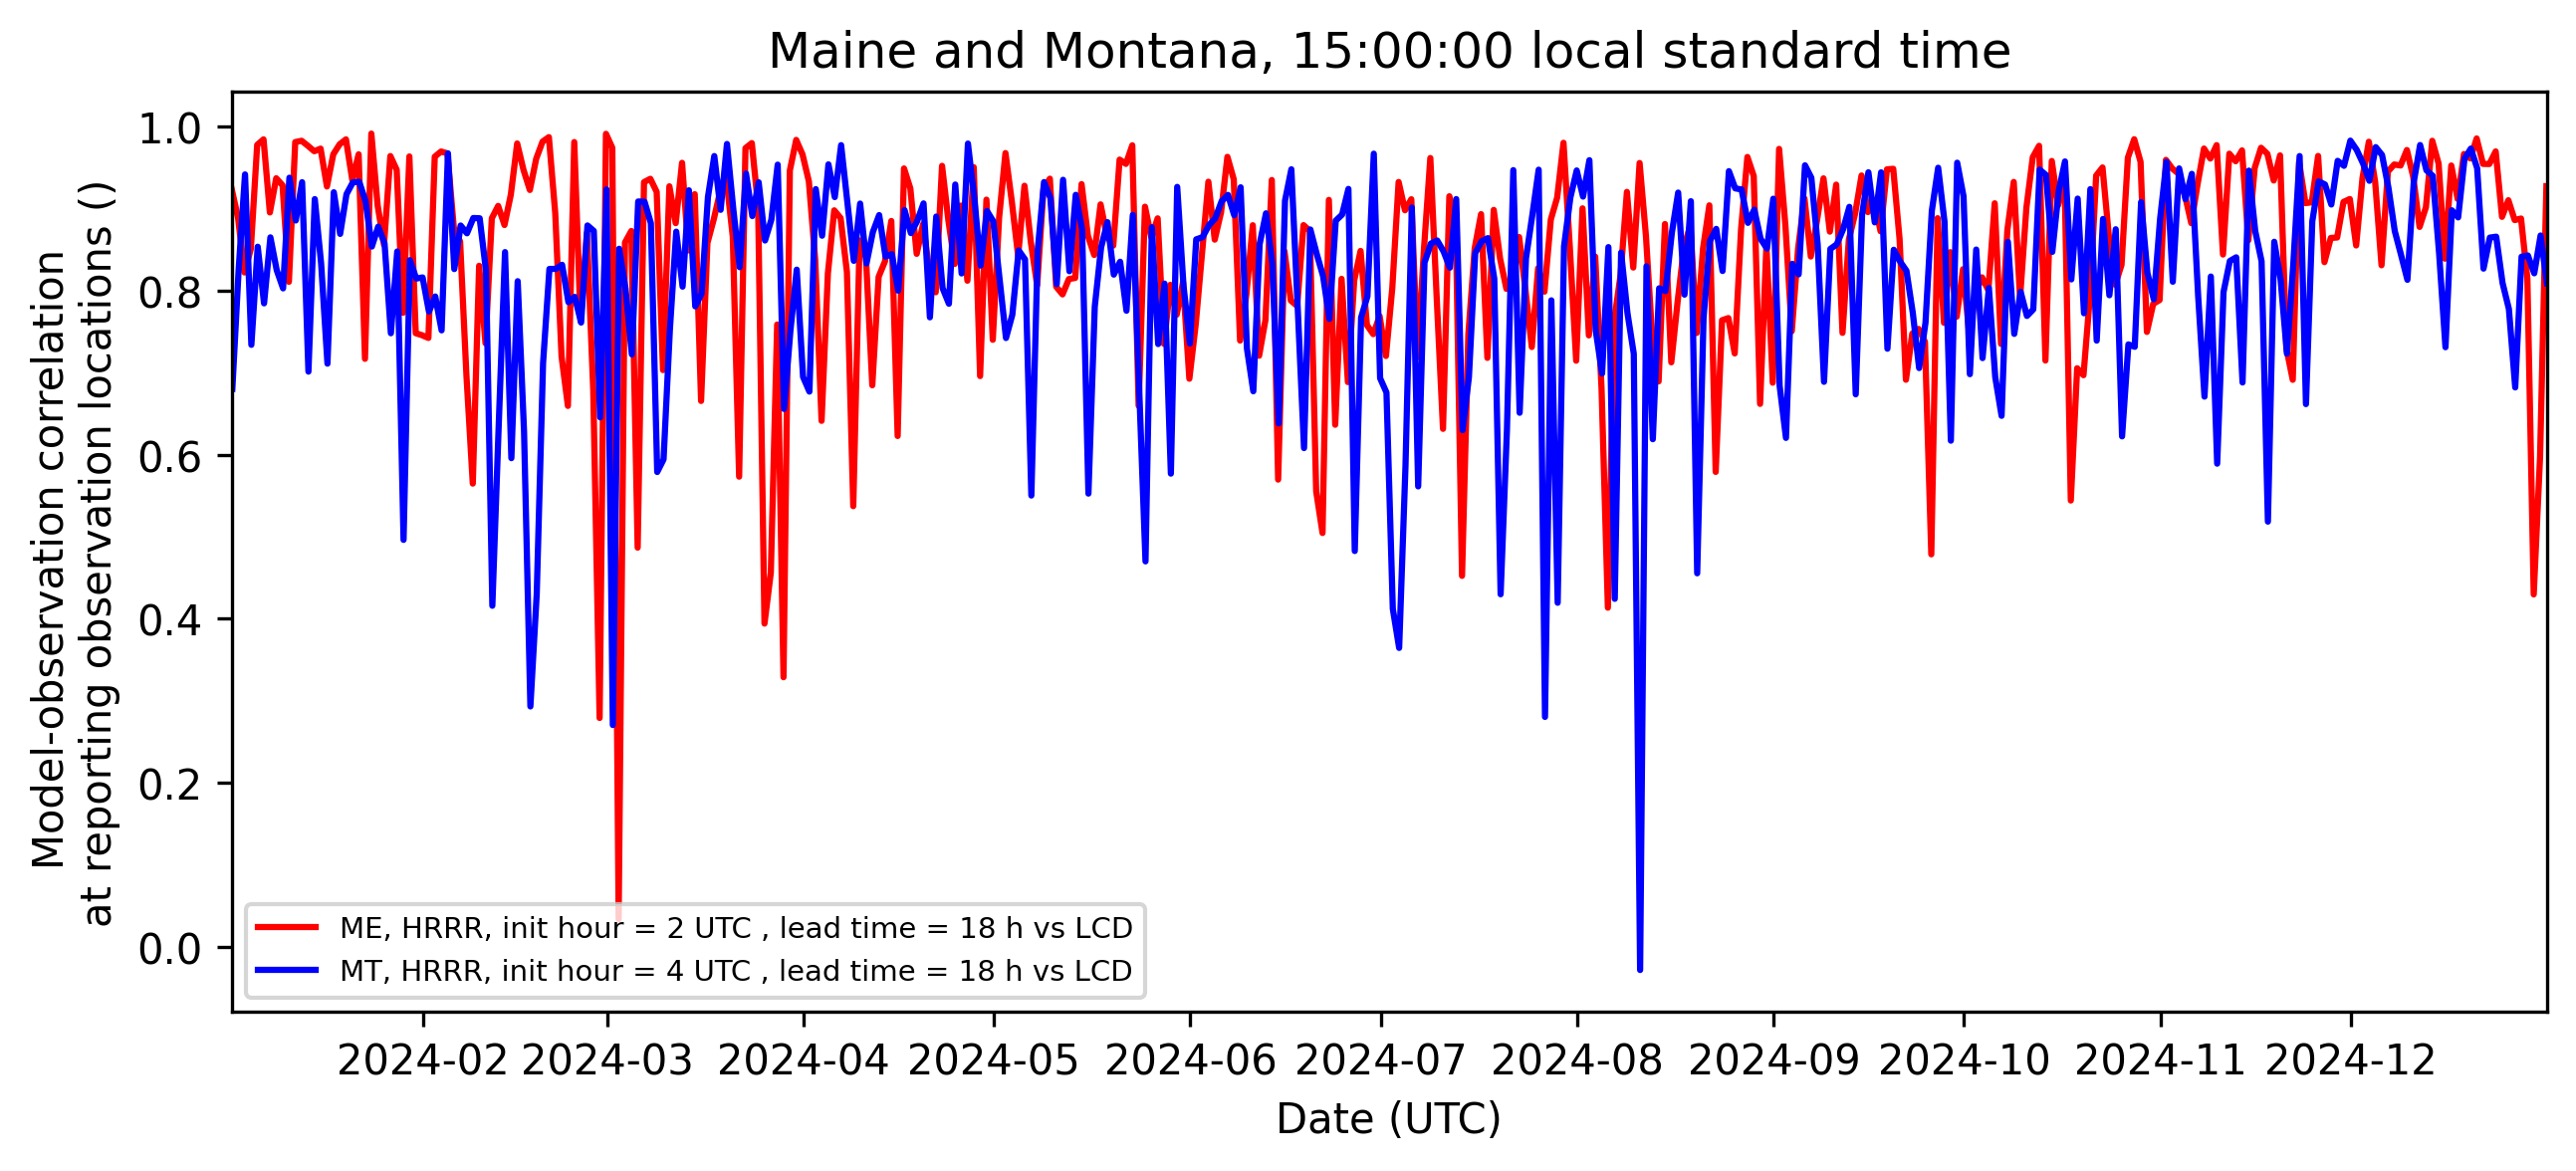

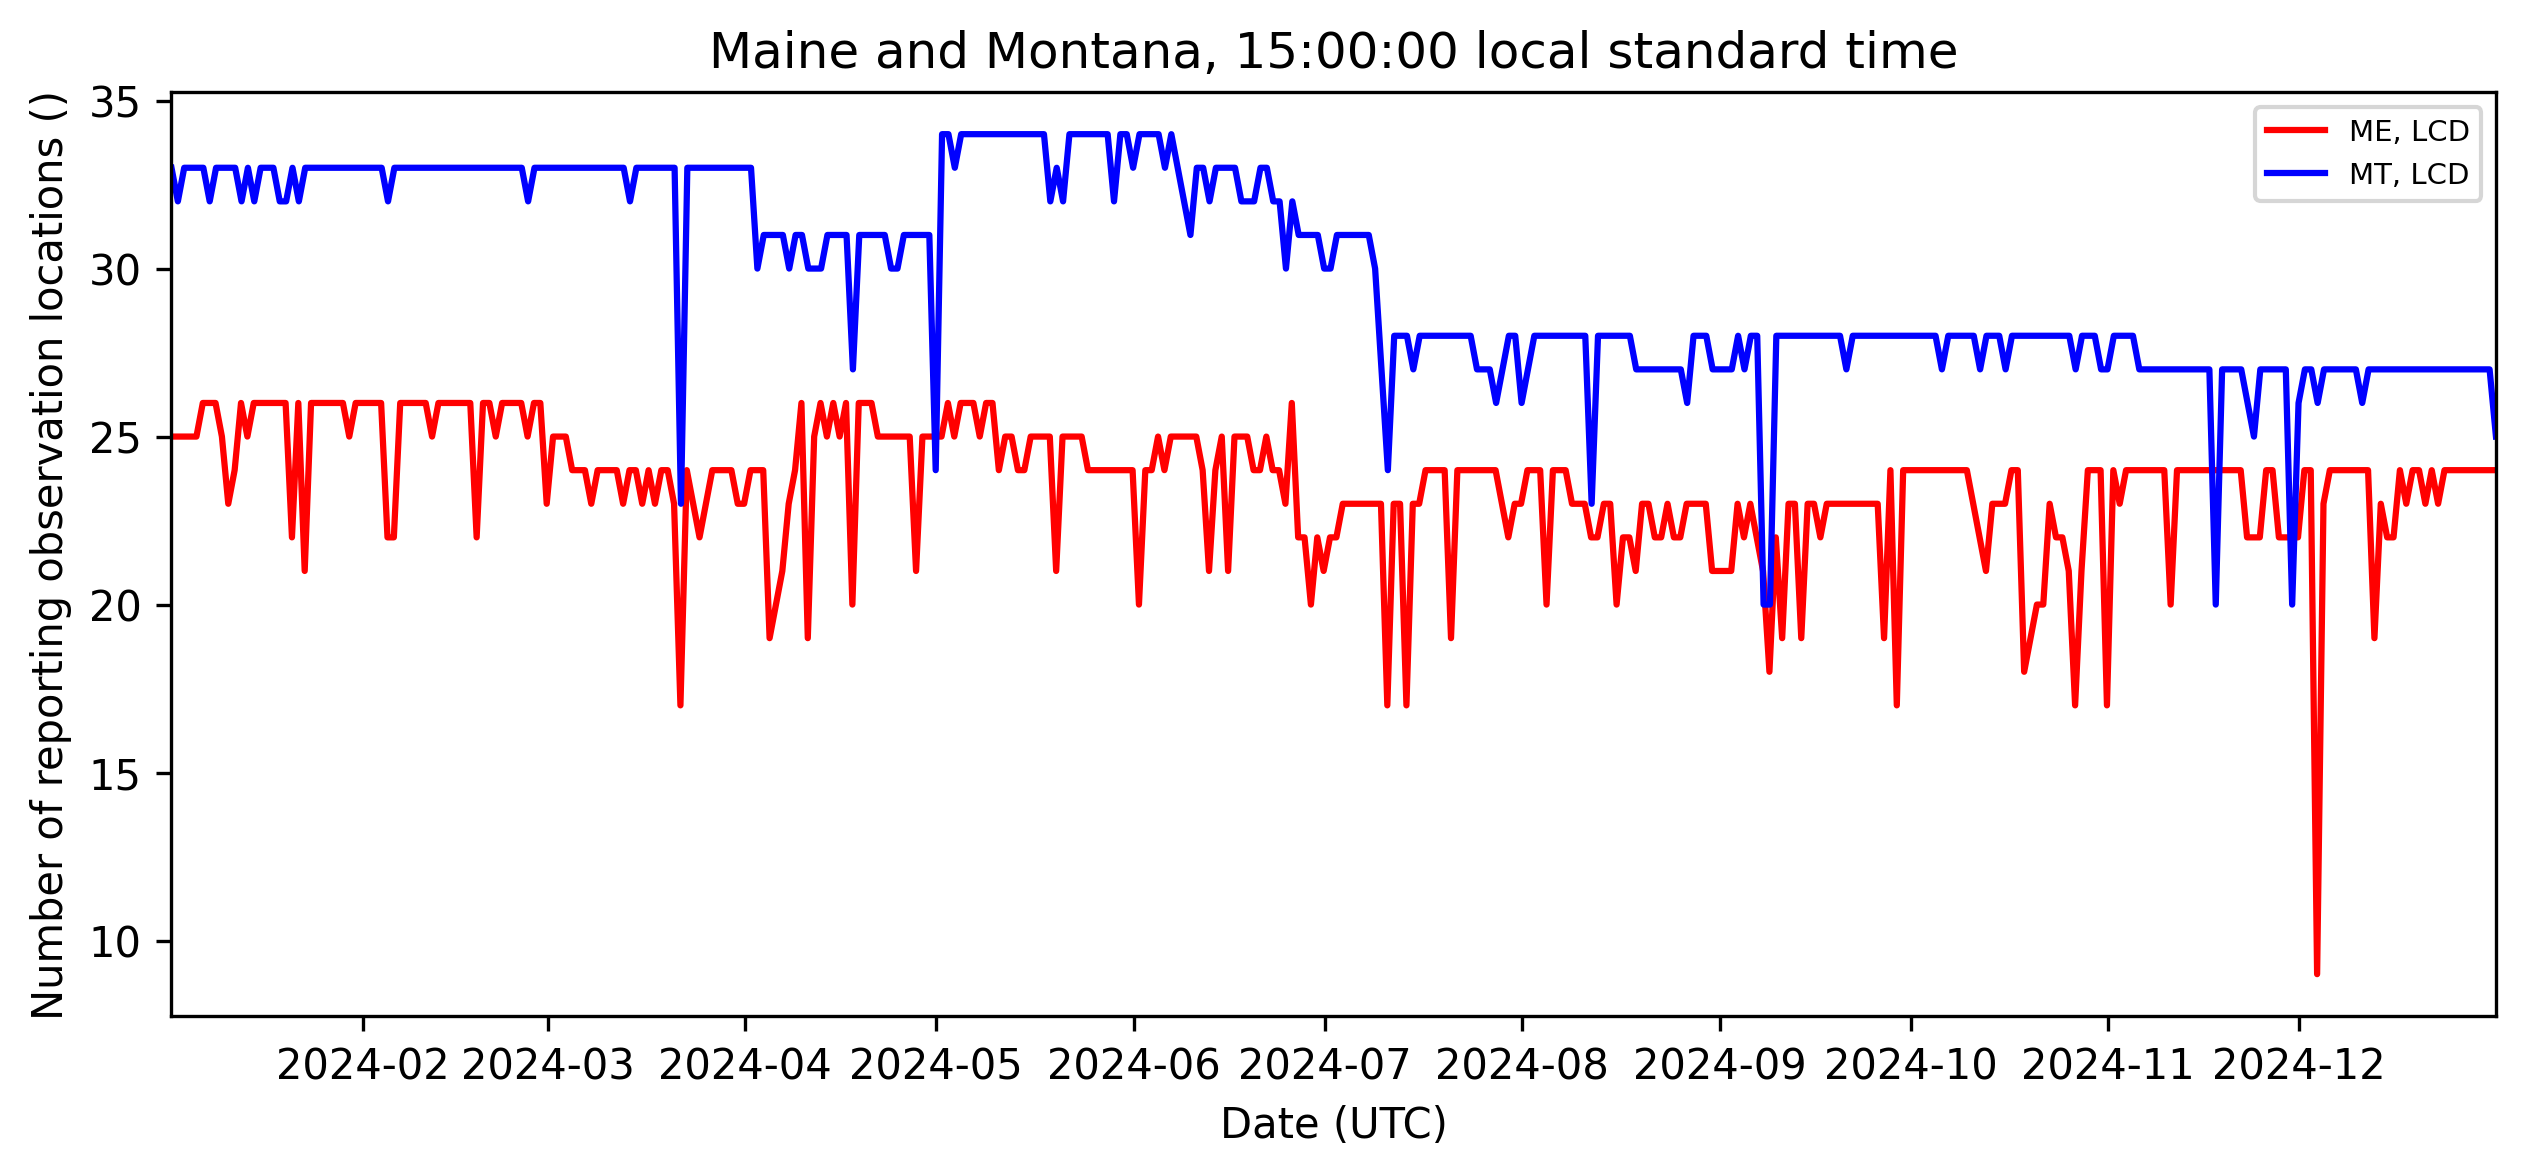

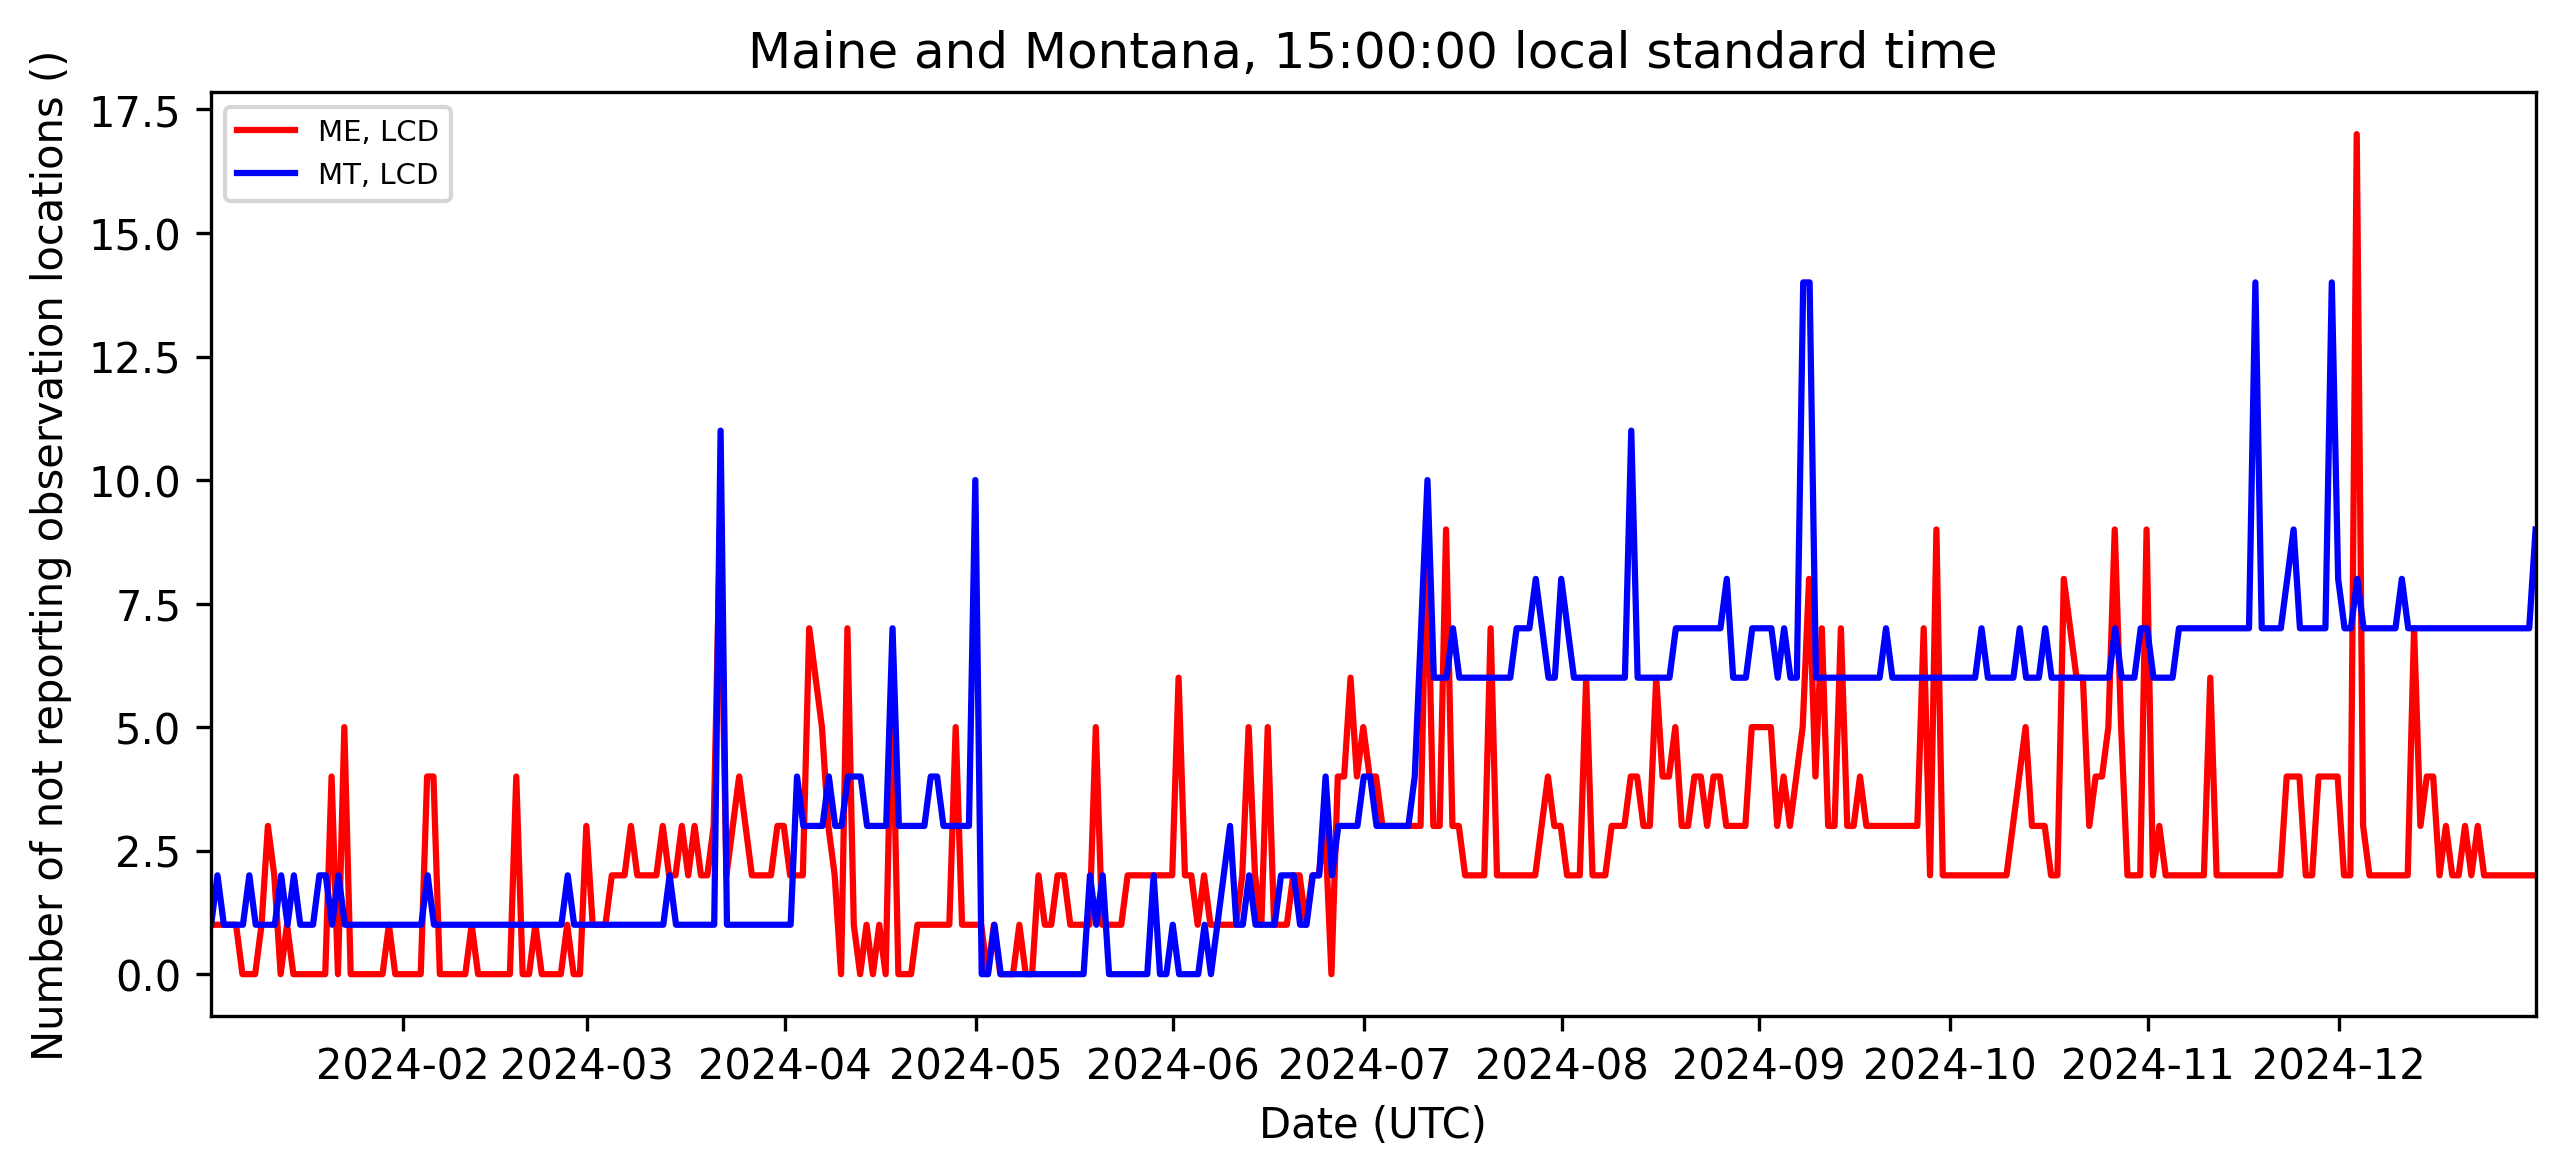

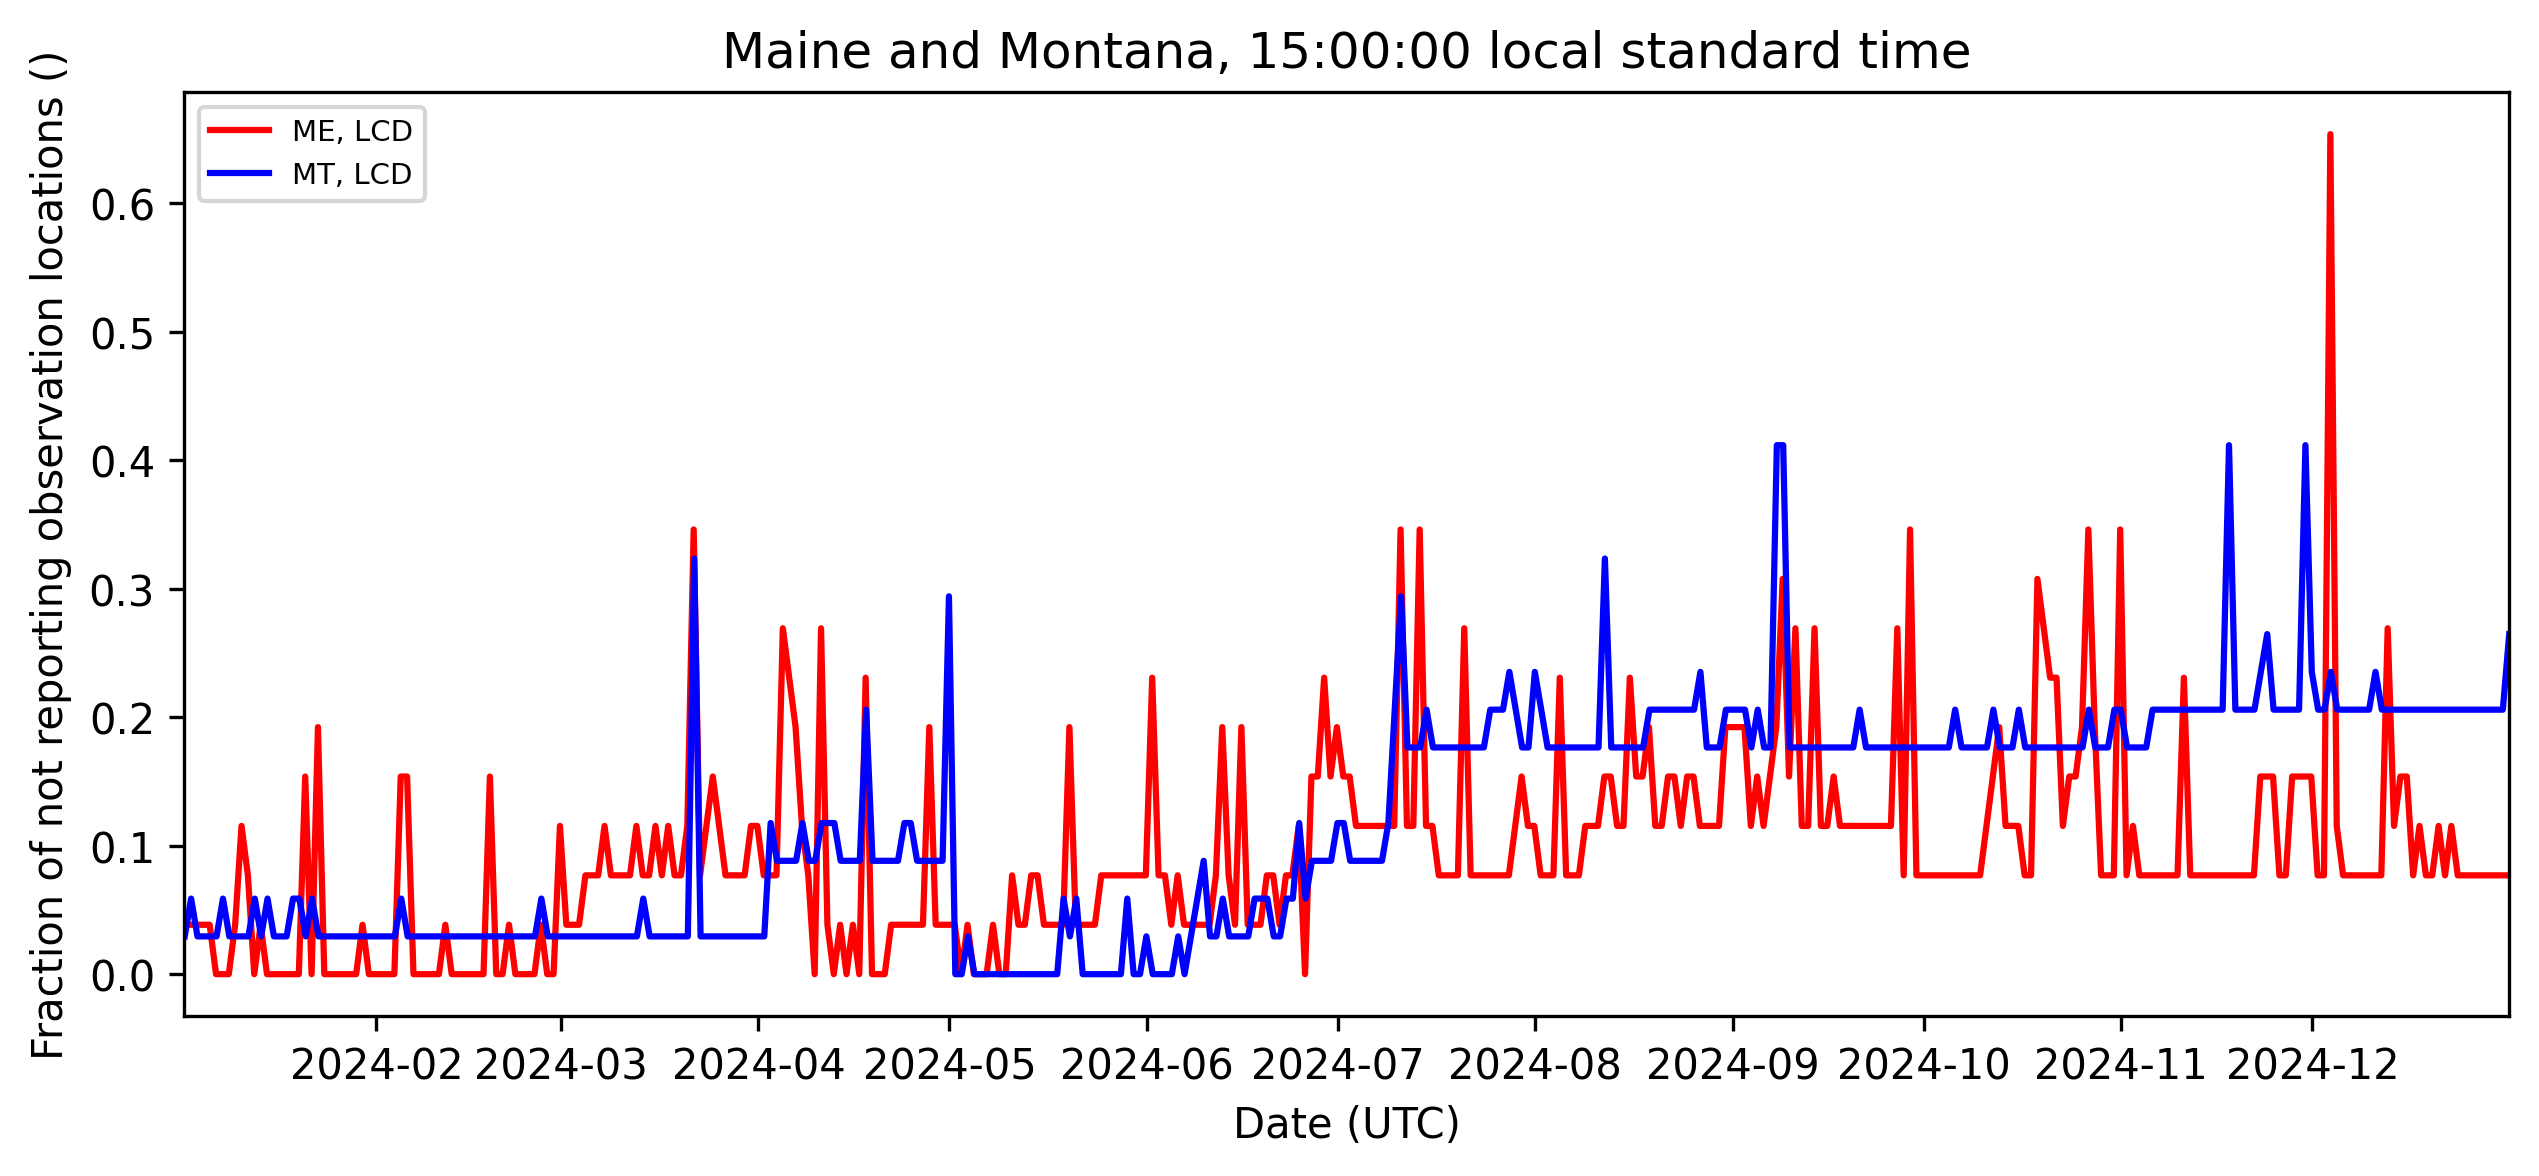

In [37]:
for plot in time_series_plots:
    display(Image(filename=plot))

### Probability density plots

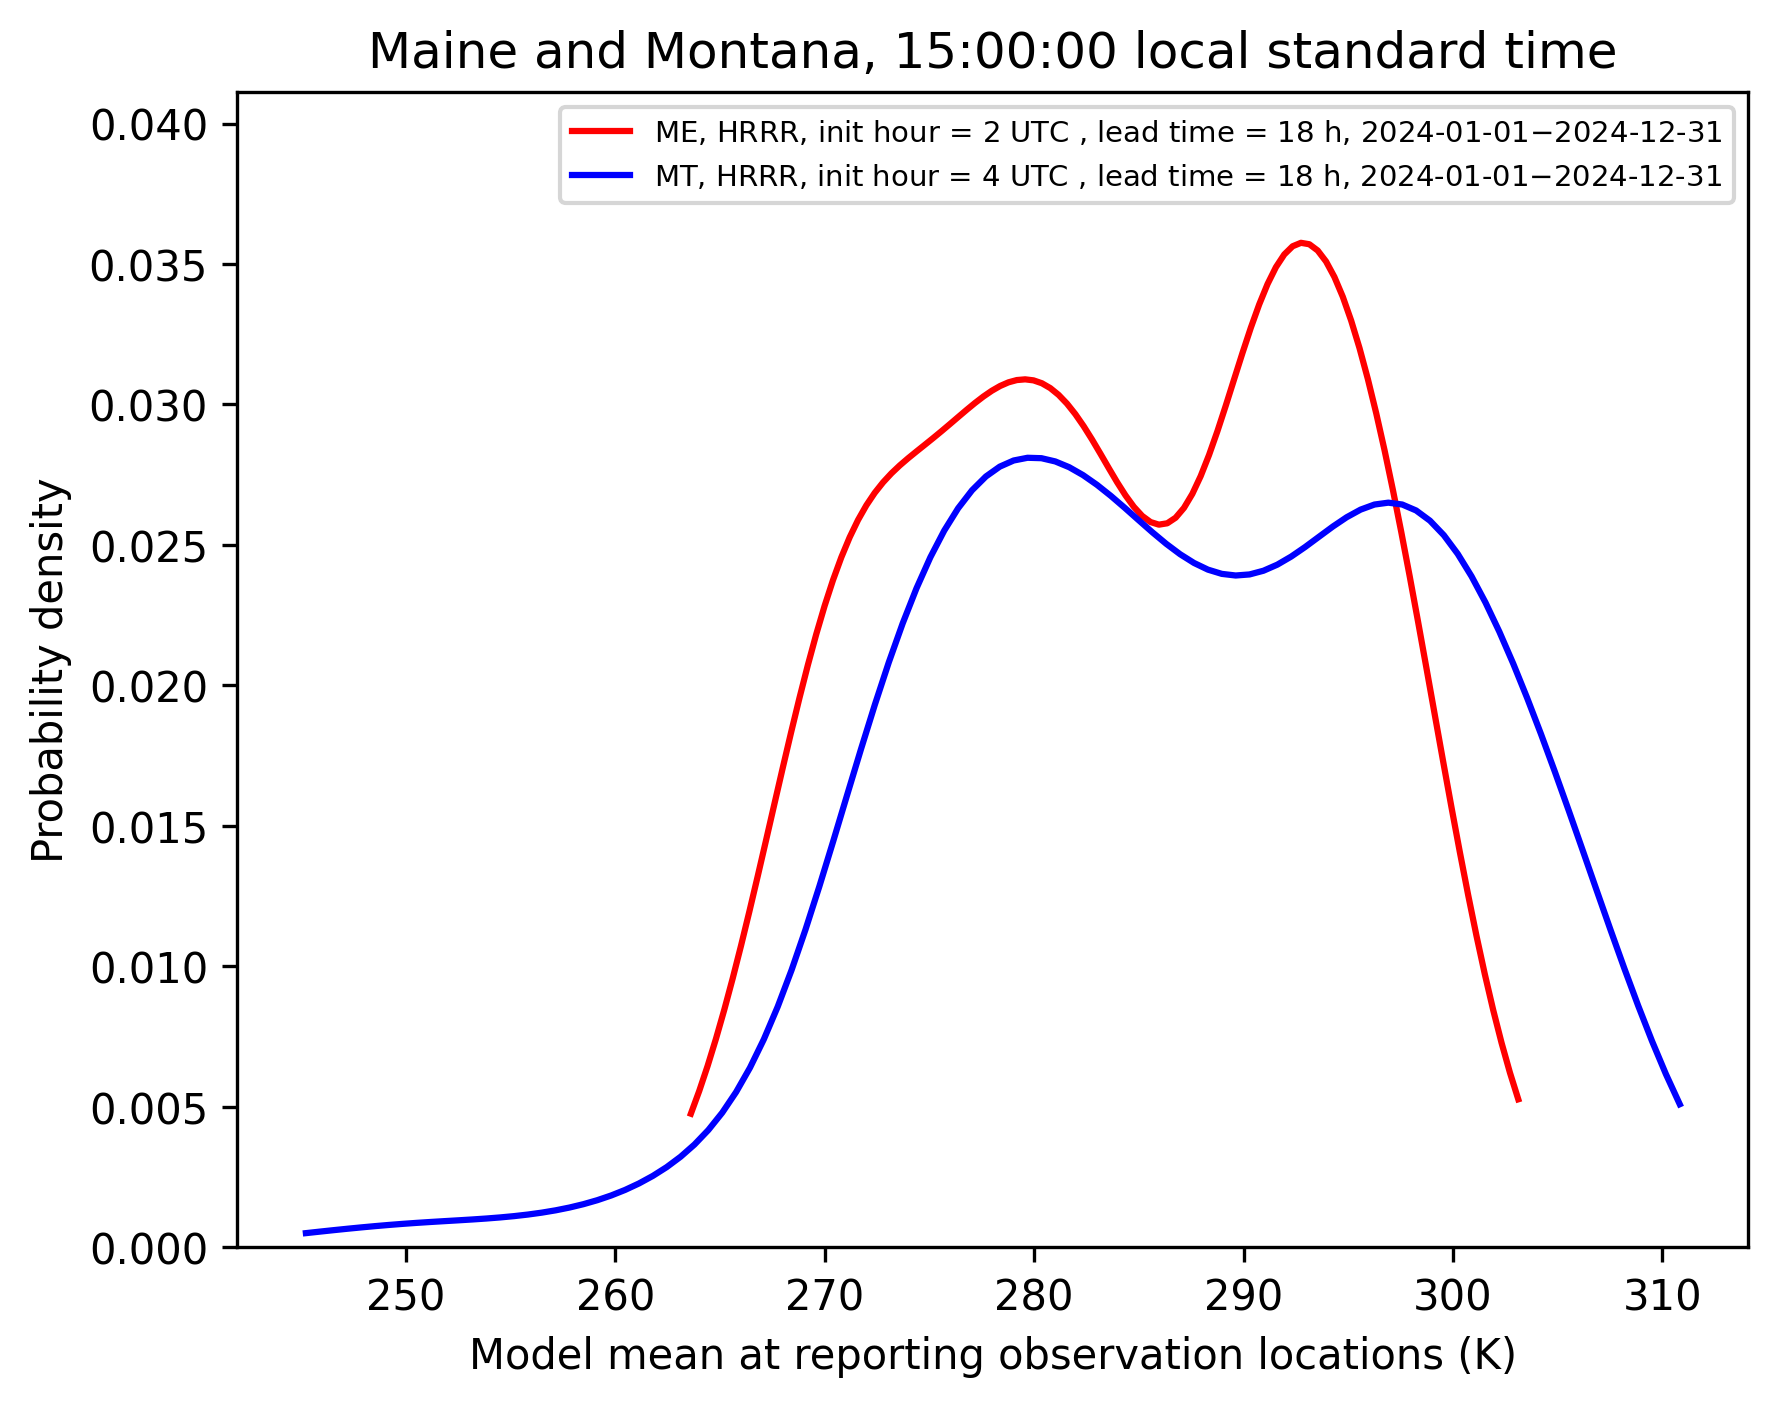

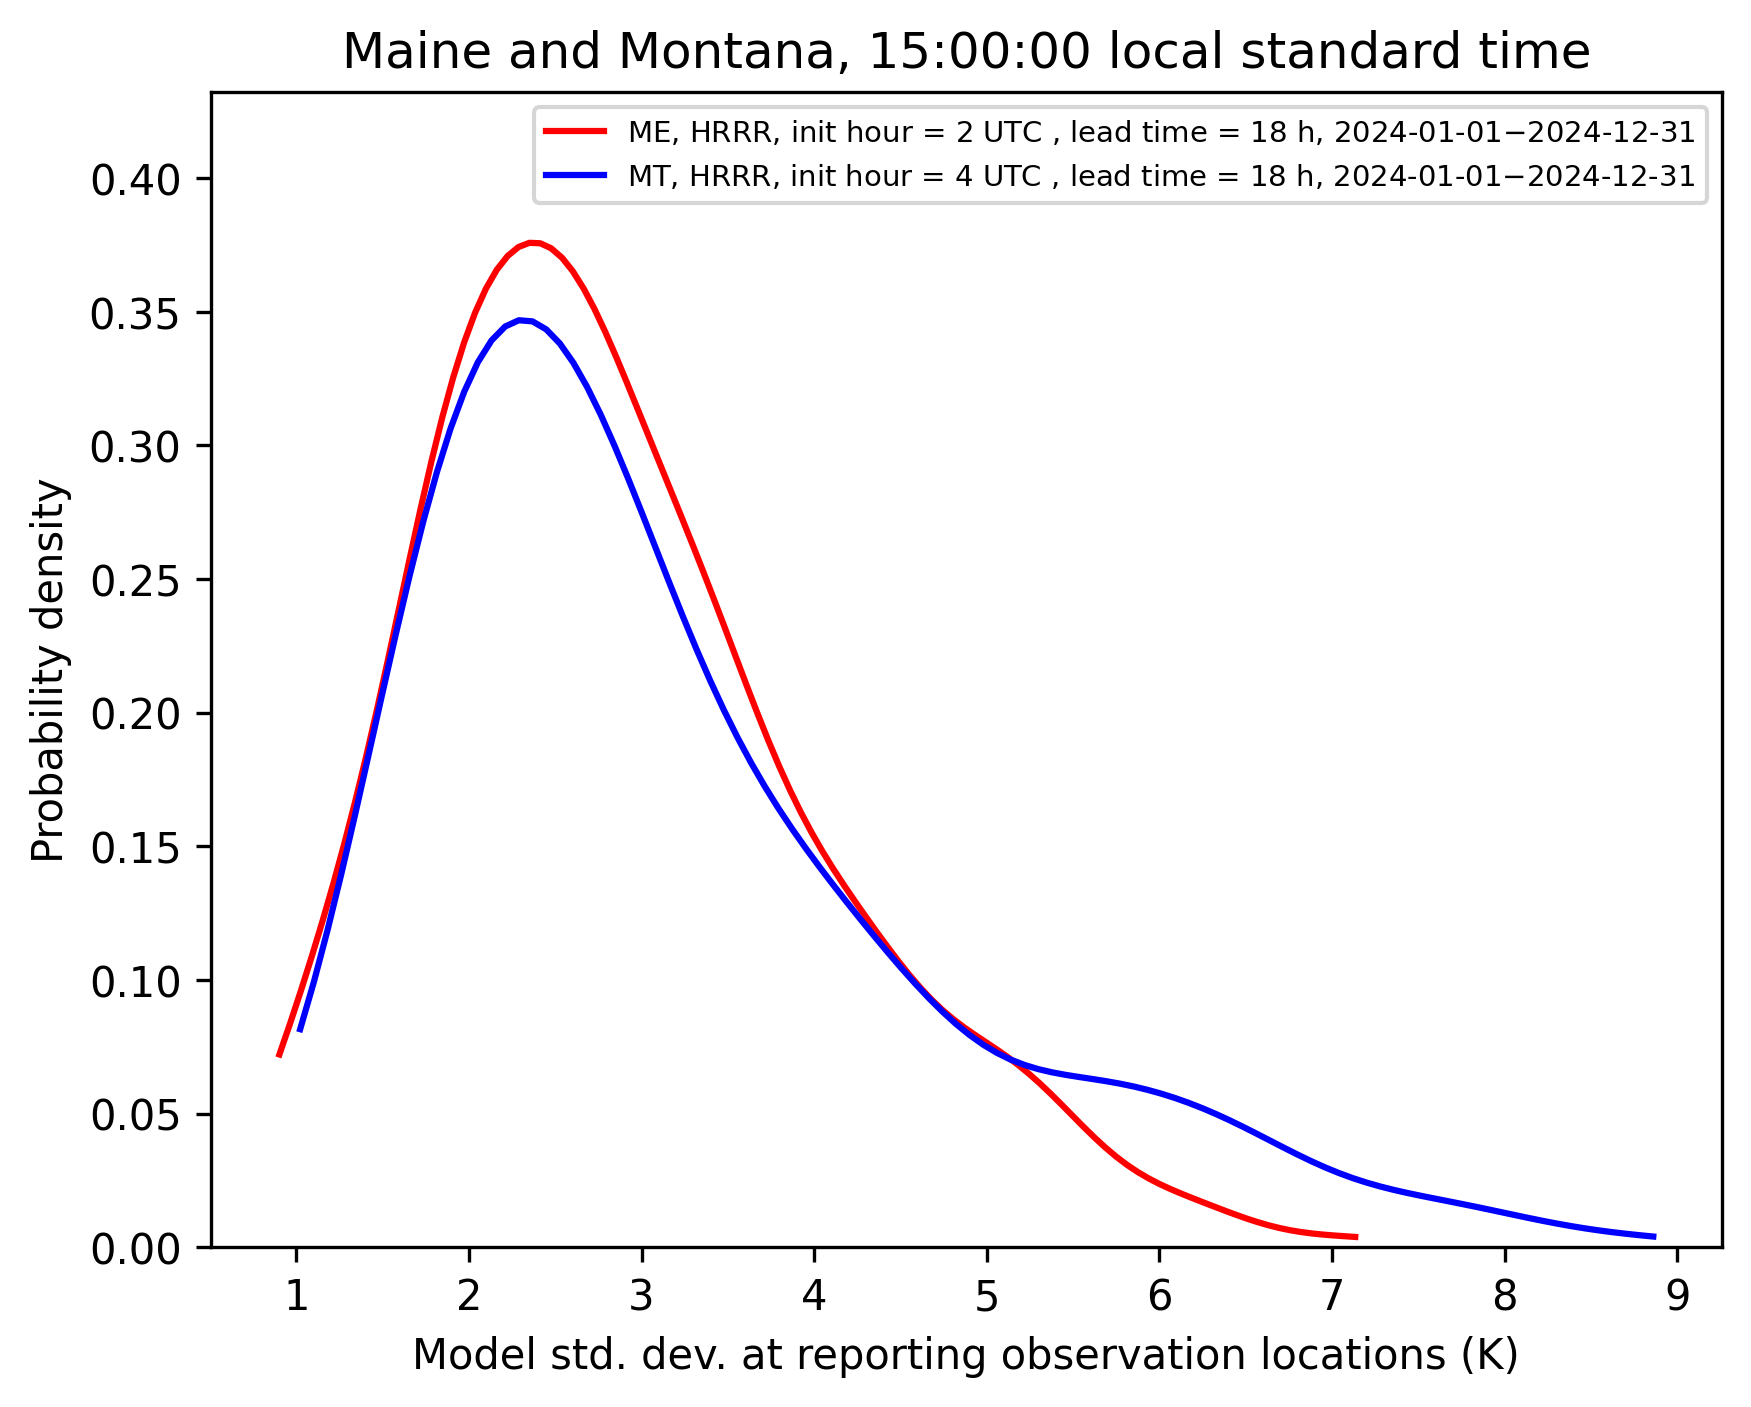

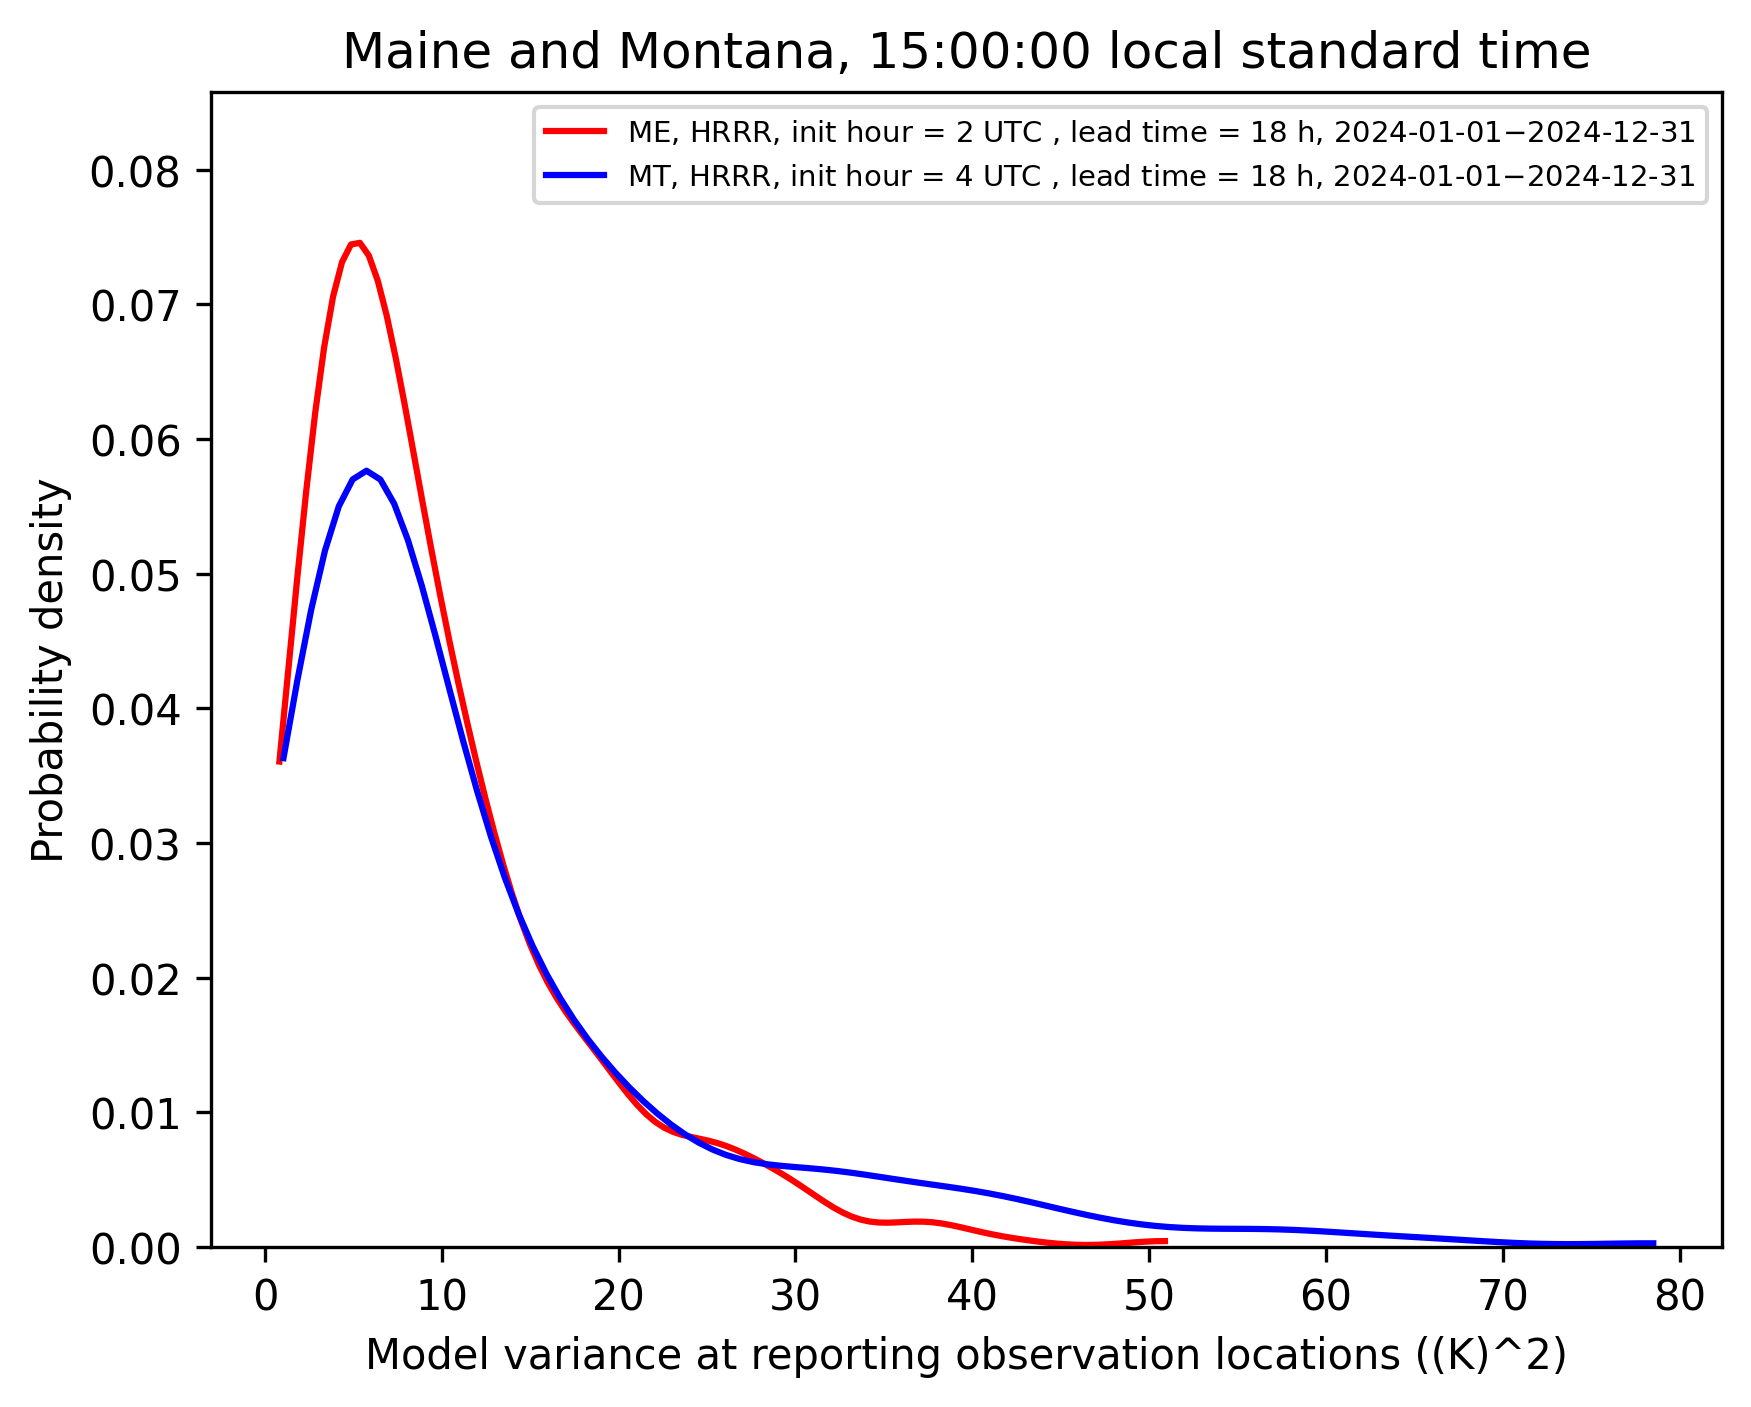

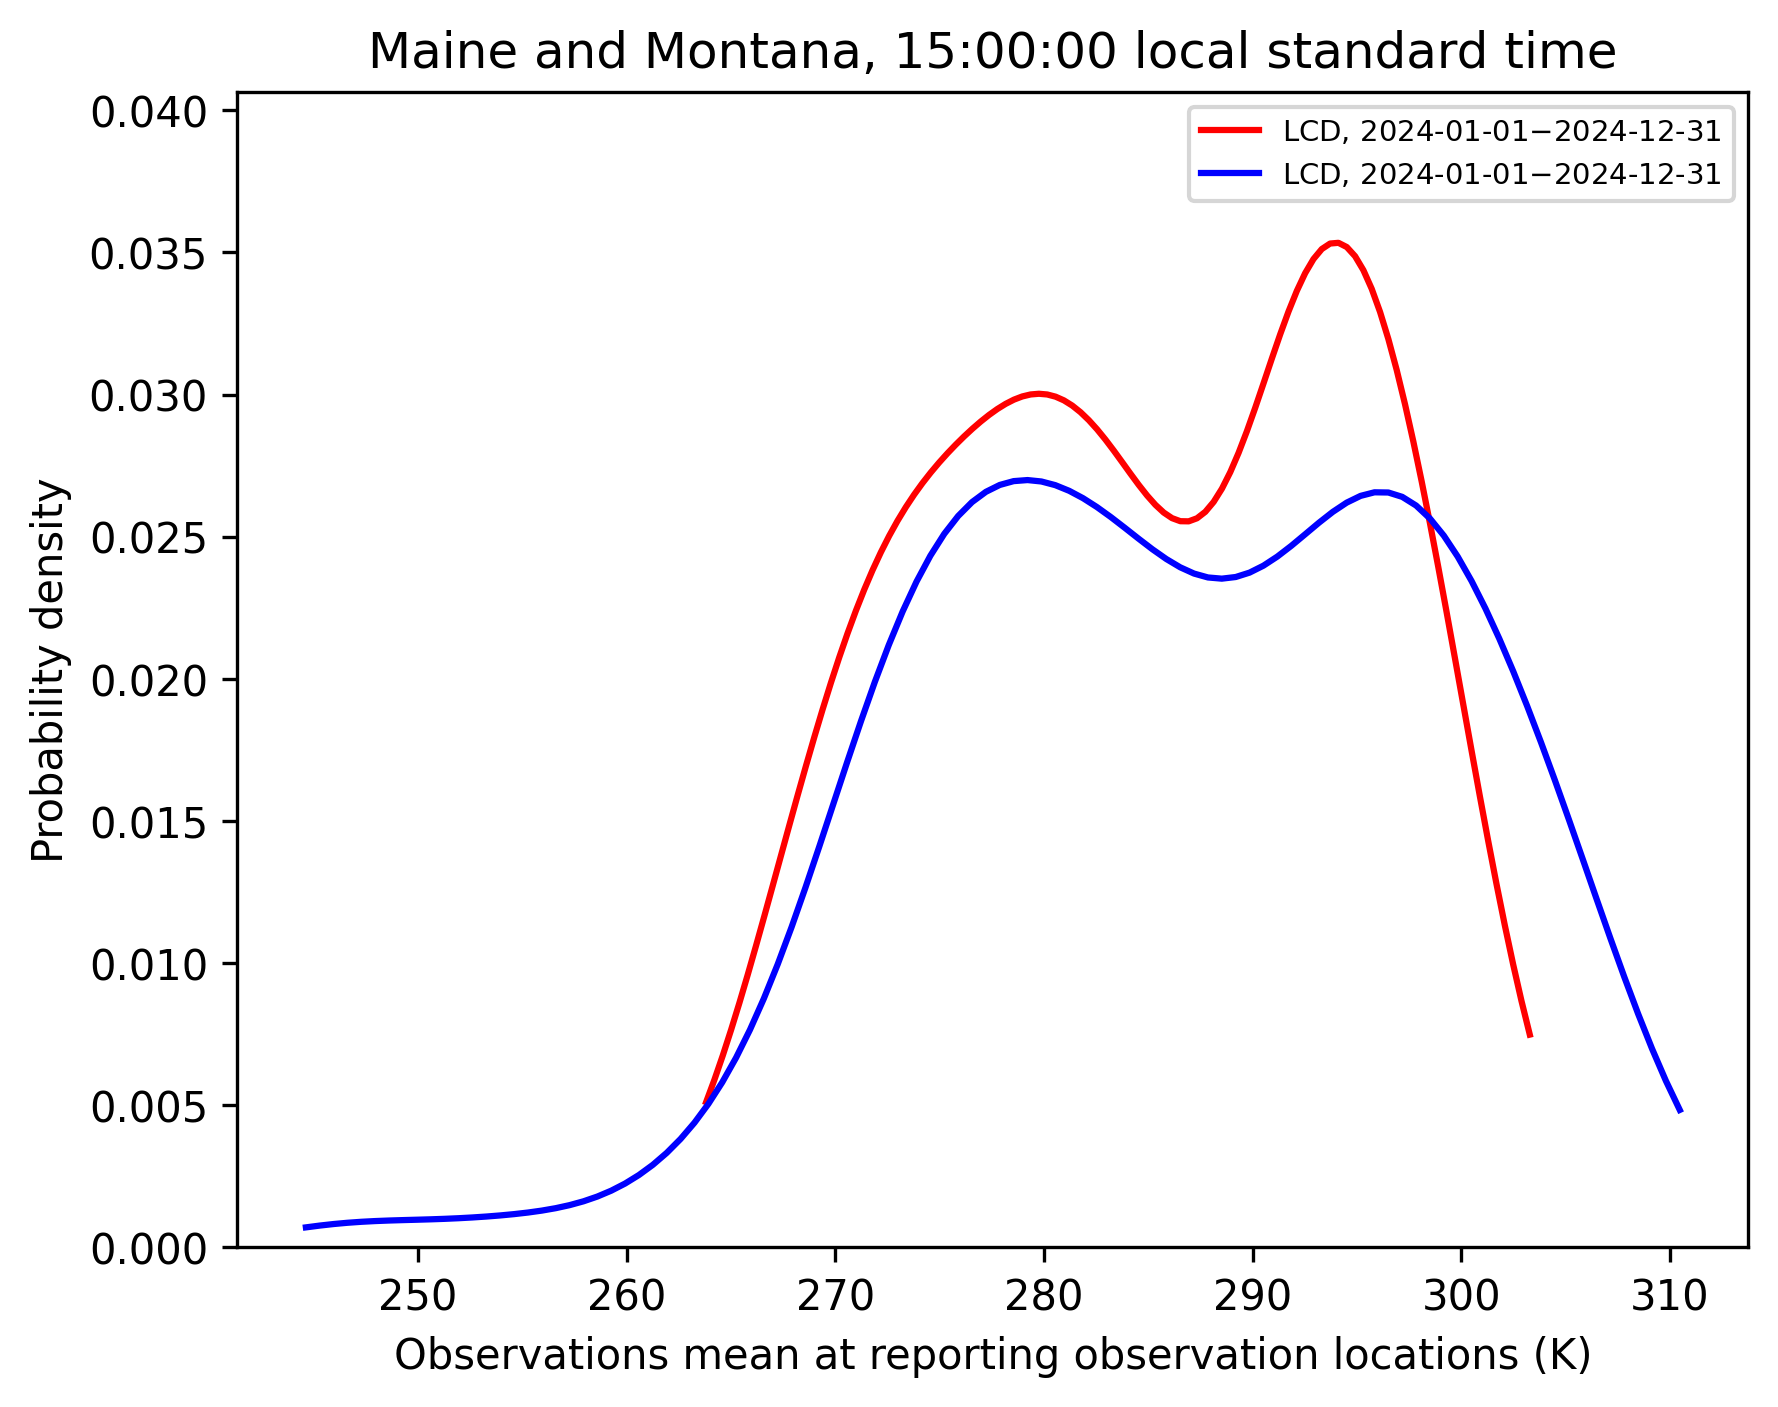

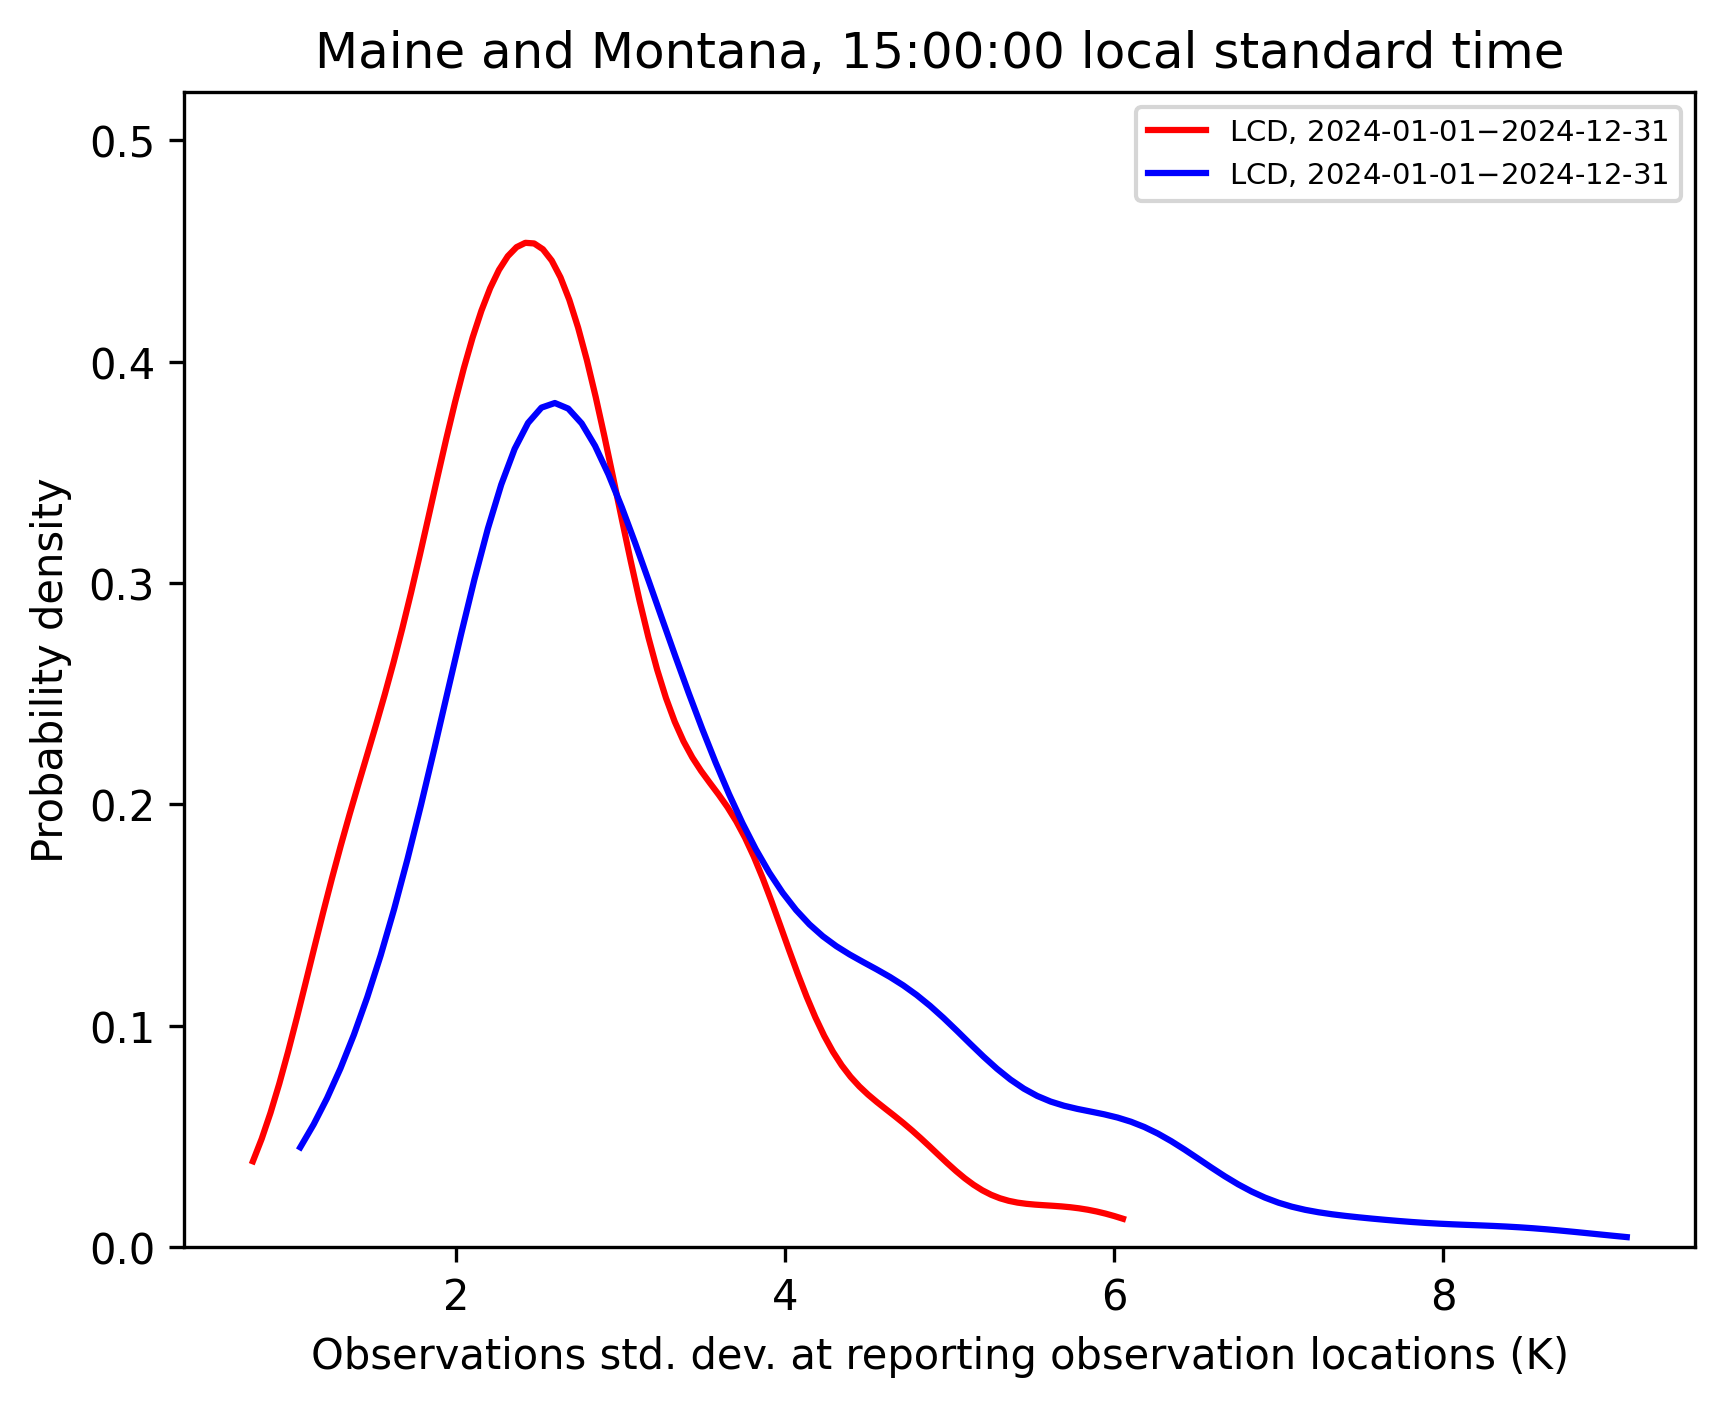

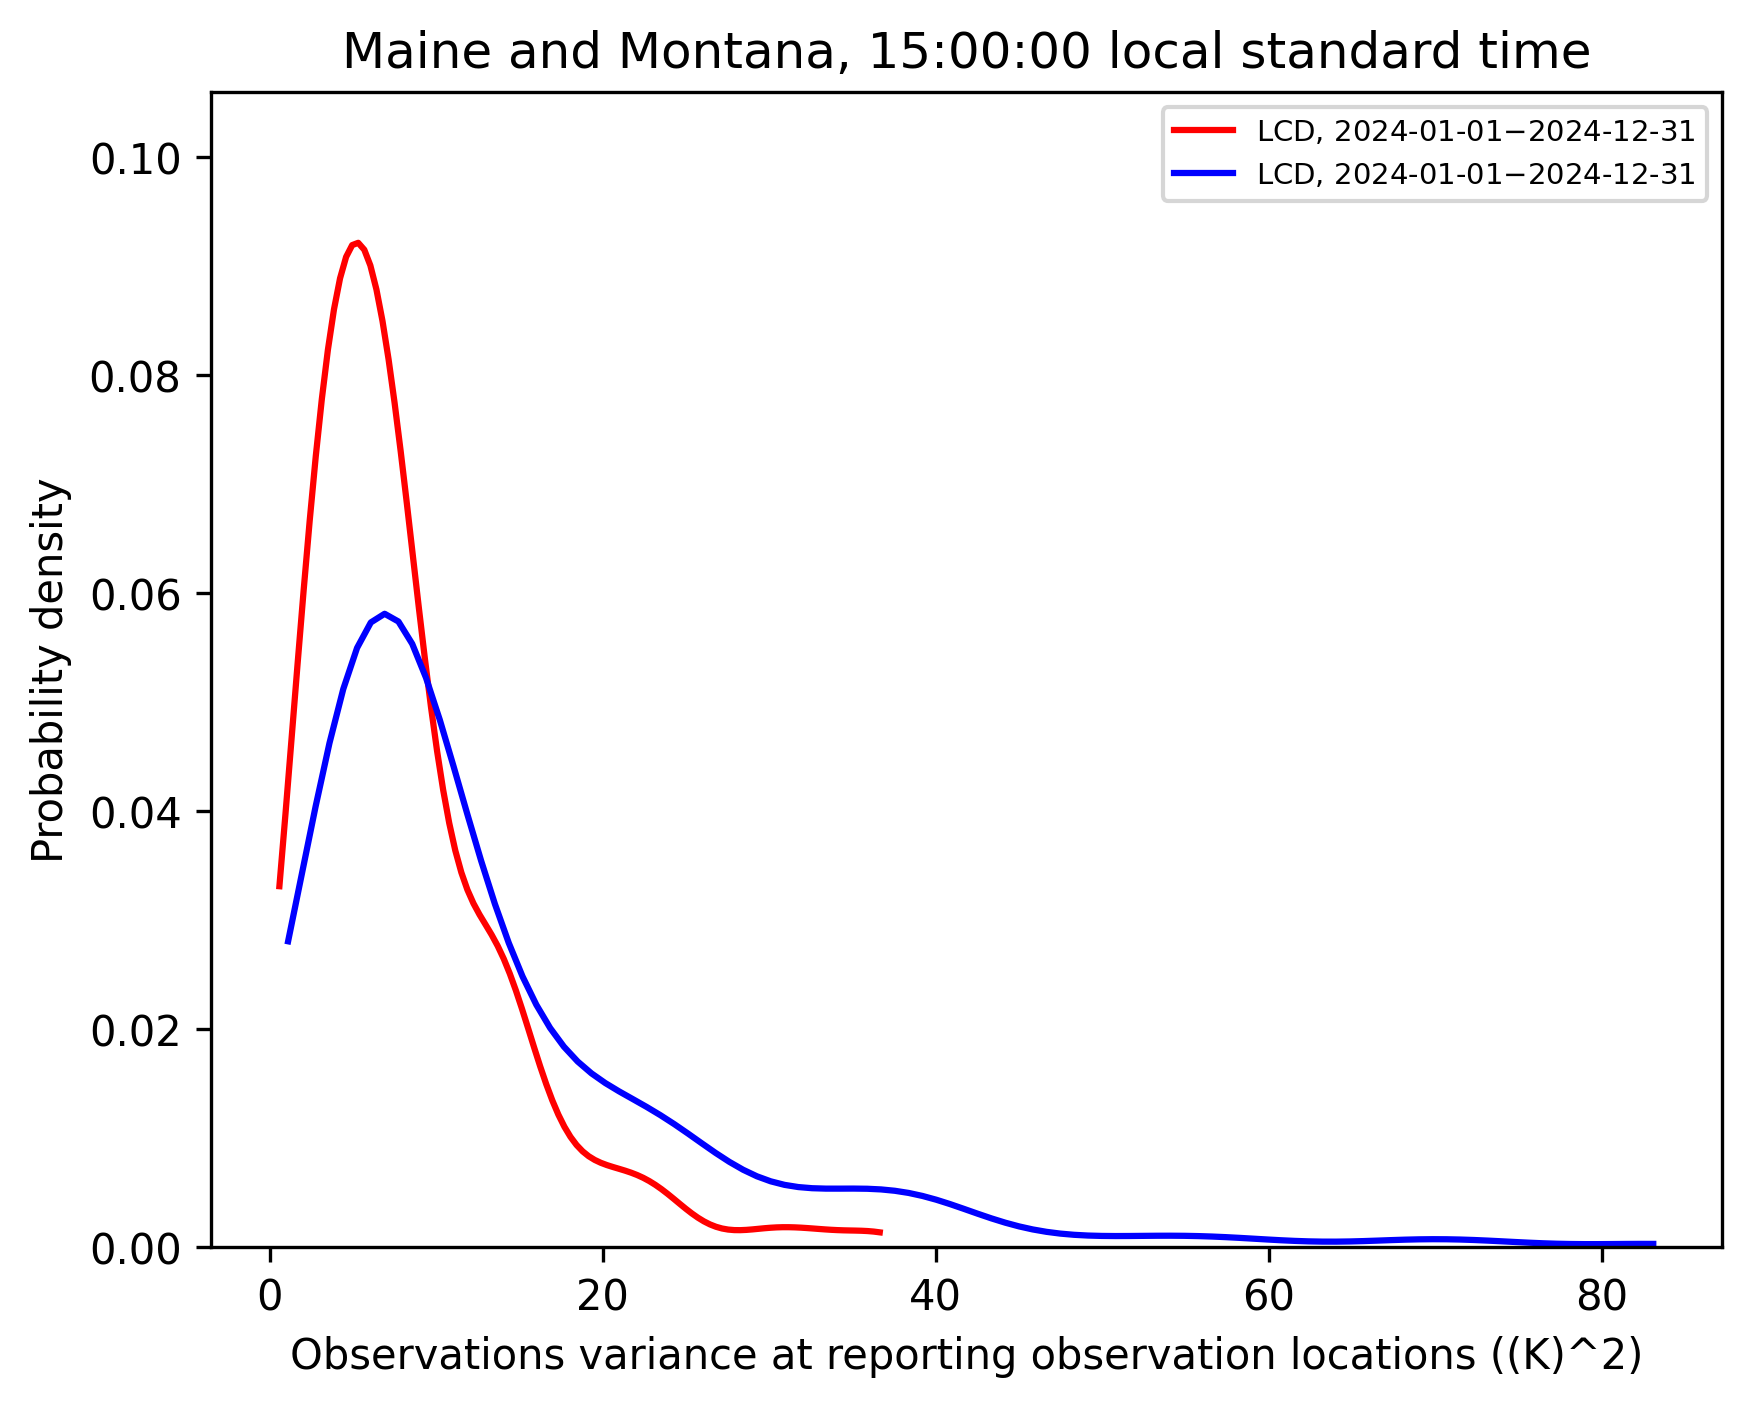

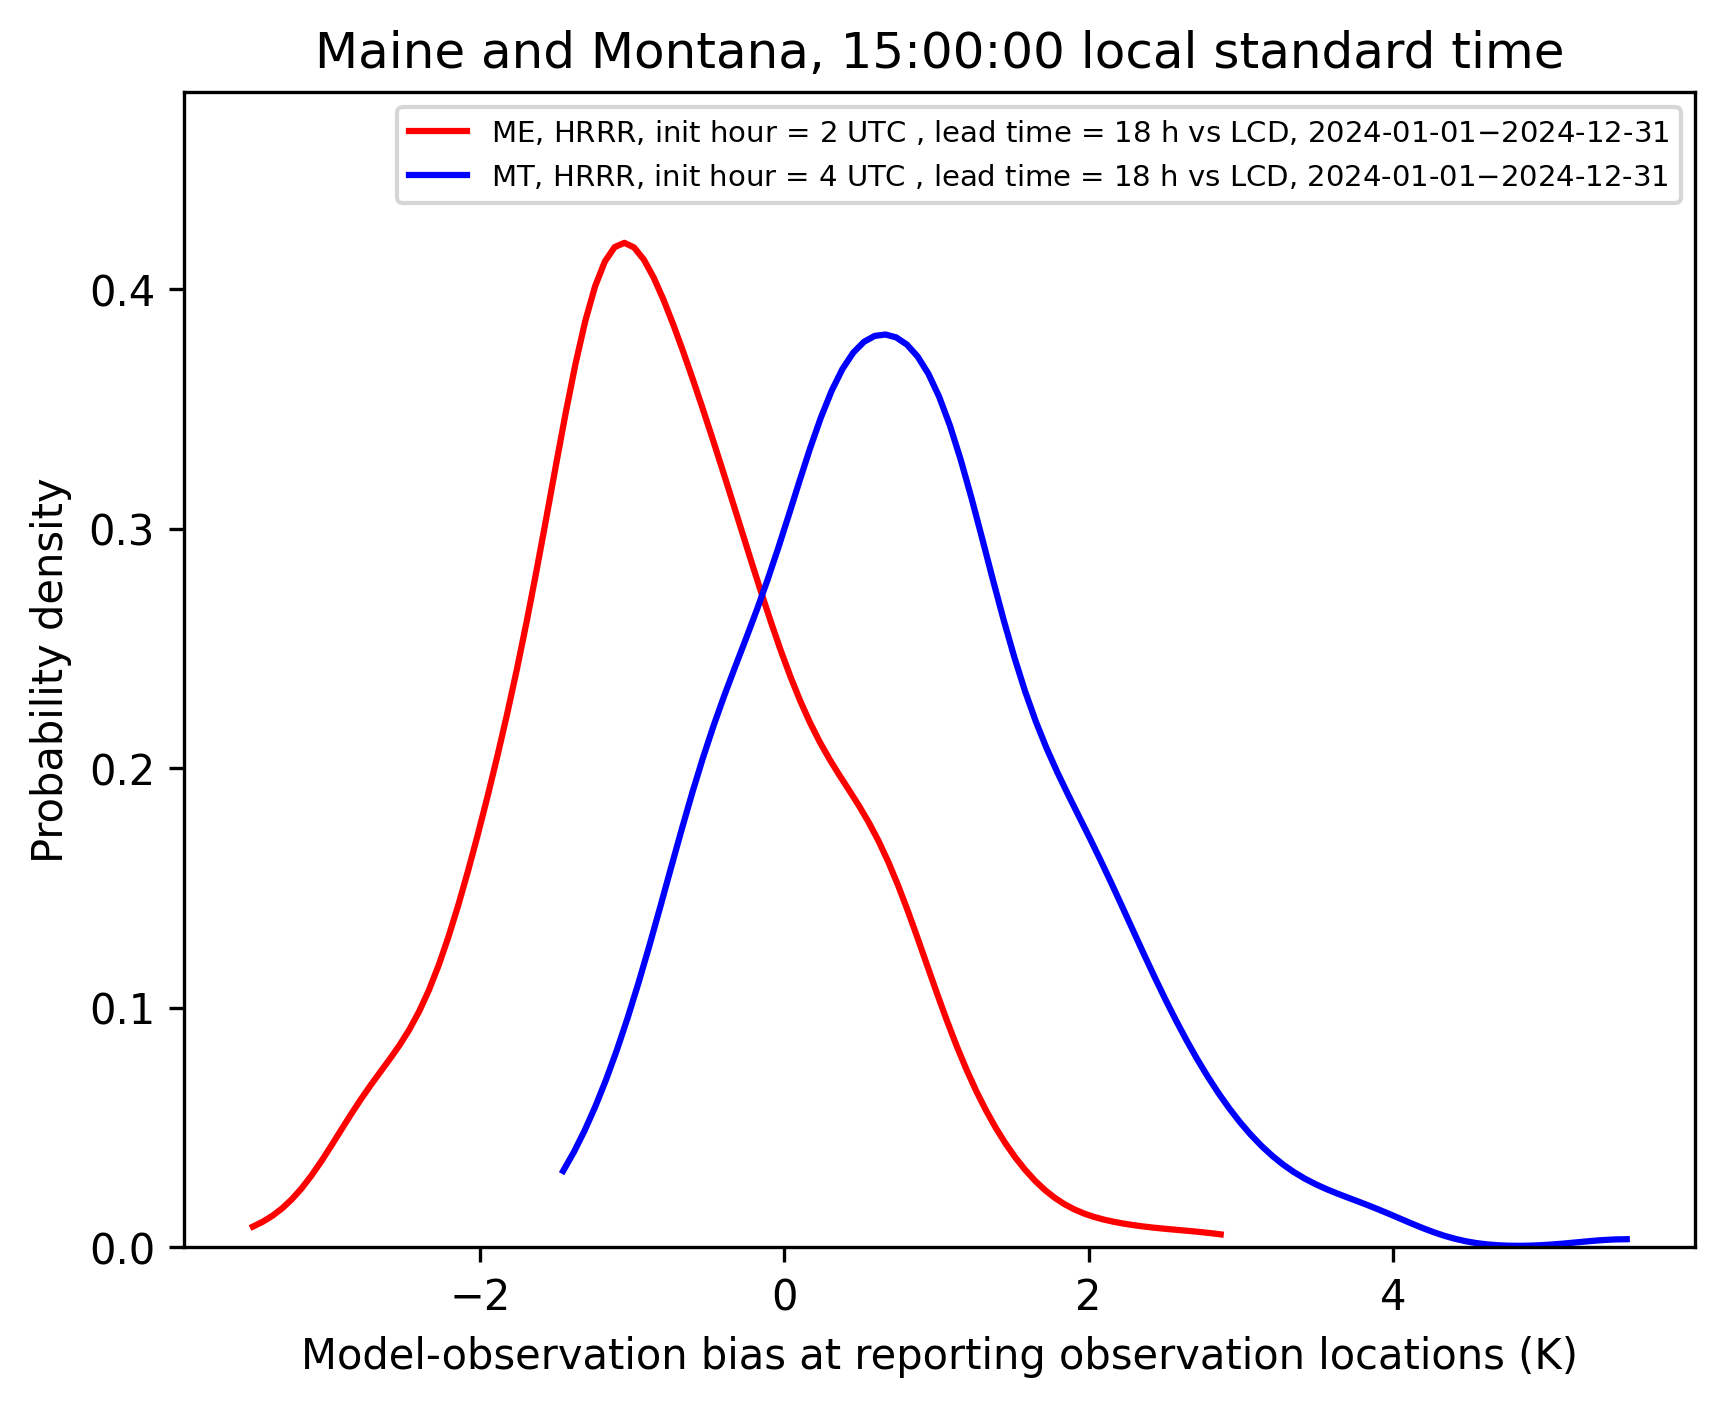

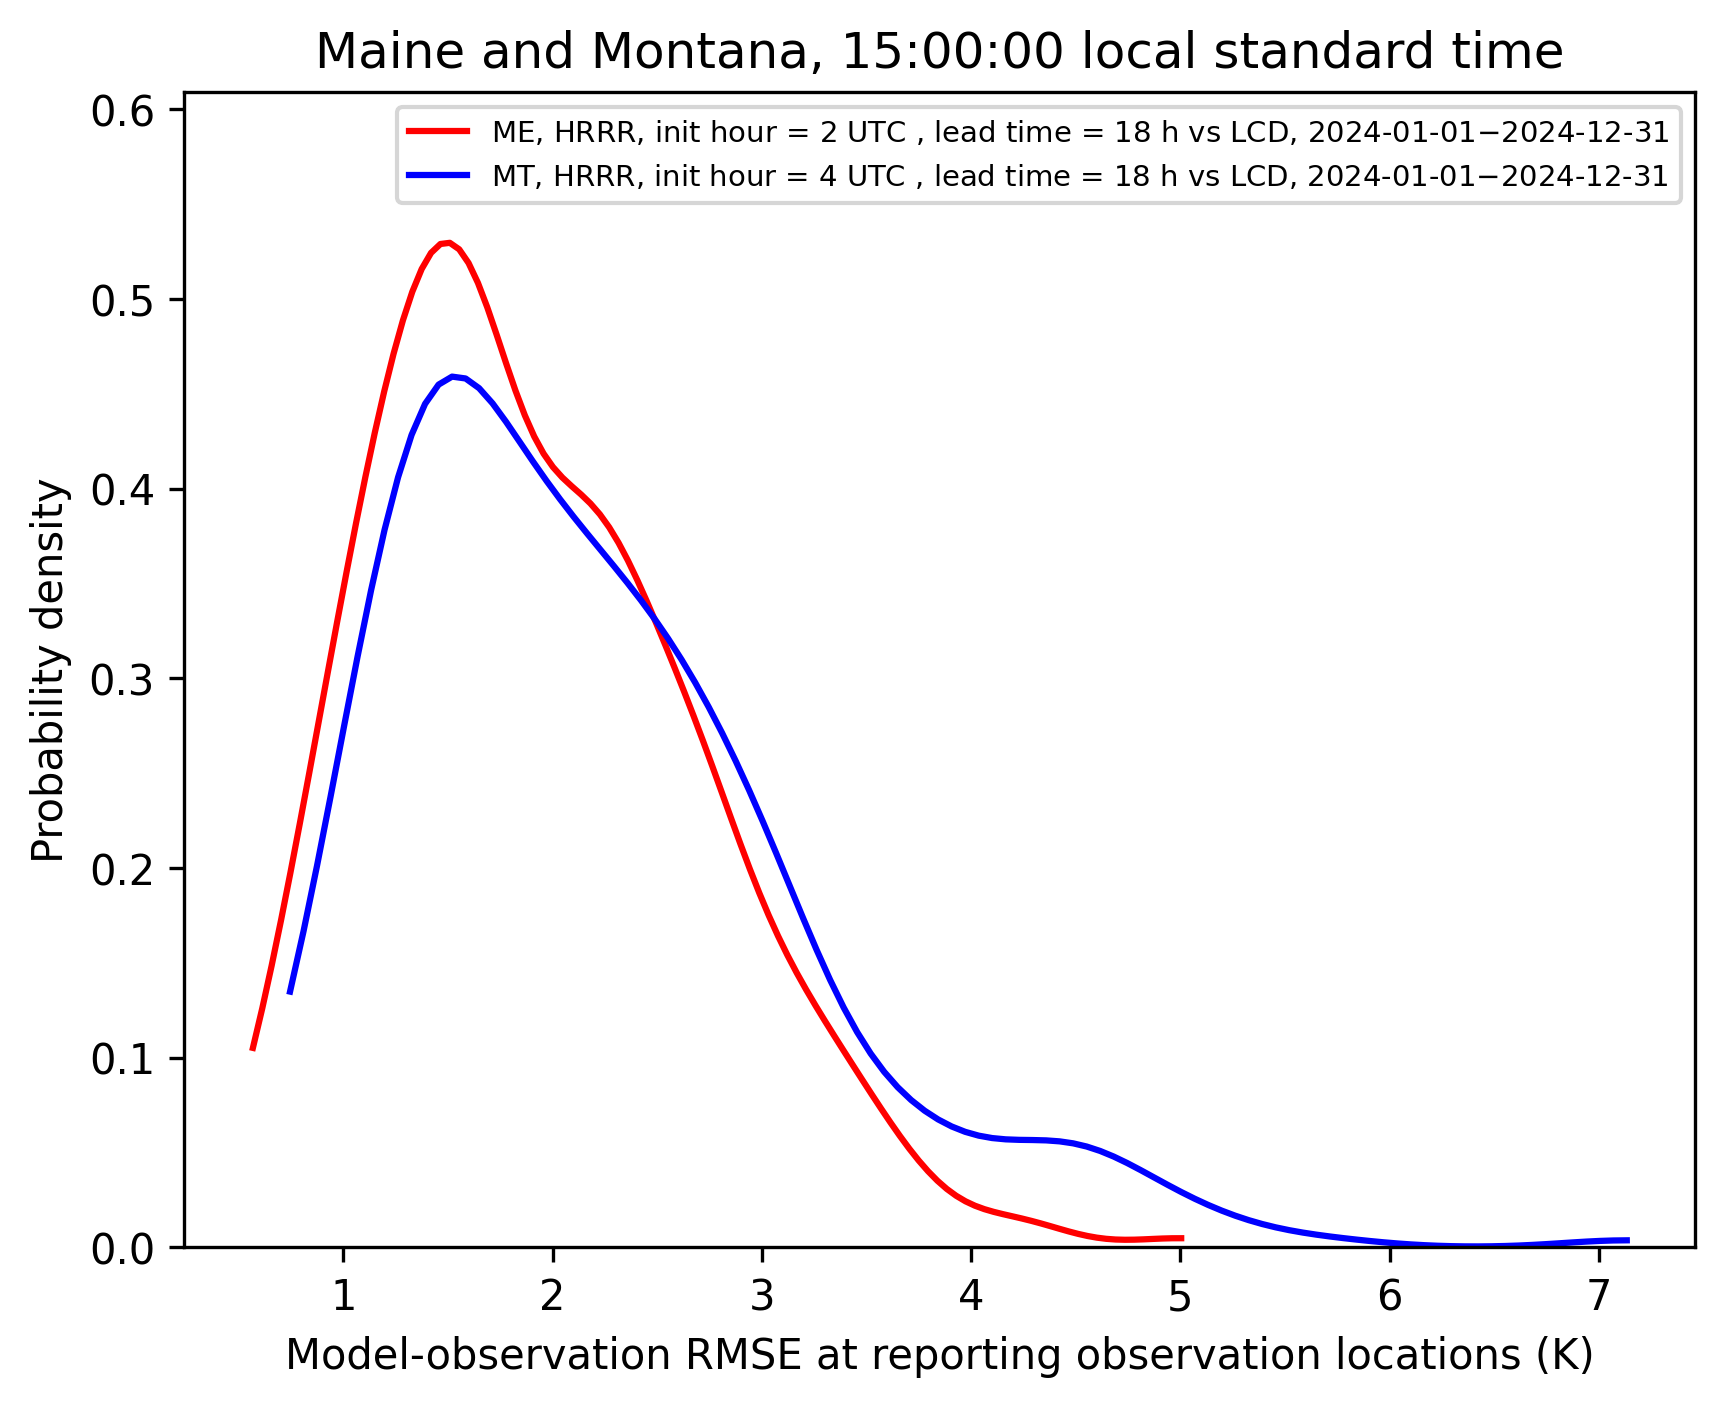

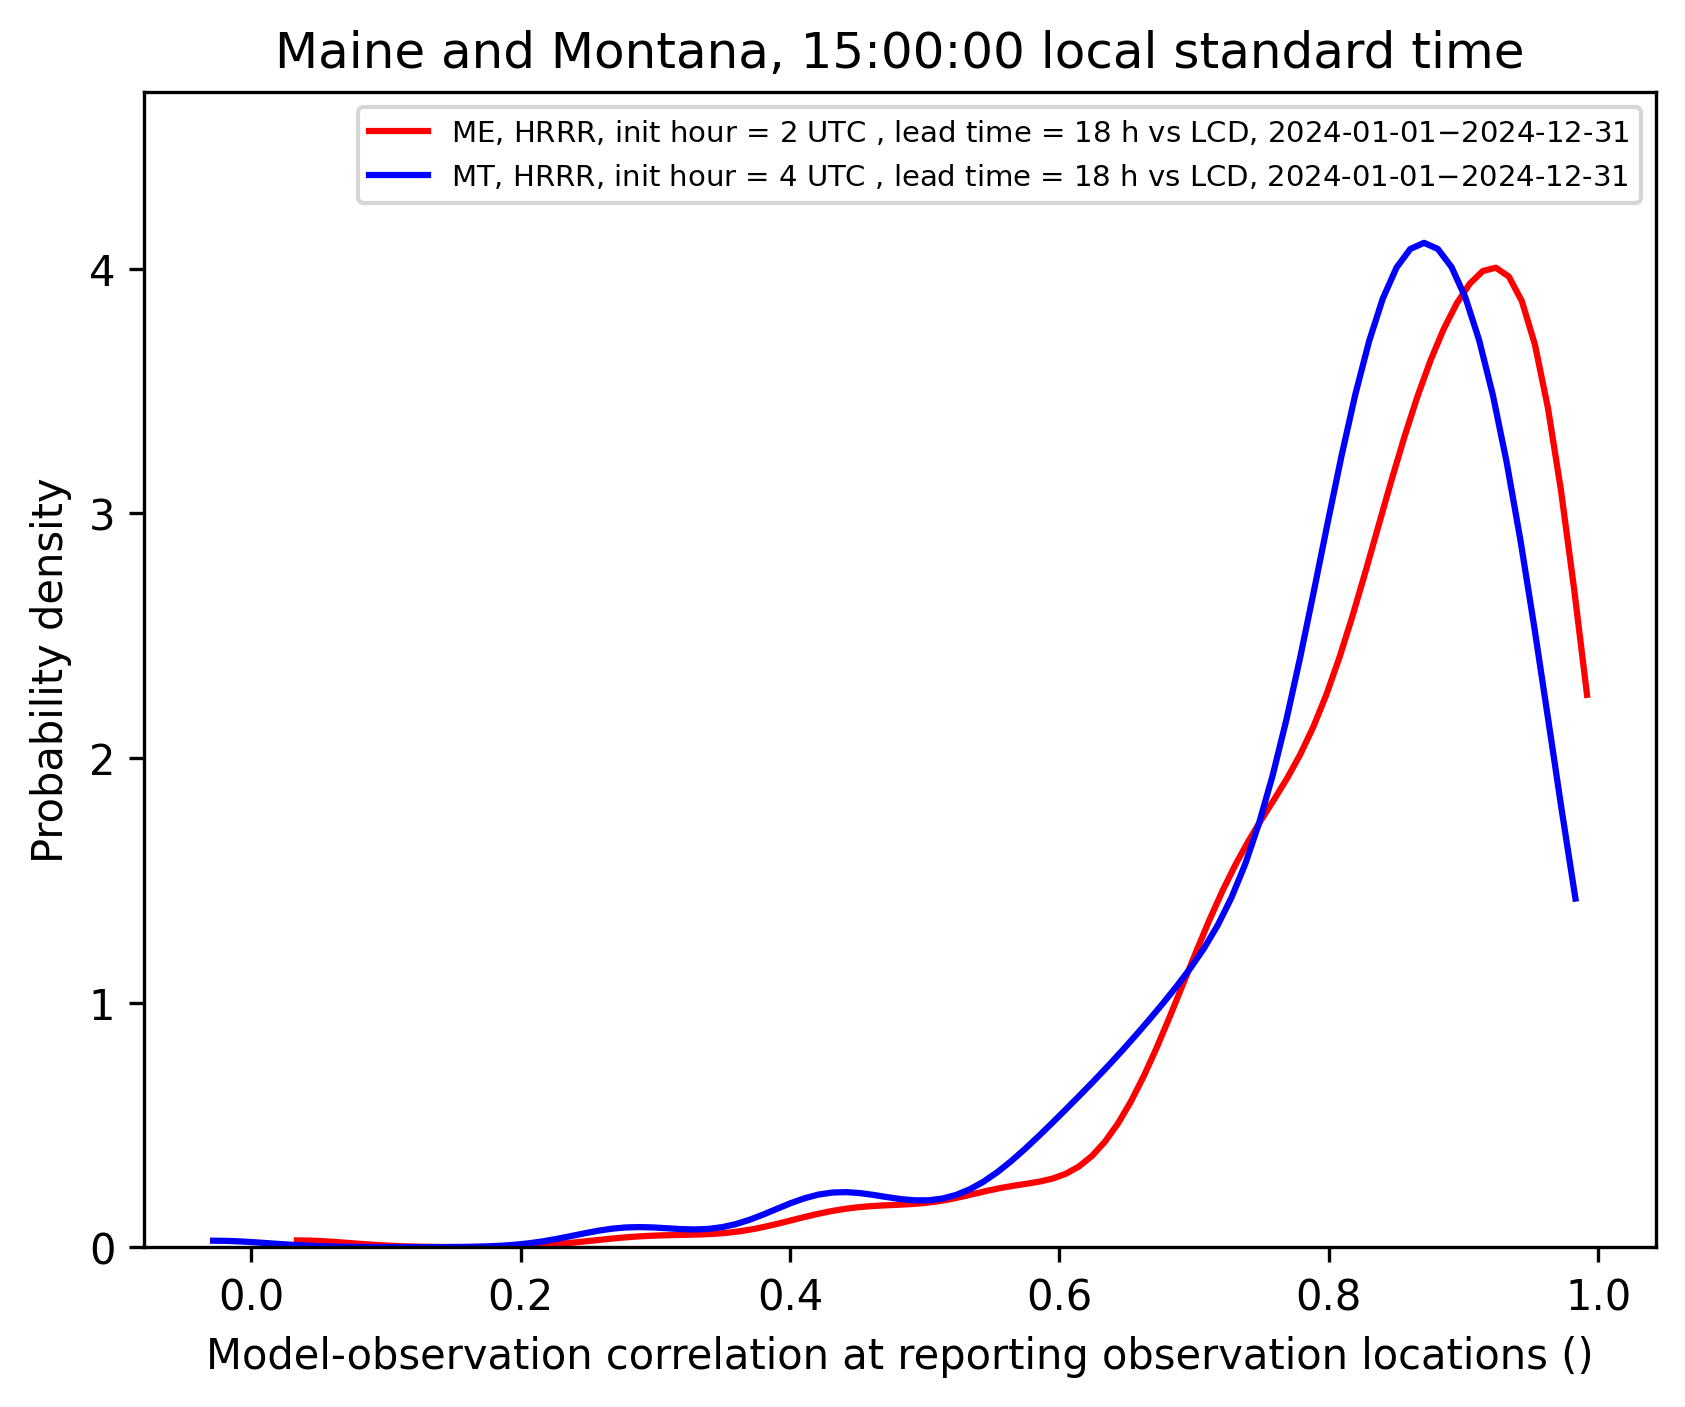

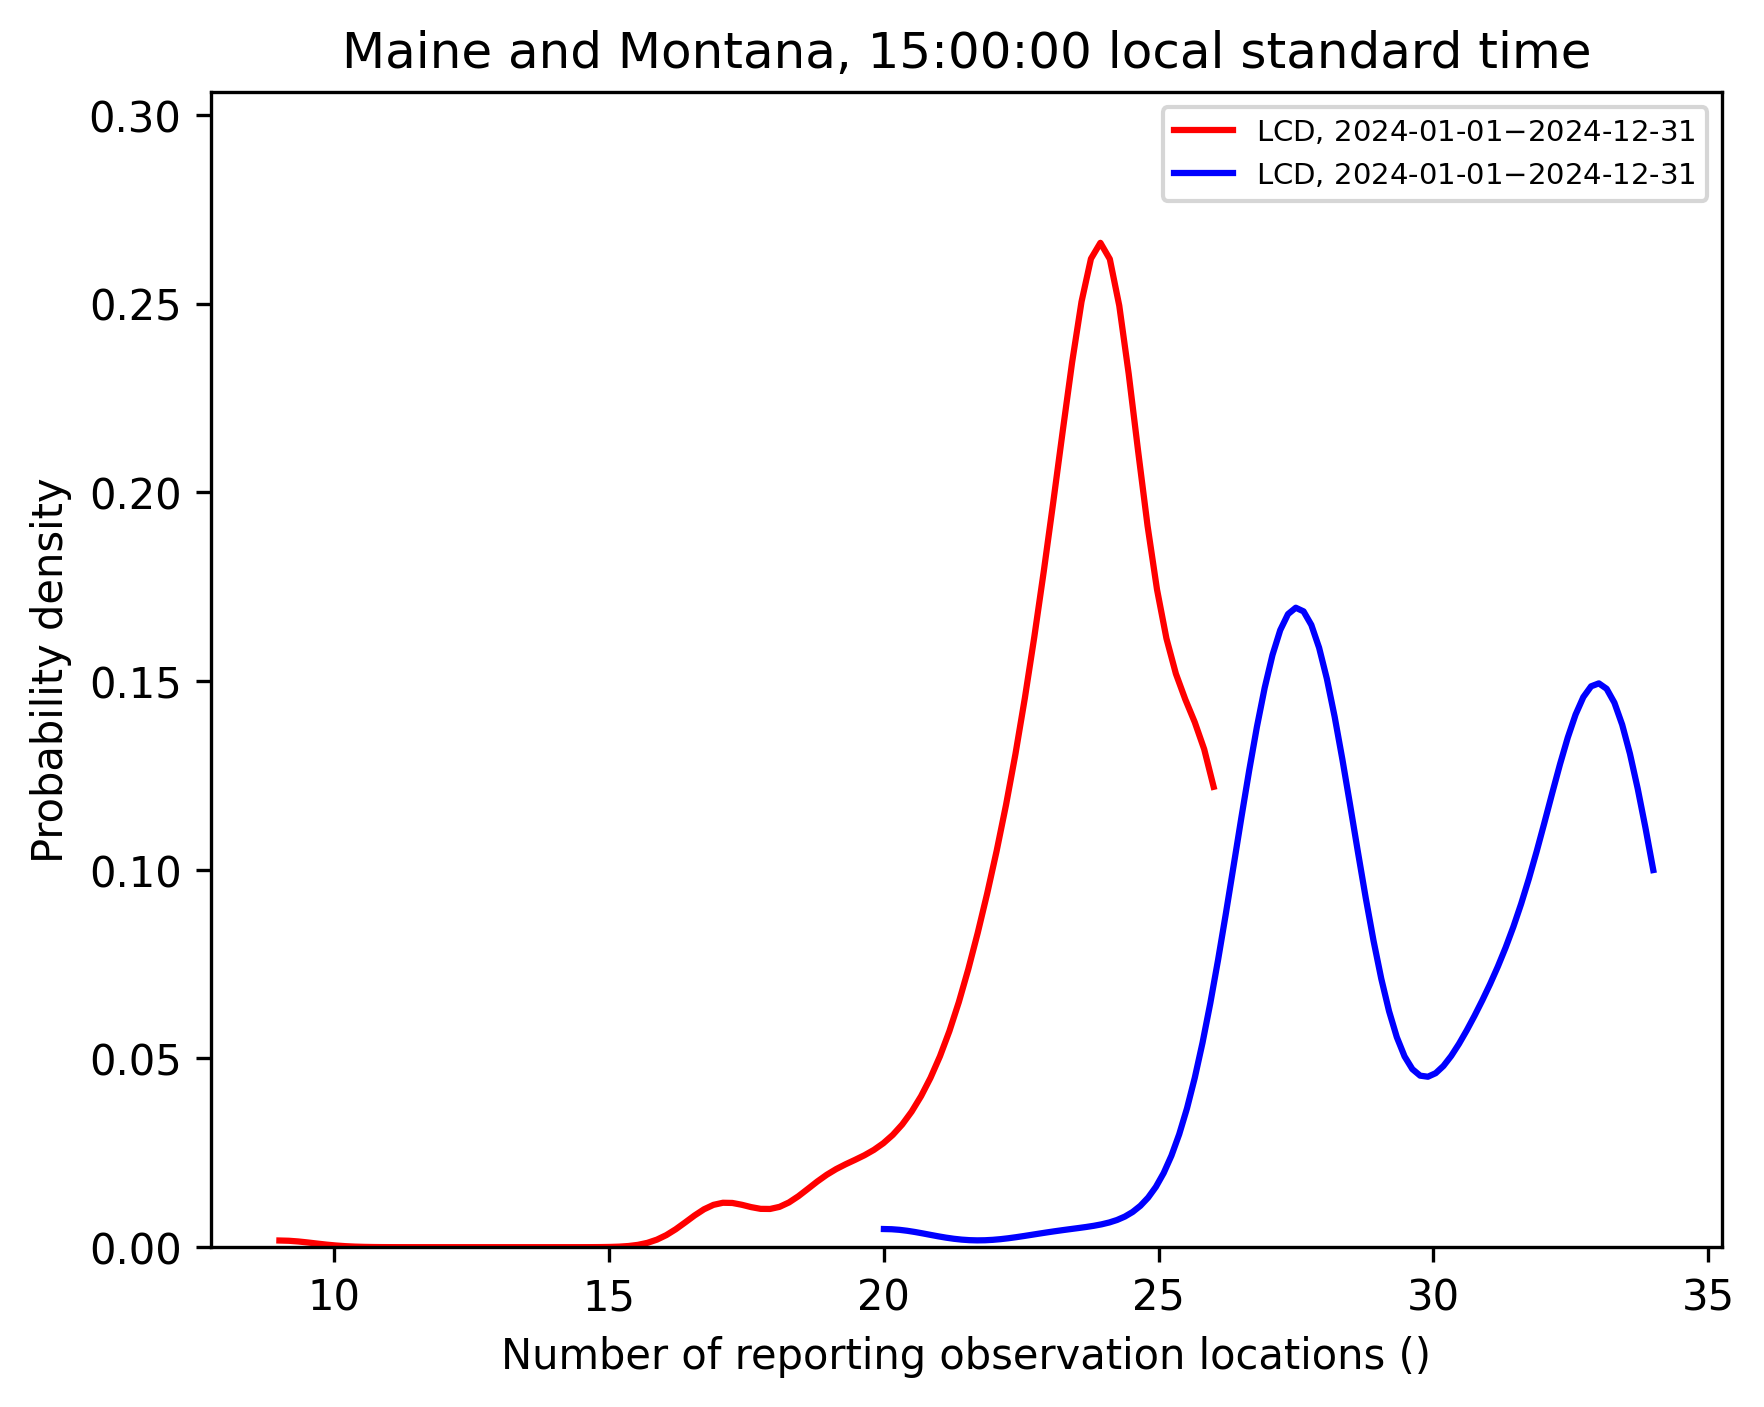

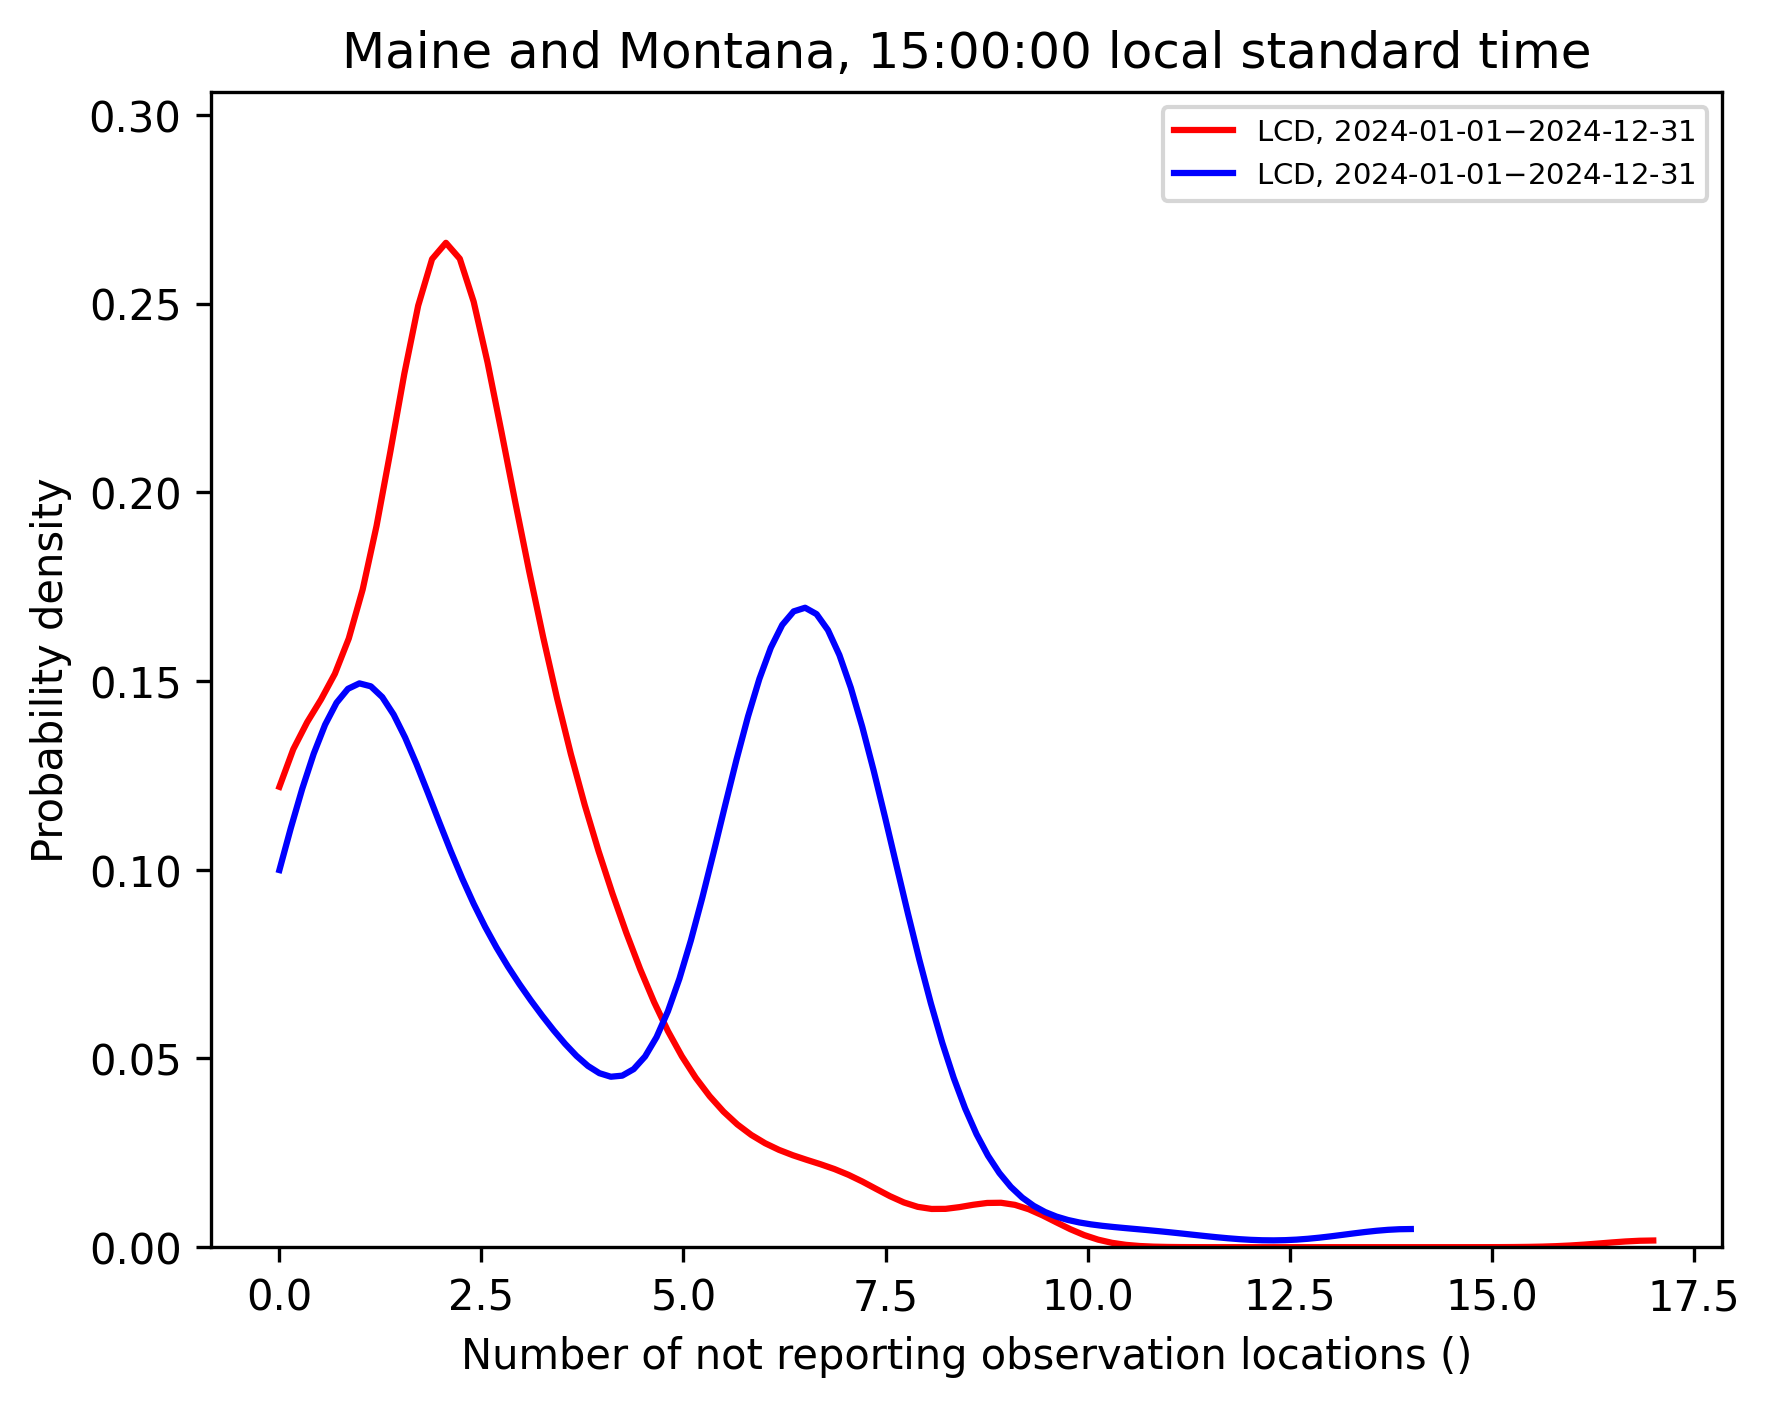

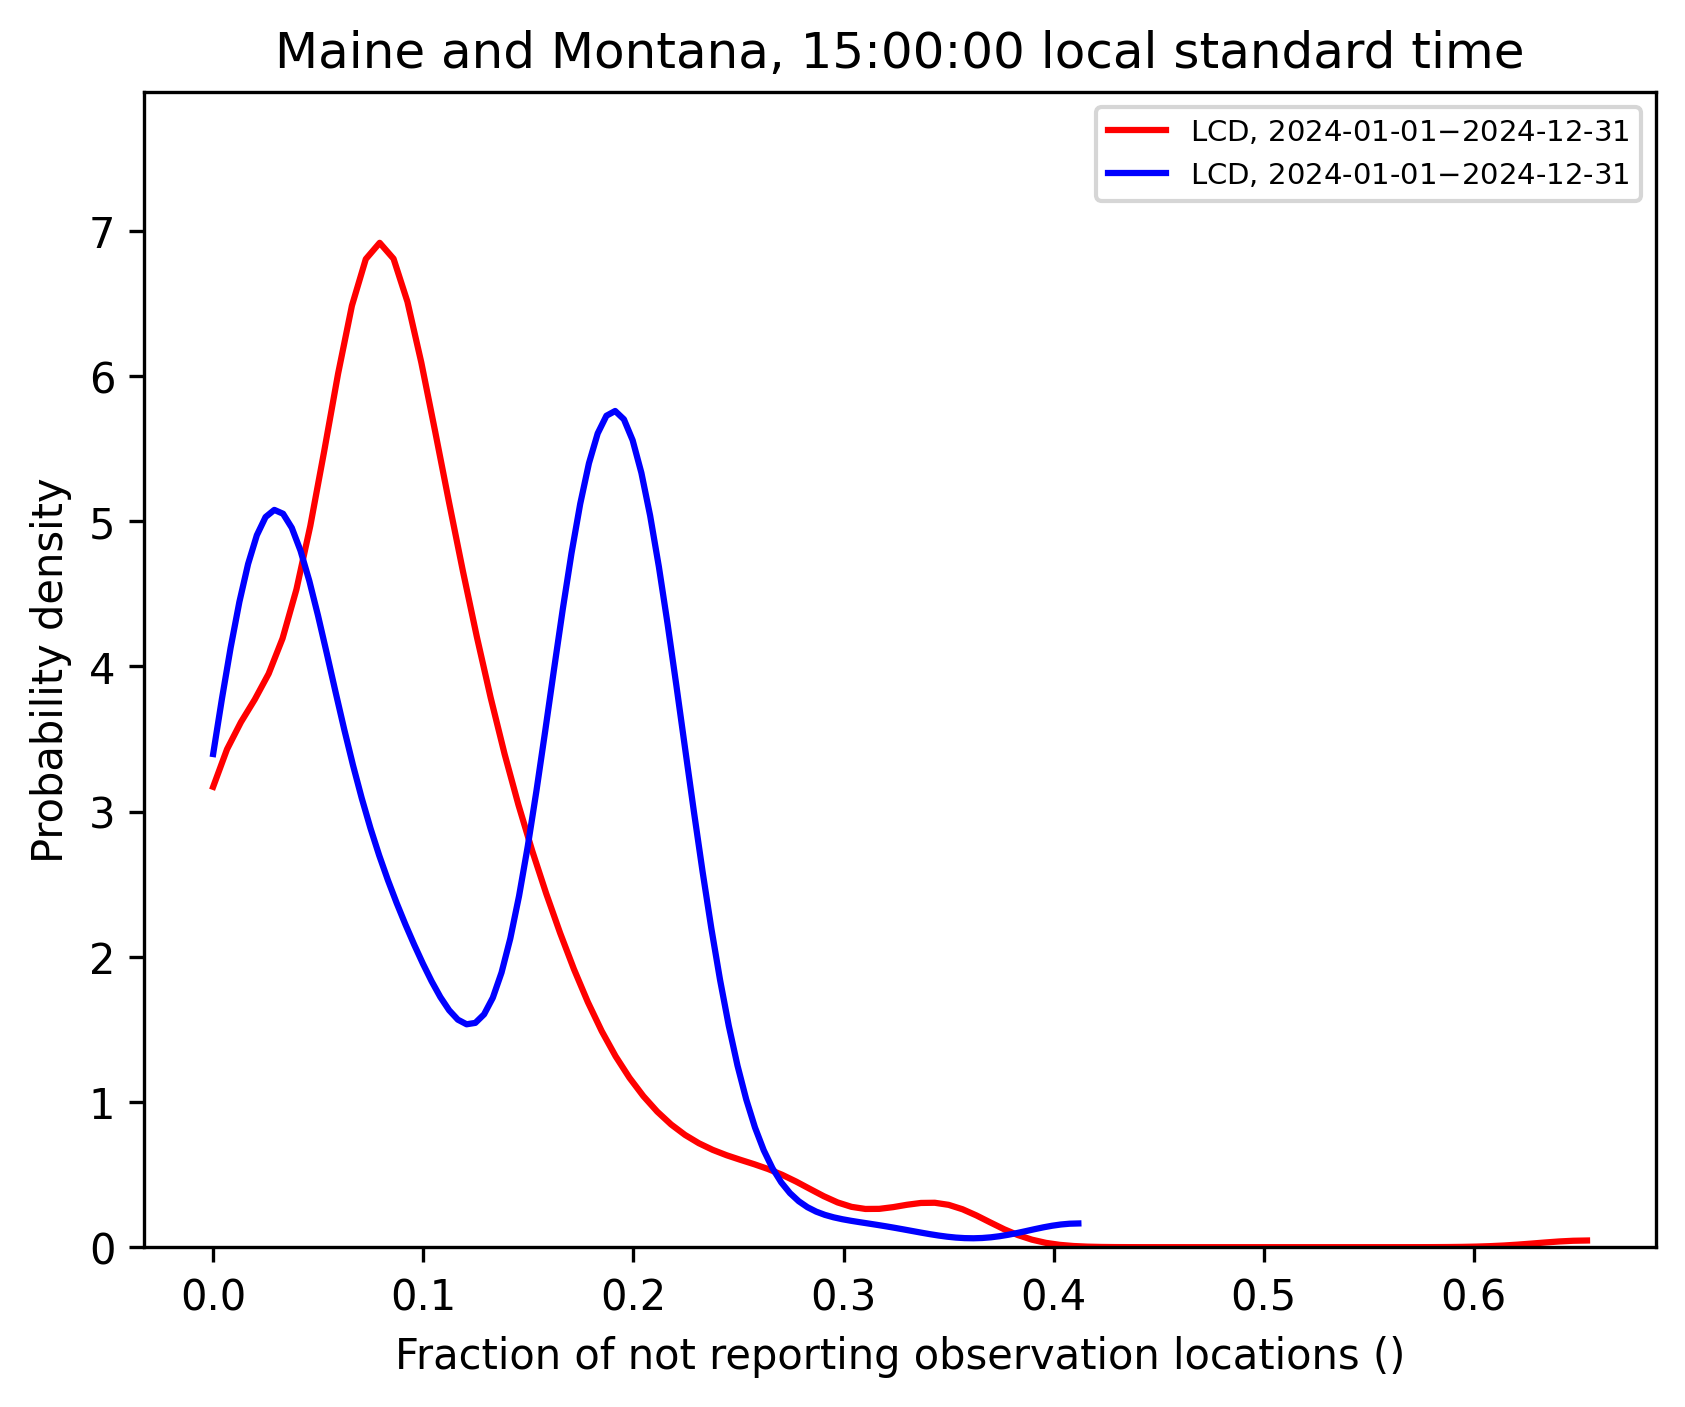

In [38]:
for plot in pdf_plots:
    display(Image(filename=plot))